# Моделирование: сравнение ML-моделей на трёх наборах признаков
## Методологическое обоснование

### Три набора признаков

| Набор | Содержимое | Лучший набор по результатам |
|---|---|---|
| **X_morgan** | 2048 Morgan FP (binary) | — (ни одна модель не показала лучший R² на этом наборе) |
| **X_rdkit** | 31 RDKit-дескриптор | Ridge, BayesianRidge, RF, XGBoost, CatBoost, KNN, SVR |
| **X_combined** | 2048 FP + 24 RDKit (совместный отбор) | Lasso, LightGBM, MLP |

Каждая модель обучается на **всех трёх наборах**. Лучшая из трёх конфигураций получает интерпретацию SHAP. Область применимости (Williams plot) строится для каждой модели на её оптимальном наборе признаков.

### Модели

| Раздел | Модель | Тип |
|---|---|---|
| 3 | Ridge | Линейная, L2 |
| 4 | Lasso | Линейная, L1 |
| 5 | BayesianRidge | Байесовская линейная |
| 6 | Random Forest | Ансамбль деревьев |
| 7 | LightGBM | Градиентный бустинг |
| 8 | XGBoost | Градиентный бустинг |
| 9 | CatBoost | Градиентный бустинг |
| 10 | KNN | Метрический |
| 11 | SVR | Ядровой |
| 12 | MLP (PyTorch + Optuna) | Нейронная сеть |

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import json
import time
import pickle
import os
from pathlib import Path
from matplotlib.transforms import Bbox
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import loguniform, randint, uniform

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
matplotlib.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Директории ────────────────────────────────────────────────────────────────
FIGURES_DIR    = Path('../figures')
MODELS_DIR     = Path('../models')
SHAP_CACHE_DIR = Path('../models/shap_cache')
for _d in (FIGURES_DIR, MODELS_DIR, SHAP_CACHE_DIR):
    _d.mkdir(exist_ok=True)

# ── Единая цветовая схема для наборов признаков ───────────────────────────────
FS_COLORS = {
    'morgan':   'steelblue',
    'rdkit':    'coral',
    'combined': 'mediumseagreen',
}

# ── Вспомогательные функции сохранения графиков ───────────────────────────────
def save_panel(fig, ax, fname, dpi=120, pad=0.15):
    # Сохраняет одну панель из многопанельной фигуры как отдельный PNG
    try:
        renderer  = fig.canvas.get_renderer()
        bbox_disp = ax.get_tightbbox(renderer)
        bbox_in   = bbox_disp.transformed(fig.dpi_scale_trans.inverted())
        padded    = Bbox([[bbox_in.x0 - pad, bbox_in.y0 - pad],
                          [bbox_in.x1 + pad, bbox_in.y1 + pad]])
        fig.savefig(str(fname), dpi=dpi, bbox_inches=padded)
    except Exception as e:
        print(f'  save_panel ({Path(fname).name}): {e}')


def savefig_panels(fig, axes_iter, base_path, names=None, dpi=120, show=True):
    # Сохраняет многопанельную фигуру двумя способами:
    #   {base_path}.png          — объединённый вид
    #   {base_path}_{name}.png   — каждая видимая панель отдельно
    base_path = Path(base_path)
    fig.savefig(f'{base_path}.png', dpi=dpi, bbox_inches='tight')
    for i, ax in enumerate(list(axes_iter)):
        if ax is None or not ax.get_visible():
            continue
        suffix = (names[i] if names and i < len(names) else f'{i:02d}')
        save_panel(fig, ax, Path(f'{base_path}_{suffix}.png'), dpi=dpi)
    if show:
        plt.show()


print('Импорты выполнены.')
print(f'  FIGURES_DIR    = {FIGURES_DIR.resolve()}')
print(f'  MODELS_DIR     = {MODELS_DIR.resolve()}')
print(f'  SHAP_CACHE_DIR = {SHAP_CACHE_DIR.resolve()}')


Device: cpu
Импорты выполнены.
  FIGURES_DIR    = C:\Users\User\Desktop\диплом тест\figures
  MODELS_DIR     = C:\Users\User\Desktop\диплом тест\models
  SHAP_CACHE_DIR = C:\Users\User\Desktop\диплом тест\models\shap_cache


## 1. Загрузка данных и разбиение на выборки

Загружаем три набора признаков, сформированных в `descriptors.ipynb`:
- `X_morgan.pkl` — 2048 Morgan FP
- `X_rdkit.pkl` — 31 отобранный RDKit-дескриптор
- `X_combined.pkl` — Morgan FP + 24 RDKit-дескрипторов (отбор с учётом FP)

Разбиение **воспроизводит** `random_state=42` из `descriptors.ipynb` — train/test совпадают.

In [211]:
DATA_DIR = Path('../data_ml')

with open(DATA_DIR / 'selected_descriptors.json', encoding='utf-8') as f:
    meta = json.load(f)

X_morgan   = np.asarray(pickle.load(open(DATA_DIR / 'X_morgan.pkl',   'rb')), dtype=np.float64)
X_rdkit    = np.asarray(pickle.load(open(DATA_DIR / 'X_rdkit.pkl',    'rb')), dtype=np.float64)
X_combined = np.asarray(pickle.load(open(DATA_DIR / 'X_combined.pkl', 'rb')), dtype=np.float64)
y          = np.load(DATA_DIR / 'y.npy')

morgan_cols   = meta['morgan_cols']
rdkit_cols    = meta['rdkit_cols']
combined_rdkit_cols = meta.get('rdkit_cols_combined', [])
combined_cols = morgan_cols + combined_rdkit_cols

print(f'X_morgan   : {X_morgan.shape}')
print(f'X_rdkit    : {X_rdkit.shape}')
print(f'X_combined : {X_combined.shape}')
print(f'y          : {y.shape},  [{y.min():.1f}, {y.max():.1f}] °C')
assert X_morgan.shape == (len(y), 2048), 'Проверьте X_morgan.pkl'
assert X_rdkit.shape  == (len(y), 31),   'Проверьте X_rdkit.pkl'

X_morgan   : (8572, 2048)
X_rdkit    : (8572, 31)
X_combined : (8572, 2072)
y          : (8572,),  [-161.5, 590.5] °C


In [212]:
idx_all = np.arange(len(y))
train_idx, test_idx = train_test_split(idx_all, test_size=0.20, random_state=RANDOM_STATE)

X_train_morgan,   X_test_morgan   = X_morgan[train_idx],   X_morgan[test_idx]
X_train_rdkit,    X_test_rdkit    = X_rdkit[train_idx],    X_rdkit[test_idx]
X_train_combined, X_test_combined = X_combined[train_idx], X_combined[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

feature_sets = {
    'morgan':   (X_train_morgan,   X_test_morgan),
    'rdkit':    (X_train_rdkit,    X_test_rdkit),
    'combined': (X_train_combined, X_test_combined),
}

print(f'Train: {len(y_train)} | Test: {len(y_test)}')
for fs, (Xtr, Xte) in feature_sets.items():
    print(f'  {fs:10s}: train {Xtr.shape}  test {Xte.shape}')

Train: 6857 | Test: 1715
  morgan    : train (6857, 2048)  test (1715, 2048)
  rdkit     : train (6857, 31)  test (1715, 31)
  combined  : train (6857, 2072)  test (1715, 2072)


In [213]:
def williams_plot(X_train, X_test, y_test_arr, y_pred, model_name,
                  n_pca_components=50, ax=None):
    """
    Williams plot: leverage h vs. стандартизированные остатки.
    Для высокоразмерных X (Morgan FP) перед вычислением hat-матрицы
    применяется PCA-проекция.
    Возвращает словарь с метриками области применимости.
    """
    n_tr = X_train.shape[0]
    p    = X_train.shape[1]
    n_pc = min(n_pca_components, p, n_tr - 1)

    if p > n_pc:
        pca       = PCA(n_components=n_pc, random_state=RANDOM_STATE)
        X_tr_proj = pca.fit_transform(X_train)
        X_te_proj = pca.transform(X_test)
    else:
        X_tr_proj = X_train
        X_te_proj = X_test

    XtX_inv = np.linalg.pinv(X_tr_proj.T @ X_tr_proj)
    h_te    = np.einsum('ij,jk,ik->i', X_te_proj, XtX_inv, X_te_proj)

    h_star    = 3.0 * (X_tr_proj.shape[1] + 1) / n_tr
    residuals = y_test_arr - y_pred
    std_res   = residuals / residuals.std(ddof=1)

    in_ad = (h_te <= h_star) & (np.abs(std_res) <= 3)
    pct   = 100.0 * in_ad.sum() / len(y_test_arr)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(h_te[in_ad],  std_res[in_ad],  alpha=0.4, s=12, color='steelblue',  label='В AD')
    ax.scatter(h_te[~in_ad], std_res[~in_ad], alpha=0.7, s=18, color='firebrick',  label='Вне AD', marker='x')
    ax.axhline( 3,      color='darkorange', lw=1.5, ls='--')
    ax.axhline(-3,      color='darkorange', lw=1.5, ls='--')
    ax.axvline(h_star,  color='green',      lw=1.5, ls='--', label=f'h*={h_star:.3f}')
    ax.set_xlabel('Leverage (h)')
    ax.set_ylabel('Стандартизированные остатки')
    ax.set_title(f'{model_name}  |  {pct:.1f}% в AD')
    ax.legend(fontsize=8)

    return {
        'pct_in_ad':            pct,
        'h_star':               h_star,
        'n_outliers_leverage':  int((h_te > h_star).sum()),
        'n_outliers_residual':  int((np.abs(std_res) > 3).sum()),
        'n_outside_ad':         int((~in_ad).sum()),
    }

ad_results = {}   # будет заполняться по мере обучения моделей
print('williams_plot() определена.')

williams_plot() определена.


## 2. Фреймворк оценки

Единая функция `evaluate()` вычисляет $R^2$, MAE и RMSE на обучающей и тестовой выборках и сохраняет результаты в словарь `results`.

Ключ словаря — `'Модель [feature_set]'` — позволяет различать результаты одной модели на разных наборах признаков. После обучения всех моделей сводная таблица строится по разделам «по наборам признаков» и «по моделям».

In [214]:
results = {}

def evaluate(name, predict_fn, X_tr, X_te, y_tr, y_te, feature_set='', cv_r2=None):
    """Вычисляет метрики и сохраняет в results[name]."""
    yp_tr = predict_fn(X_tr)
    yp_te = predict_fn(X_te)

    r2_tr   = r2_score(y_tr, yp_tr)
    r2_te   = r2_score(y_te, yp_te)
    mae_tr  = mean_absolute_error(y_tr, yp_tr)
    mae_te  = mean_absolute_error(y_te, yp_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, yp_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, yp_te))

    results[name] = {
        'R2_cv':    cv_r2   if cv_r2 is not None else float('nan'),
        'R2_train': r2_tr,  'R2_test':  r2_te,
        'MAE_train': mae_tr, 'MAE_test': mae_te,
        'RMSE_train': rmse_tr, 'RMSE_test': rmse_te,
        'Features': feature_set
    }

    # --- Auto-save: каждый вызов обновляет results_cache.json ---------------
    try:
        _rc_path = MODELS_DIR / 'results_cache.json'
        def _j(v):
            if isinstance(v, float) and (v != v): return None   # NaN -> null
            try: return float(v)
            except (TypeError, ValueError): return v
        _dump = {k: {mk: _j(mv) for mk, mv in vv.items()} for k, vv in results.items()}
        with open(_rc_path, 'w', encoding='utf-8') as _f:
            json.dump(_dump, _f, ensure_ascii=False, indent=1)
    except Exception:
        pass
    # -------------------------------------------------------------------------

    print(f'\n{"="*55}')
    print(f'  {name}  [{feature_set}]')
    print(f'{"="*55}')
    if cv_r2 is not None:
        print(f'  R² CV  : {cv_r2:.4f}')
    print(f'  R²   — train: {r2_tr:.4f}  |  test: {r2_te:.4f}')
    print(f'  MAE  — train: {mae_tr:.2f}  |  test: {mae_te:.2f} °C')
    print(f'  RMSE — train: {rmse_tr:.2f}  |  test: {rmse_te:.2f} °C')
    return yp_te

def timed(label, fn):
    t0 = time.time()
    result = fn()
    print(f'  [{label}] время: {time.time()-t0:.1f}с')
    return result

In [215]:
def train_on_feature_sets(base_name, estimator_fn, param_dist,
                          n_iter_map=None, pipeline=True, n_jobs_search=-1):
    """
    Обучает модель на всех трёх наборах признаков.
    При наличии pkl + results_cache.json -- загружает мгновенно (без predict).
    При наличии pkl, но отсутствии кэша метрик -- загружает + evaluate().
    При отсутствии pkl -- обучает, сохраняет pkl + cv_scores.json.
    """
    if n_iter_map is None:
        n_iter_map = {fs: 50 for fs in feature_sets}

    # Загружаем кэши (могут не существовать при первом запуске)
    _rc_path = MODELS_DIR / 'results_cache.json'
    _cv_path = MODELS_DIR / 'cv_scores.json'
    _cached  = {}
    _cv_data = {}
    if _rc_path.exists():
        with open(_rc_path, encoding='utf-8') as _f:
            _cached = json.load(_f)
    if _cv_path.exists():
        with open(_cv_path, encoding='utf-8') as _f:
            _cv_data = json.load(_f)

    best = {}
    for fs_name, (X_tr, X_te) in feature_sets.items():
        label    = f'{base_name} [{fs_name}]'
        pkl_path = MODELS_DIR / f'{base_name.lower().replace(" ", "_")}_{fs_name}.pkl'

        if pkl_path.exists():
            best[fs_name] = pickle.load(open(pkl_path, 'rb'))
            if label in _cached:
                # -- БЫСТРО: метрики из JSON, predict не нужен ---------------
                _entry = _cached[label]
                results[label] = {
                    mk: (float('nan') if mv is None
                         else float(mv) if isinstance(mv, (int, float))
                         else mv)
                    for mk, mv in _entry.items()
                }
                # cv_r2: берём из cv_scores.json (точнее, чем из results_cache)
                _cv = _cv_data.get(label)
                results[label]['R2_cv'] = float(_cv) if _cv is not None else float('nan')
                _r2 = results[label]['R2_test']
                # Полный отчёт из кэшированных метрик (без predict)
                _cv_r2  = results[label]['R2_cv']
                _r2_tr  = results[label]['R2_train']
                _r2_te  = results[label]['R2_test']
                _mae_tr = results[label]['MAE_train']
                _mae_te = results[label]['MAE_test']
                _rmse_tr= results[label]['RMSE_train']
                _rmse_te= results[label]['RMSE_test']
                print(f'\n{"="*55}')
                print(f'  {label}  [{fs_name}]')
                print(f'{"="*55}')
                _cv_ok = not (_cv_r2 != _cv_r2)  # not NaN
                if _cv_ok:
                    print(f'  R² CV  : {_cv_r2:.4f}')
                print(f'  R²   — train: {_r2_tr:.4f}  |  test: {_r2_te:.4f}')
                print(f'  MAE  — train: {_mae_tr:.2f}  |  test: {_mae_te:.2f} °C')
                print(f'  RMSE — train: {_rmse_tr:.2f}  |  test: {_rmse_te:.2f} °C')
            else:
                # pkl есть, но кэша метрик нет -- нужен predict
                _cv_r2 = _cv_data.get(label)
                if _cv_r2 is not None: _cv_r2 = float(_cv_r2)
                print(f'{label}: pkl загружен, вычисляем метрики...')
                evaluate(label, best[fs_name].predict, X_tr, X_te,
                         y_train, y_test, fs_name, cv_r2=_cv_r2)
        else:
            # -- Обучаем с нуля -----------------------------------------------
            est = estimator_fn()
            if pipeline:
                est = Pipeline([('scaler', StandardScaler()), ('model', est)])
                pars = {f'model__{k}': v for k, v in param_dist.items()}
            else:
                pars = param_dist
            srch = RandomizedSearchCV(est, pars, n_iter=n_iter_map[fs_name],
                                      cv=5, scoring='r2', random_state=RANDOM_STATE,
                                      n_jobs=n_jobs_search, verbose=0)
            timed(label, lambda s=srch, X=X_tr: s.fit(X, y_train))
            best[fs_name] = srch.best_estimator_
            _cv_r2 = float(srch.best_score_)
            pickle.dump(best[fs_name], open(pkl_path, 'wb'), protocol=4)
            # Сохраняем cv_r2 в cv_scores.json
            _cv_data[label] = _cv_r2
            with open(_cv_path, 'w', encoding='utf-8') as _f:
                json.dump(_cv_data, _f, ensure_ascii=False, indent=1)
            evaluate(label, best[fs_name].predict, X_tr, X_te,
                     y_train, y_test, fs_name, cv_r2=_cv_r2)

    best_fs = max(feature_sets, key=lambda k: results[f'{base_name} [{k}]']['R2_test'])
    print(f'\n→ Лучший набор для {base_name}: [{best_fs}]  '
          f'R²_test={results[f"{base_name} [{best_fs}]"]["R2_test"]:.4f}')
    return best, best_fs

print('train_on_feature_sets() определена.')

train_on_feature_sets() определена.


## 3. Ridge Regression (МЛР с L2-регуляризацией)

Ridge минимизирует $\|y - X\beta\|_2^2 + \alpha\|\beta\|_2^2$. Параметр $\alpha$ подбирается `RandomizedSearchCV` (50 итераций, 5-fold CV) в логарифмической сетке $[10^{-3}, 10^3]$.

Нормализация: `StandardScaler` внутри `Pipeline` — подгоняется только на train-фолде, исключая утечку статистик масштабирования.

SHAP для лучшей из трёх конфигураций — в разделе 15.

In [216]:
param_dist_ridge = {'alpha': loguniform(1e-3, 1e3)}

best_ridge, best_ridge_fs = train_on_feature_sets(
    'Ridge',
    lambda: Ridge(max_iter=10000),
    param_dist_ridge,
    pipeline=True
)


  Ridge [morgan]  [morgan]
  R²   — train: 0.6958  |  test: 0.4118
  MAE  — train: 33.84  |  test: 47.36 °C
  RMSE — train: 45.00  |  test: 62.73 °C

  Ridge [rdkit]  [rdkit]
  R² CV  : 0.6222
  R²   — train: 0.6285  |  test: 0.5906
  MAE  — train: 36.10  |  test: 38.20 °C
  RMSE — train: 49.73  |  test: 52.33 °C

  Ridge [combined]  [combined]
  R²   — train: 0.7952  |  test: 0.5572
  MAE  — train: 27.70  |  test: 40.32 °C
  RMSE — train: 36.92  |  test: 54.43 °C

→ Лучший набор для Ridge: [rdkit]  R²_test=0.5906


## 4. Lasso Regression (МЛР с L1-регуляризацией)

L1-регуляризация порождает **разреженное** решение: часть коэффициентов обнуляется, что автоматически отбирает признаки. Для молекулярных дескрипторов это полезно: Lasso выбирает наиболее информативные из 31 дескриптора.

In [217]:
param_dist_lasso = {'alpha': loguniform(1e-4, 1e2)}

best_lasso, best_lasso_fs = train_on_feature_sets(
    'Lasso',
    lambda: Lasso(max_iter=20000),
    param_dist_lasso,
    pipeline=True
)


  Lasso [morgan]  [morgan]
  R²   — train: 0.5768  |  test: 0.4501
  MAE  — train: 40.11  |  test: 45.33 °C
  RMSE — train: 53.07  |  test: 60.66 °C

  Lasso [rdkit]  [rdkit]
  R²   — train: 0.6285  |  test: 0.5907
  MAE  — train: 36.09  |  test: 38.19 °C
  RMSE — train: 49.73  |  test: 52.33 °C

  Lasso [combined]  [combined]
  R² CV  : 0.6342
  R²   — train: 0.6949  |  test: 0.6070
  MAE  — train: 33.52  |  test: 37.46 °C
  RMSE — train: 45.06  |  test: 51.27 °C

→ Лучший набор для Lasso: [combined]  R²_test=0.6070


## 5. Bayesian Ridge Regression

Байесовская линейная регрессия задаёт априорные распределения на параметры модели: $\beta \sim \mathcal{N}(0, \lambda^{-1}I)$, $\varepsilon \sim \mathcal{N}(0, \alpha^{-1})$. Параметры $\alpha_1, \alpha_2, \lambda_1, \lambda_2$ (форма и скорость гамма-прайоров) подбираются через `RandomizedSearchCV`.

Преимущество: модель возвращает **неопределённость** предсказания, что важно для оценки области применимости. Скорость сопоставима с Ridge (аналитическое решение).

In [218]:
param_dist_br = {
    'alpha_1':  loguniform(1e-6, 1.0),
    'alpha_2':  loguniform(1e-6, 1.0),
    'lambda_1': loguniform(1e-6, 1.0),
    'lambda_2': loguniform(1e-6, 1.0),
}

best_br, best_br_fs = train_on_feature_sets(
    'BayesianRidge',
    lambda: BayesianRidge(max_iter=300),
    param_dist_br,
    pipeline=True
)


  BayesianRidge [morgan]  [morgan]
  R²   — train: 0.6581  |  test: 0.4457
  MAE  — train: 35.70  |  test: 45.94 °C
  RMSE — train: 47.71  |  test: 60.90 °C

  BayesianRidge [rdkit]  [rdkit]
  R² CV  : 0.6222
  R²   — train: 0.6284  |  test: 0.5907
  MAE  — train: 36.12  |  test: 38.22 °C
  RMSE — train: 49.73  |  test: 52.33 °C

  BayesianRidge [combined]  [combined]
  R²   — train: 0.7762  |  test: 0.5713
  MAE  — train: 29.05  |  test: 39.87 °C
  RMSE — train: 38.59  |  test: 53.56 °C

→ Лучший набор для BayesianRidge: [rdkit]  R²_test=0.5907


## 6. Random Forest

Случайный лес нечувствителен к масштабу признаков (деревья делают пороговые разбиения) и способен использовать разреженные бинарные FP: каждый бит означает наличие/отсутствие структурного фрагмента, что является бинарным условием ветвления.

`RandomizedSearchCV` с 30 итерациями на каждый набор (5-fold CV). `n_jobs=1` для `RandomizedSearchCV` — сами деревья уже параллельны (`n_jobs=-1` внутри RF).

In [219]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 15, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.2, 0.3],
}

best_rf, best_rf_fs = train_on_feature_sets(
    'Random Forest',
    lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_rf,
    pipeline=False,
    n_jobs_search=1,
    n_iter_map={'morgan': 30, 'rdkit': 30, 'combined': 30}
)


  Random Forest [morgan]  [morgan]
  R²   — train: 0.8302  |  test: 0.5262
  MAE  — train: 24.17  |  test: 41.30 °C
  RMSE — train: 33.62  |  test: 56.30 °C

  Random Forest [rdkit]  [rdkit]
  R² CV  : 0.7158
  R²   — train: 0.9366  |  test: 0.6845
  MAE  — train: 12.75  |  test: 29.83 °C
  RMSE — train: 20.53  |  test: 45.94 °C

  Random Forest [combined]  [combined]
  R²   — train: 0.9347  |  test: 0.6783
  MAE  — train: 13.24  |  test: 30.78 °C
  RMSE — train: 20.85  |  test: 46.40 °C

→ Лучший набор для Random Forest: [rdkit]  R²_test=0.6845


## 7. LightGBM (Gradient Boosting)

LightGBM использует leaf-wise рост деревьев и GOSS-сэмплирование, что ускоряет обучение при сохранении качества. Нативная поддержка SHAP (`TreeExplainer`) позволяет точно интерпретировать вклад каждого признака.

In [220]:
param_dist_lgb = {
    'n_estimators':      [500, 1000, 1500, 2000],
    'max_depth':         [-1, 6, 8, 10, 12],
    'learning_rate':     loguniform(0.005, 0.1),
    'num_leaves':        randint(31, 200),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_samples': randint(10, 100),
    'reg_alpha':         loguniform(1e-8, 10.0),
    'reg_lambda':        loguniform(1e-8, 10.0),
}

best_lgb, best_lgb_fs = train_on_feature_sets(
    'LightGBM',
    lambda: lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    param_dist_lgb,
    pipeline=False,
    n_jobs_search=1,
    n_iter_map={'morgan': 30, 'rdkit': 30, 'combined': 30}
)


  LightGBM [morgan]  [morgan]
  R²   — train: 0.7514  |  test: 0.5539
  MAE  — train: 30.46  |  test: 40.61 °C
  RMSE — train: 40.67  |  test: 54.63 °C

  LightGBM [rdkit]  [rdkit]
  R²   — train: 0.9155  |  test: 0.6908
  MAE  — train: 15.57  |  test: 29.25 °C
  RMSE — train: 23.71  |  test: 45.48 °C

  LightGBM [combined]  [combined]
  R² CV  : 0.7137
  R²   — train: 0.9070  |  test: 0.6923
  MAE  — train: 17.21  |  test: 29.93 °C
  RMSE — train: 24.87  |  test: 45.37 °C

→ Лучший набор для LightGBM: [combined]  R²_test=0.6923


## 8. XGBoost

XGBoost — классический градиентный бустинг с level-wise ростом деревьев. Включён для сравнения с LightGBM и CatBoost. Поддерживает `TreeExplainer` SHAP.

In [221]:
param_dist_xgb = {
    'n_estimators':     [500, 1000, 1500, 2000],
    'max_depth':        randint(3, 10),
    'learning_rate':    loguniform(0.005, 0.1),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma':            loguniform(1e-4, 10.0),
    'reg_alpha':        loguniform(1e-8, 10.0),
    'reg_lambda':       loguniform(1e-8, 10.0),
    'min_child_weight': randint(1, 10),
}

best_xgb, best_xgb_fs = train_on_feature_sets(
    'XGBoost',
    lambda: xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    param_dist_xgb,
    pipeline=False,
    n_jobs_search=1,
    n_iter_map={'morgan': 30, 'rdkit': 30, 'combined': 30}
)


  XGBoost [morgan]  [morgan]
  R²   — train: 0.7353  |  test: 0.5432
  MAE  — train: 31.48  |  test: 41.00 °C
  RMSE — train: 41.97  |  test: 55.29 °C

  XGBoost [rdkit]  [rdkit]
  R² CV  : 0.7289
  R²   — train: 0.9778  |  test: 0.6953
  MAE  — train: 8.07  |  test: 28.25 °C
  RMSE — train: 12.17  |  test: 45.15 °C

  XGBoost [combined]  [combined]
  R²   — train: 0.9221  |  test: 0.6910
  MAE  — train: 15.30  |  test: 29.76 °C
  RMSE — train: 22.77  |  test: 45.47 °C

→ Лучший набор для XGBoost: [rdkit]  R²_test=0.6953


## 9. CatBoost

CatBoost использует симметричные деревья и ordered boosting для снижения переобучения. Особенно эффективен на табличных данных без предобработки: не требует нормализации и хорошо работает с разреженными бинарными признаками (Morgan FP).

In [222]:
param_dist_cb = {
    'iterations':       [500, 1000, 1500],
    'depth':            randint(4, 10),
    'learning_rate':    loguniform(0.01, 0.3),
    'l2_leaf_reg':      loguniform(1e-2, 10.0),
    'subsample':        uniform(0.6, 0.4),   # работает с bootstrap_type='Bernoulli'
    'rsm':              uniform(0.6, 0.4),   # random subspace method (аналог colsample)
    'min_data_in_leaf': randint(1, 50),
}

best_cb, best_cb_fs = train_on_feature_sets(
    'CatBoost',
    lambda: CatBoostRegressor(
        random_seed=RANDOM_STATE, verbose=0, bootstrap_type='Bernoulli'
    ),
    param_dist_cb,
    pipeline=False,
    n_jobs_search=1,
    n_iter_map={'morgan': 30, 'rdkit': 30, 'combined': 30}
)


  CatBoost [morgan]  [morgan]
  R²   — train: 0.8549  |  test: 0.5526
  MAE  — train: 23.35  |  test: 40.43 °C
  RMSE — train: 31.08  |  test: 54.71 °C

  CatBoost [rdkit]  [rdkit]
  R² CV  : 0.7279
  R²   — train: 0.9556  |  test: 0.7010
  MAE  — train: 11.50  |  test: 27.77 °C
  RMSE — train: 17.19  |  test: 44.72 °C

  CatBoost [combined]  [combined]
  R²   — train: 0.9726  |  test: 0.6974
  MAE  — train: 10.16  |  test: 28.70 °C
  RMSE — train: 13.50  |  test: 44.99 °C

→ Лучший набор для CatBoost: [rdkit]  R²_test=0.7010


## 10. K-Nearest Neighbors (KNN)

KNN находит K ближайших соседей в признаковом пространстве и усредняет их температуры кипения. Евклидово расстояние физически осмысленно на пространстве непрерывных RDKit-дескрипторов (схожие значения полярности, размера, топологии → схожая T кип). На 2048-мерном разреженном пространстве FP расстояние теряет смысл («проклятие размерности»), поэтому ожидаем, что X_rdkit даст лучший результат.

In [223]:
param_dist_knn = {
    'n_neighbors': randint(3, 30),
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

best_knn, best_knn_fs = train_on_feature_sets(
    'KNN',
    lambda: KNeighborsRegressor(n_jobs=-1),
    param_dist_knn,
    pipeline=True
)


  KNN [morgan]  [morgan]
  R²   — train: 0.9712  |  test: 0.0833
  MAE  — train: 2.58  |  test: 59.72 °C
  RMSE — train: 13.83  |  test: 78.31 °C

  KNN [rdkit]  [rdkit]
  R² CV  : 0.6793
  R²   — train: 1.0000  |  test: 0.6386
  MAE  — train: 0.00  |  test: 32.18 °C
  RMSE — train: 0.00  |  test: 49.18 °C

  KNN [combined]  [combined]
  R²   — train: 1.0000  |  test: 0.3501
  MAE  — train: 0.00  |  test: 49.75 °C
  RMSE — train: 0.00  |  test: 65.94 °C

→ Лучший набор для KNN: [rdkit]  R²_test=0.6386


## 11. Support Vector Regression (SVR)

RBF-ядро $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ физически осмысленно на пространстве **непрерывных** молекулярных дескрипторов. На высокоразмерных разреженных пространствах (X_morgan, X_combined) ядровые вычисления дороже, поэтому для этих наборов используется `n_iter=20`.

In [224]:
param_dist_svr = {
    'C':       loguniform(0.1, 1000),
    'epsilon': loguniform(0.01, 10),
    'gamma':   ['scale', 'auto'],
}

best_svr, best_svr_fs = train_on_feature_sets(
    'SVR',
    lambda: SVR(kernel='rbf', cache_size=500),
    param_dist_svr,
    pipeline=True,
    n_iter_map={'morgan': 20, 'rdkit': 50, 'combined': 20}
)


  SVR [morgan]  [morgan]
  R²   — train: 0.9000  |  test: 0.4383
  MAE  — train: 8.12  |  test: 44.82 °C
  RMSE — train: 25.80  |  test: 61.30 °C

  SVR [rdkit]  [rdkit]
  R² CV  : 0.6975
  R²   — train: 0.8189  |  test: 0.6566
  MAE  — train: 17.79  |  test: 27.56 °C
  RMSE — train: 34.72  |  test: 47.93 °C

  SVR [combined]  [combined]
  R²   — train: 0.9529  |  test: 0.5450
  MAE  — train: 4.45  |  test: 38.29 °C
  RMSE — train: 17.71  |  test: 55.18 °C

→ Лучший набор для SVR: [rdkit]  R²_test=0.6566


## 12. Multi-Layer Perceptron (PyTorch + Optuna)

MLP обучается только на **X_combined** — наиболее полном наборе признаков (Morgan FP фиксируют топологию, RDKit-дескрипторы добавляют физико-химические свойства).

Архитектура и гиперпараметры подбираются **Optuna TPE** (Tree-structured Parzen Estimator) — байесовская оптимизация, строящая суррогатную вероятностную модель пространства гиперпараметров.

**Подбираемые гиперпараметры:**
- `n_layers` (2–5) — количество скрытых слоёв
- `units_lN` (256–2048, log) — ширина каждого слоя
- `act_lN` — функция активации (ReLU / GELU / SiLU)
- `drop_lN` (0.1–0.5) — dropout на каждом слое
- `use_batchnorm` — BatchNorm после активации
- `lr` (1e-4–1e-2, log) — скорость обучения
- `weight_decay` (1e-6–1e-3, log) — L2-регуляризация
- `optimizer` — Adam / AdamW
- `batch_size` — 128 / 256 / 512

**Pruner:** MedianPruner — ранняя остановка слабых trials.

In [225]:
# MLP масштабируется на X_combined
scaler_mlp  = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_combined).astype(np.float32)
X_test_mlp  = scaler_mlp.transform(X_test_combined).astype(np.float32)

# Валидационная выборка для Optuna (10% от train; тест не трогаем)
sub_idx, val_idx_opt = train_test_split(
    np.arange(len(y_train)), test_size=0.10, random_state=RANDOM_STATE
)
X_sub     = X_train_mlp[sub_idx]
X_val_mlp = X_train_mlp[val_idx_opt]
y_sub     = y_train[sub_idx].astype(np.float32)
y_val_mlp = y_train[val_idx_opt].astype(np.float32)

INPUT_DIM = X_train_mlp.shape[1]   # размер X_combined
print(f'MLP input dim: {INPUT_DIM}')

# Тензоры для Optuna (нужны внутри objective)
X_sub_t   = torch.FloatTensor(X_sub).to(DEVICE)
X_val_t   = torch.FloatTensor(X_val_mlp).to(DEVICE)
y_sub_t   = torch.FloatTensor(y_sub).to(DEVICE)

X_train_t = torch.FloatTensor(X_train_mlp).to(DEVICE)
X_test_t  = torch.FloatTensor(X_test_mlp).to(DEVICE)
y_train_t = torch.FloatTensor(y_train.astype(np.float32)).to(DEVICE)
y_test_t  = torch.FloatTensor(y_test.astype(np.float32)).to(DEVICE)

MLP input dim: 2072


In [226]:
# Словарь-фабрика: хранит КЛАССЫ, а не экземпляры.
# Каждый вызов ACT_MAP[name]() создаёт НОВЫЙ объект — обязательно при Optuna (100+ моделей)
ACT_MAP = {'relu': nn.ReLU, 'gelu': nn.GELU, 'silu': nn.SiLU}

class MLPRegressor(nn.Module):
    """Конфигурируемый MLP с BatchNorm и Dropout для регрессии."""

    def __init__(self, input_dim, layer_sizes, act_names, dropouts, use_batchnorm):
        super().__init__()
        blocks = []
        prev = input_dim
        for size, act_name, drop in zip(layer_sizes, act_names, dropouts):
            blocks.append(nn.Linear(prev, size))
            if use_batchnorm:
                blocks.append(nn.BatchNorm1d(size))
            blocks.append(ACT_MAP[act_name]())   # новый экземпляр для каждого слоя
            if drop > 0:
                blocks.append(nn.Dropout(drop))
            prev = size
        blocks.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x).squeeze(-1)

print('MLPRegressor определён.')

MLPRegressor определён.


In [227]:
def objective(trial):
    # --- Архитектура ---
    n_layers    = trial.suggest_int('n_layers', 2, 5)
    layer_sizes = [trial.suggest_int(f'units_l{i}', 256, 2048, log=True) for i in range(n_layers)]
    act_names   = [trial.suggest_categorical(f'act_l{i}', ['relu', 'gelu', 'silu']) for i in range(n_layers)]
    dropouts    = [trial.suggest_float(f'drop_l{i}', 0.1, 0.5) for i in range(n_layers)]
    use_bn      = trial.suggest_categorical('use_batchnorm', [True, False])

    # --- Оптимизация ---
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd         = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    opt_name   = trial.suggest_categorical('optimizer', ['Adam', 'AdamW'])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    model = MLPRegressor(INPUT_DIM, layer_sizes, act_names, dropouts, use_bn).to(DEVICE)
    optimizer = (
        optim.Adam(model.parameters(),  lr=lr, weight_decay=wd)
        if opt_name == 'Adam'
        else optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)
    criterion = nn.MSELoss()

    # drop_last=True: последний батч может быть размером 1 — BatchNorm упадёт
    loader = DataLoader(
        TensorDataset(X_sub_t, y_sub_t),
        batch_size=batch_size, shuffle=True, drop_last=True
    )

    n_epochs = 100
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()

        # Pruning каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t).cpu().numpy()
            val_rmse = np.sqrt(mean_squared_error(y_val_mlp, val_pred))
            trial.report(val_rmse, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t).cpu().numpy()
    return np.sqrt(mean_squared_error(y_val_mlp, val_pred))

print('Objective определён.')

Objective определён.


In [228]:
_mlp_pt = MODELS_DIR / 'mlp_combined.pt'

if _mlp_pt.exists():
    # --- Кэш найден - Optuna не запускаем ----------------------------
    print('MLP найден в кэше - Optuna пропускается.')
    _mlp_ckpt = torch.load(_mlp_pt, map_location=DEVICE, weights_only=False)
    bp    = _mlp_ckpt['best_params']
    study = None          # сигнал для следующих ячеек
    print('Загружены параметры:')
    for k, v in bp.items():
        print(f'  {k}: {v}')
else:
    # --- Кэша нет - запускаем Optuna ---------------------------------
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=20)
    )

    N_TRIALS = 100  # при наличии GPU можно увеличить до 150-200

    timed('Optuna MLP', lambda: study.optimize(objective, n_trials=N_TRIALS,
                                                show_progress_bar=True))

    bp = study.best_params
    print(f'\nЛучший trial: #{study.best_trial.number}')
    print(f'Лучший val RMSE: {study.best_value:.3f} C')
    print('Лучшие параметры:')
    for k, v in bp.items():
        print(f'  {k}: {v}')

MLP найден в кэше - Optuna пропускается.
Загружены параметры:
  n_layers: 3
  units_l0: 1064
  units_l1: 657
  units_l2: 384
  act_l0: gelu
  act_l1: gelu
  act_l2: relu
  drop_l0: 0.22440245136939113
  drop_l1: 0.2920322706361712
  drop_l2: 0.15523785701830653
  use_batchnorm: True
  lr: 0.004266091199961749
  weight_decay: 1.9407863329114253e-06
  optimizer: Adam
  batch_size: 256


=== MLP: лучшие гиперпараметры (из кэша) ===
  Оптимизатор : Adam
  LR          : 0.004266
  Weight decay: 0.000002
  Batch size  : 256
  BatchNorm   : True
  Слоёв       : 3
    Слой 1: 1064 нейр., act=gelu, drop=0.22
    Слой 2: 657 нейр., act=gelu, drop=0.29
    Слой 3: 384 нейр., act=relu, drop=0.16


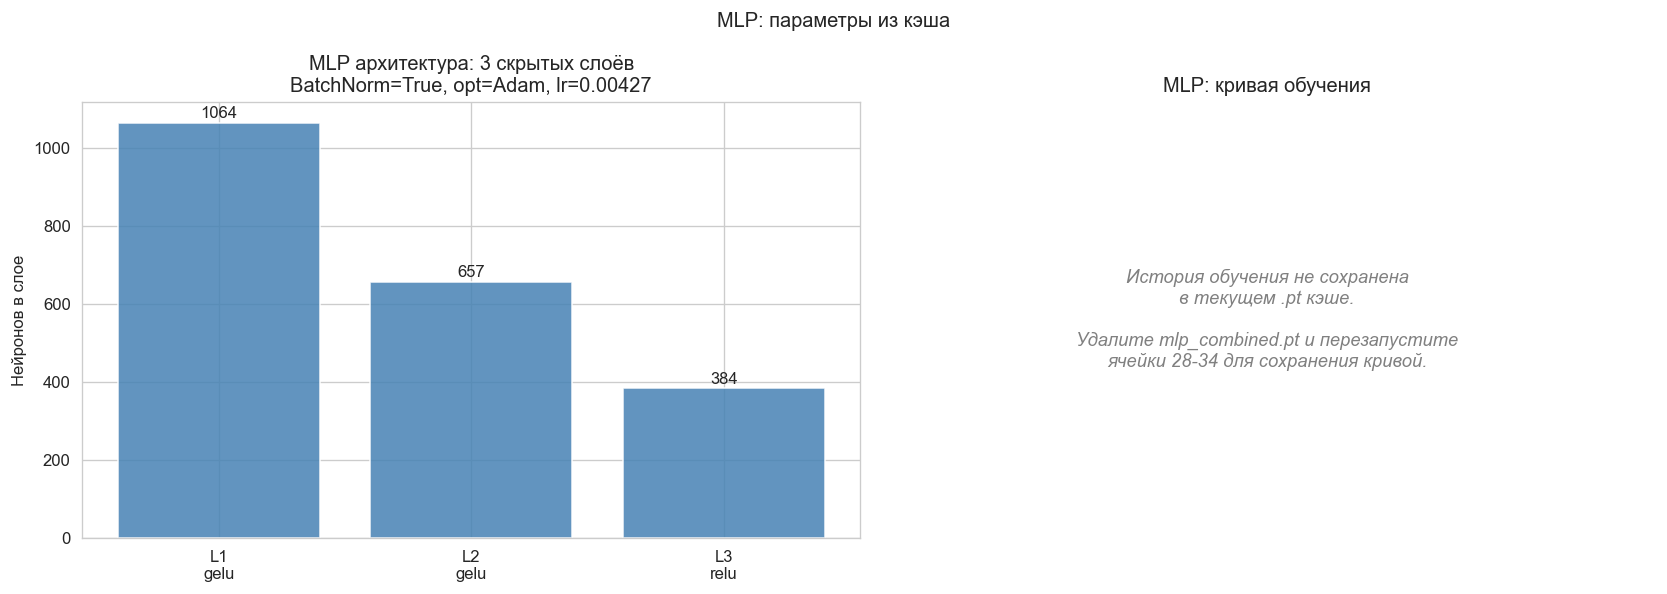


── Optuna история (из предыдущих запусков) ──
  История trials: mlp_optuna_history_trials.png


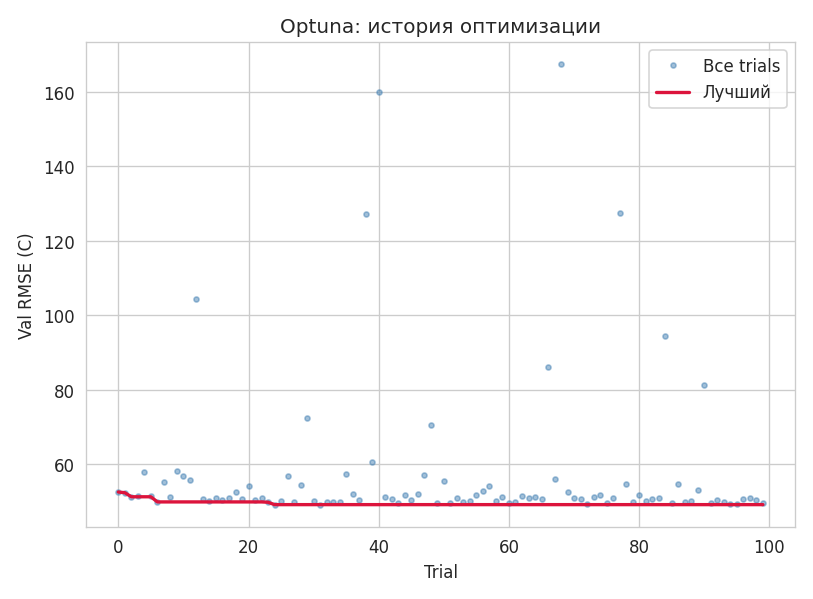

  Важность параметров: mlp_optuna_history_importance.png


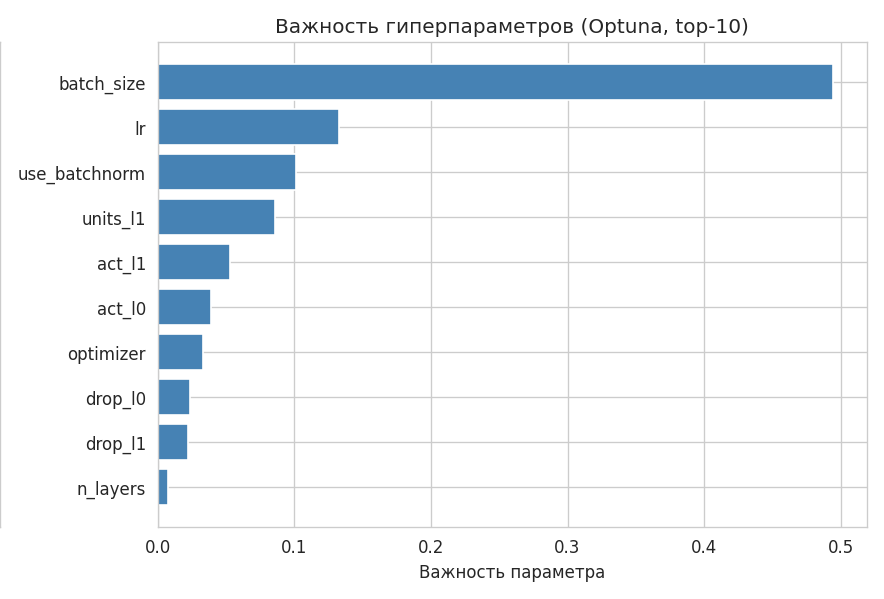

In [229]:
if study is not None:
    trial_values = [t.value for t in study.trials if t.value is not None]
    best_so_far  = np.minimum.accumulate(trial_values)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(trial_values, '.', alpha=0.5, color='steelblue', label='Все trials')
    axes[0].plot(best_so_far,  color='crimson', linewidth=2,     label='Лучший')
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('Val RMSE (°C)')
    axes[0].set_title('Optuna: история оптимизации')
    axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        top_params  = list(importances.keys())[:10]
        axes[1].barh(top_params[::-1], [importances[p] for p in top_params[::-1]],
                     color='steelblue')
        axes[1].set_xlabel('Важность параметра')
        axes[1].set_title('Важность гиперпараметров (Optuna, top-10)')
    except Exception as e:
        axes[1].text(0.5, 0.5, str(e), ha='center', va='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    savefig_panels(fig, axes.flat, FIGURES_DIR / 'mlp_optuna_history',
                   names=['trials', 'importance'])

else:
    # ── Загружено из кэша: показываем параметры и кривую обучения ────────────
    _ck2 = torch.load(_mlp_pt, map_location='cpu', weights_only=False)
    _bp2 = _ck2['best_params']

    print('=== MLP: лучшие гиперпараметры (из кэша) ===')
    print(f'  Оптимизатор : {_bp2["optimizer"]}')
    print(f'  LR          : {_bp2["lr"]:.6f}')
    print(f'  Weight decay: {_bp2["weight_decay"]:.6f}')
    print(f'  Batch size  : {_bp2["batch_size"]}')
    print(f'  BatchNorm   : {_bp2["use_batchnorm"]}')
    print(f'  Слоёв       : {_bp2["n_layers"]}')
    for _i in range(_bp2['n_layers']):
        print(f'    Слой {_i+1}: {_bp2[f"units_l{_i}"]} нейр., '
              f'act={_bp2[f"act_l{_i}"]}, drop={_bp2[f"drop_l{_i}"]:.2f}')

    _sizes  = [_bp2[f'units_l{_i}'] for _i in range(_bp2['n_layers'])]
    _labels = [f'L{_i+1}\n{_bp2[f"act_l{_i}"]}' for _i in range(_bp2['n_layers'])]

    fig_arch, axes_arch = plt.subplots(1, 2, figsize=(14, 5))

    # Архитектура: размеры слоёв
    axes_arch[0].bar(_labels, _sizes, color='steelblue', alpha=0.85, edgecolor='white')
    axes_arch[0].set_ylabel('Нейронов в слое')
    axes_arch[0].set_title(f'MLP архитектура: {_bp2["n_layers"]} скрытых слоёв\n'
                           f'BatchNorm={_bp2["use_batchnorm"]}, '
                           f'opt={_bp2["optimizer"]}, lr={_bp2["lr"]:.5f}')
    for _j, _s in enumerate(_sizes):
        axes_arch[0].text(_j, _s + 4, str(_s), ha='center', va='bottom', fontsize=10)

    # Кривая обучения (если сохранена в .pt)
    _has_curve = ('train_losses' in _ck2 and _ck2.get('train_losses'))
    if _has_curve:
        _tl = _ck2['train_losses']
        axes_arch[1].plot(_tl, color='steelblue', label='Train loss (MSE)')
        if 'val_rmses' in _ck2 and _ck2['val_rmses']:
            _ax2r = axes_arch[1].twinx()
            _ax2r.plot(_ck2['val_rmses'], color='coral', linestyle='--', label='Val RMSE')
            _ax2r.set_ylabel('Val RMSE (°C)', color='coral')
            _ax2r.legend(loc='upper right', fontsize=8)
        axes_arch[1].set_xlabel('Эпоха')
        axes_arch[1].set_ylabel('Train Loss (MSE)')
        axes_arch[1].set_title('MLP: кривая обучения')
        axes_arch[1].legend(loc='upper left', fontsize=8)
    else:
        axes_arch[1].text(0.5, 0.5,
            'История обучения не сохранена\nв текущем .pt кэше.\n\n'
            'Удалите mlp_combined.pt и перезапустите\nячейки 28-34 для сохранения кривой.',
            ha='center', va='center', transform=axes_arch[1].transAxes,
            fontsize=11, color='grey', style='italic')
        axes_arch[1].set_title('MLP: кривая обучения')
        axes_arch[1].set_axis_off()

    plt.suptitle('MLP: параметры из кэша', fontsize=12)
    plt.tight_layout()
    savefig_panels(fig_arch, axes_arch.flat, FIGURES_DIR / 'mlp_params_cache',
                   names=['architecture', 'training_curve'])

    # Показываем Optuna history из ранее сохранённых PNG (если есть)
    _optuna_pngs = [
        ('История trials',       FIGURES_DIR / 'mlp_optuna_history_trials.png'),
        ('Важность параметров',  FIGURES_DIR / 'mlp_optuna_history_importance.png'),
    ]
    _found_optuna = [(k, p) for k, p in _optuna_pngs if p.exists()]
    if _found_optuna:
        from IPython.display import display as _ipy_display, Image as _IpyImg
        print('\n── Optuna история (из предыдущих запусков) ──')
        for _ok, _op in _found_optuna:
            print(f'  {_ok}: {_op.name}')
            _ipy_display(_IpyImg(str(_op)))
    else:
        print('  (Файлы Optuna history не найдены — запустите ячейки 28-31 с Optuna)')


In [230]:
if study is not None:
    n_best = bp['n_layers']
    model_mlp = MLPRegressor(INPUT_DIM,
        layer_sizes=[bp[f'units_l{i}'] for i in range(n_best)],
        act_names  =[bp[f'act_l{i}']   for i in range(n_best)],
        dropouts   =[bp[f'drop_l{i}']  for i in range(n_best)],
        use_batchnorm=bp['use_batchnorm']
    ).to(DEVICE)
    optimizer_mlp = (
        optim.Adam(model_mlp.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
        if bp['optimizer']=='Adam'
        else optim.AdamW(model_mlp.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
    )
    EPOCHS_FINAL = 300
    BATCH_FINAL  = bp['batch_size']
    PATIENCE     = 20          # early stopping: если val не улучшается 20 эпох — стоп
    criterion    = nn.MSELoss()

    # Разбиваем train на sub_train (90%) + val (10%)
    dataset_full = TensorDataset(X_sub_t, y_sub_t)
    loader_full  = DataLoader(dataset_full, batch_size=BATCH_FINAL, shuffle=True)

    best_val = float('inf')
    best_state = None
    no_improve = 0
    train_losses = []
    val_rmses    = []
    t0 = time.time()
    for epoch in range(1, EPOCHS_FINAL + 1):
        model_mlp.train()
        epoch_loss = 0.0
        for xb, yb in loader_full:
            optimizer_mlp.zero_grad()
            loss = criterion(model_mlp(xb), yb)
            loss.backward()
            optimizer_mlp.step()
            epoch_loss += loss.item() * len(yb)
        train_losses.append(epoch_loss / len(y_sub_t))

        # Val check
        model_mlp.eval()
        with torch.no_grad():
            val_rmse = np.sqrt(mean_squared_error(y_val_mlp,
                               model_mlp(X_val_t).cpu().numpy()))
        val_rmses.append(float(val_rmse))
        if val_rmse < best_val - 0.01:
            best_val = val_rmse
            best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stop на эпохе {epoch}, best val RMSE={best_val:.2f}')
            break
        if epoch % 50 == 0:
            print(f'  Epoch {epoch}  train_loss={train_losses[-1]:.2f}  val_rmse={val_rmse:.2f}')

    model_mlp.load_state_dict(best_state)   # откатываемся к лучшим весам
    print(f'Финальное обучение завершено за {time.time()-t0:.1f} с, best val RMSE={best_val:.2f}')
else:
    print('Финальное обучение пропущено (загружено из кэша).')

Финальное обучение пропущено (загружено из кэша).


In [231]:
# ─── Загружаем или используем только что обученную модель ───────────────────
if study is None:
    _mlp_ckpt = torch.load(_mlp_pt, map_location=DEVICE, weights_only=False)
    bp     = _mlp_ckpt['best_params']
    n_best = bp['n_layers']
    model_mlp = MLPRegressor(
        _mlp_ckpt['input_dim'],
        layer_sizes   = [bp[f'units_l{i}'] for i in range(n_best)],
        act_names     = [bp[f'act_l{i}']   for i in range(n_best)],
        dropouts      = [bp[f'drop_l{i}']  for i in range(n_best)],
        use_batchnorm = bp['use_batchnorm']
    ).to(DEVICE)
    model_mlp.load_state_dict(_mlp_ckpt['model_state'])
    print('MLP загружен из кэша.')

model_mlp.eval()

def mlp_predict_np(X_np):
    with torch.no_grad():
        return model_mlp(torch.FloatTensor(X_np).to(DEVICE)).cpu().numpy().ravel()

evaluate('MLP [combined]', mlp_predict_np, X_train_mlp, X_test_mlp,
         y_train, y_test, 'combined')

# Сохраняем .pt только если обучали заново
if study is not None:
    torch.save({'model_state':  model_mlp.state_dict(),
                'best_params':  bp,
                'input_dim':    INPUT_DIM,
                'train_losses': [float(v) for v in train_losses],
                'val_rmses':    [float(v) for v in val_rmses]},
               MODELS_DIR / 'mlp_combined.pt')
    print('MLP сохранён: ../models/mlp_combined.pt')
else:
    print('MLP уже был в кэше — повторное сохранение пропущено.')

MLP загружен из кэша.

  MLP [combined]  [combined]
  R²   — train: 0.9422  |  test: 0.5555
  MAE  — train: 11.02  |  test: 38.32 °C
  RMSE — train: 19.62  |  test: 54.53 °C
MLP уже был в кэше — повторное сохранение пропущено.


## 13. Сравнение моделей

Все модели оцениваются на **одной** тестовой выборке (1715 молекул, `random_state=42`).
Каждая модель обучалась на трёх наборах признаков; анализ включает:

1. **Сводная таблица** — R² CV / Train / Test, MAE, RMSE по всем 30 конфигурациям
2. **Тепловая карта** — зависимость R²_test от набора признаков для каждой модели
3. **Рейтинг лучших конфигураций** — горизонтальные гистограммы R², MAE, RMSE
4. **Анализ переобучения** — Train vs CV vs Test R² для лучших конфигураций
5. **Влияние набора признаков** — побарное R² для каждой модели отдельно
6. **Scatter-диаграммы** — предсказанные vs реальные значения T кип

Цвета наборов: <span style="color:steelblue">■ morgan</span>,
<span style="color:coral">■ rdkit</span>,
<span style="color:mediumseagreen">■ combined</span>

In [232]:
# ═══════════════════════════════════════════════════════════════════════════
# RECOVERY CELL: восстановление всех переменных из кэша после рестарта ядра
# Запускай ПОСЛЕ ячеек 1-8 (импорты + данные + helper-функции)
# Для поддержки MLP также запусти ячейки 28-30 (определение класса MLPRegressor)
# Заменяет ячейки 10-34 если все модели уже обучены
# ═══════════════════════════════════════════════════════════════════════════
_need = False
try:
    _ = best_ridge_fs, best_lgb_fs, model_families
except NameError:
    _need = True

if not _need:
    print('Все переменные уже в памяти.')
else:
    import time as _t_mod
    _t0 = _t_mod.time()
    print('Восстанавливаем переменные из кэша...\n')

    # 1. Результаты из results_cache.json ─────────────────────────────────
    _rc = MODELS_DIR / 'results_cache.json'
    _cvc = MODELS_DIR / 'cv_scores.json'
    _cv_data = {}
    if _cvc.exists():
        with open(_cvc, encoding='utf-8') as _f: _cv_data = json.load(_f)

    if _rc.exists():
        with open(_rc, encoding='utf-8') as _f: _raw = json.load(_f)
        for k, v in _raw.items():
            results[k] = {
                mk: (float('nan') if mv is None
                     else float(mv) if isinstance(mv, (int, float)) else mv)
                for mk, mv in v.items()
            }
        # Обновляем R2_cv из cv_scores.json (более точный источник)
        for label, cv_val in _cv_data.items():
            if label in results:
                results[label]['R2_cv'] = float(cv_val) if cv_val is not None else float('nan')
        print(f'  Результаты загружены: {len(results)} записей')
    else:
        print('  WARN: results_cache.json не найден.')
        print('  Запусти ячейки 10-26 хотя бы один раз для создания кэша.')

    # 2. Загружаем модели из pickle ───────────────────────────────────────
    _specs = [
        ('Ridge',         'ridge'),
        ('Lasso',         'lasso'),
        ('BayesianRidge', 'bayesianridge'),
        ('Random Forest', 'random_forest'),
        ('LightGBM',      'lightgbm'),
        ('XGBoost',       'xgboost'),
        ('CatBoost',      'catboost'),
        ('KNN',           'knn'),
        ('SVR',           'svr'),
    ]
    _fsets = ['morgan', 'rdkit', 'combined']

    best_ridge = {}; best_lasso = {}; best_br  = {}; best_rf  = {}
    best_lgb   = {}; best_xgb   = {}; best_cb  = {}
    best_knn   = {}; best_svr   = {}
    _bmap = {
        'Ridge': best_ridge, 'Lasso': best_lasso, 'BayesianRidge': best_br,
        'Random Forest': best_rf, 'LightGBM': best_lgb, 'XGBoost': best_xgb,
        'CatBoost': best_cb, 'KNN': best_knn, 'SVR': best_svr,
    }

    for mn, pfx in _specs:
        _bd = _bmap[mn]
        for fs in _fsets:
            _p = MODELS_DIR / f'{pfx}_{fs}.pkl'
            if _p.exists():
                _bd[fs] = pickle.load(open(_p, 'rb'))
            else:
                print(f'  WARN: {_p.name} не найден')
        # Если результатов в JSON нет -- вычисляем (медленно, но правильно)
        for fs, model in _bd.items():
            _lbl = f'{mn} [{fs}]'
            if _lbl not in results:
                print(f'  Вычисляем метрики для {_lbl}...')
                X_tr, X_te = feature_sets[fs]
                evaluate(_lbl, model.predict, X_tr, X_te,
                         y_train, y_test, fs, cv_r2=_cv_data.get(_lbl))
        print(f'  {mn:<18}: {list(_bd.keys())}')

    # 3. best_X_fs из results ─────────────────────────────────────────────
    def _bfs(mn):
        r2s = {fs: results.get(f'{mn} [{fs}]', {}).get('R2_test', -999)
               for fs in _fsets if f'{mn} [{fs}]' in results}
        return max(r2s, key=lambda k: r2s[k]) if r2s else 'combined'

    best_ridge_fs = _bfs('Ridge')
    best_lasso_fs = _bfs('Lasso')
    best_br_fs    = _bfs('BayesianRidge')
    best_rf_fs    = _bfs('Random Forest')
    best_lgb_fs   = _bfs('LightGBM')
    best_xgb_fs   = _bfs('XGBoost')
    best_cb_fs    = _bfs('CatBoost')
    best_knn_fs   = _bfs('KNN')
    best_svr_fs   = _bfs('SVR')

    model_families = {
        'Ridge': best_ridge_fs, 'Lasso': best_lasso_fs,
        'BayesianRidge': best_br_fs, 'Random Forest': best_rf_fs,
        'LightGBM': best_lgb_fs, 'XGBoost': best_xgb_fs,
        'CatBoost': best_cb_fs, 'KNN': best_knn_fs, 'SVR': best_svr_fs,
    }

    # 4. MLP ──────────────────────────────────────────────────────────────
    _mlp_pt = MODELS_DIR / 'mlp_combined.pt'
    if _mlp_pt.exists():
        _mlp_ok = False
        try:
            _ = mlp_predict_np; _mlp_ok = True
        except NameError:
            pass
        if not _mlp_ok:
            try:
                _ck = torch.load(_mlp_pt, map_location=DEVICE, weights_only=False)
                _bp2 = _ck['best_params']; _nb2 = _bp2['n_layers']
                model_mlp = MLPRegressor(
                    _ck['input_dim'],
                    layer_sizes=[_bp2[f'units_l{i}'] for i in range(_nb2)],
                    act_names  =[_bp2[f'act_l{i}']   for i in range(_nb2)],
                    dropouts   =[_bp2[f'drop_l{i}']  for i in range(_nb2)],
                    use_batchnorm=_bp2['use_batchnorm']
                ).to(DEVICE)
                model_mlp.load_state_dict(_ck['model_state'])
                model_mlp.eval()
                scaler_mlp  = StandardScaler()
                X_train_mlp = scaler_mlp.fit_transform(X_train_combined).astype(np.float32)
                X_test_mlp  = scaler_mlp.transform(X_test_combined).astype(np.float32)
                def mlp_predict_np(X_np):
                    with torch.no_grad():
                        return model_mlp(
                            torch.FloatTensor(X_np).to(DEVICE)
                        ).cpu().numpy().ravel()
                if 'MLP [combined]' not in results:
                    evaluate('MLP [combined]', mlp_predict_np,
                             X_train_mlp, X_test_mlp, y_train, y_test, 'combined')
                print('  MLP: загружен из кэша')
            except Exception as _e:
                print(f'  MLP: не удалось загрузить ({_e})')
                print('  Запусти ячейки 28-34 вручную для восстановления MLP')
        if 'MLP [combined]' in results:
            model_families['MLP'] = 'combined'

    # 5. ad_results ───────────────────────────────────────────────────────
    try:
        ad_results
    except NameError:
        ad_results = {}

    print(f'\nВосстановление завершено за {_t_mod.time()-_t0:.1f} с')
    print(f'Всего записей в results: {len(results)}')
    print('\nЛучшие наборы признаков:')
    for mn, fs in model_families.items():
        _r2 = results.get(f'{mn} [{fs}]', {}).get('R2_test', float('nan'))
        print(f'  {mn:<18}: [{fs}]  R2_test={_r2:.4f}')


Все переменные уже в памяти.


In [233]:
# ═══════════════════════════════════════════════════════════════════════════
# CV RECOVERY: вычисляет R² CV для кэшированных моделей (один раз)
# Запустить ПОСЛЕ Recovery Cell (ячейки 1-8 + 36)
#
# Оценка времени (CPU, n_jobs=-1):
#   BEST_FS_ONLY=True  : ~10-30 мин (только лучшая конфигурация, 9 CV-запусков)
#   BEST_FS_ONLY=False : ~30-90 мин (все 27 конфигураций)
#   SKIP_SLOW_CV=True  : пропустить KNN и SVR (сэкономить ~10-20 мин)
# ═══════════════════════════════════════════════════════════════════════════
BEST_FS_ONLY = True    # True = CV только для лучшего набора признаков (быстро)
SKIP_SLOW_CV = False   # True = пропустить KNN и SVR

_cv_path = MODELS_DIR / 'cv_scores.json'
_rc_path = MODELS_DIR / 'results_cache.json'
_cv_data = {}
if _cv_path.exists():
    with open(_cv_path, encoding='utf-8') as _f:
        _cv_data = json.load(_f)

_slow_cv = {'KNN', 'SVR'}
_cv_folds = {
    'Ridge': 5, 'Lasso': 5, 'BayesianRidge': 5,
    'Random Forest': 3, 'LightGBM': 3, 'XGBoost': 3, 'CatBoost': 3,
    'KNN': 3, 'SVR': 3,
}
_all_model_dicts = {
    'Ridge':         best_ridge,
    'Lasso':         best_lasso,
    'BayesianRidge': best_br,
    'Random Forest': best_rf,
    'LightGBM':      best_lgb,
    'XGBoost':       best_xgb,
    'CatBoost':      best_cb,
    'KNN':           best_knn,
    'SVR':           best_svr,
}

# --- Патч совместимости sklearn >= 1.6: Pipeline.transform_input ---
# Старые pkl не содержат этот атрибут -> clone() падает в cross_val_score
def _patch_pipe_compat(pipe):
    if hasattr(pipe, 'steps') and not hasattr(pipe, 'transform_input'):
        pipe.transform_input = None
for _mn_p, _d_p in _all_model_dicts.items():
    for _fs_p, _pipe_p in _d_p.items():
        _patch_pipe_compat(_pipe_p)
print('Pipeline compat patch: OK')

# Определяем лучший набор признаков для каждой модели (по R2_test из results)
def _best_fs_for(mn):
    r2s = {fs: results.get(f'{mn} [{fs}]', {}).get('R2_test', -999) or -999
           for fs in ['morgan', 'rdkit', 'combined']}
    return max(r2s, key=lambda k: r2s[k])

# Определяем список (модель, feature_set) для вычисления
_to_compute = []
for mn in _all_model_dicts:
    if BEST_FS_ONLY:
        _to_compute.append((mn, _best_fs_for(mn)))
    else:
        for fs in ['morgan', 'rdkit', 'combined']:
            _to_compute.append((mn, fs))

print(f'Режим: BEST_FS_ONLY={BEST_FS_ONLY}, SKIP_SLOW_CV={SKIP_SLOW_CV}')
print(f'Запусков CV: {len(_to_compute)}\n')

for mn, fs in _to_compute:
    label = f'{mn} [{fs}]'

    if SKIP_SLOW_CV and mn in _slow_cv:
        print(f'  {label}: пропущен (SKIP_SLOW_CV=True)')
        continue

    # Уже есть в cv_scores.json?
    if label in _cv_data and _cv_data[label] is not None:
        _cv_val = float(_cv_data[label])
        if label in results:
            results[label]['R2_cv'] = _cv_val
        print(f'  {label}: кэш  R²CV={_cv_val:.4f}')
        continue

    # Модель не загружена?
    _bd = _all_model_dicts[mn]
    if fs not in _bd:
        print(f'  {label}: модель не загружена — пропуск')
        continue

    _model  = _bd[fs]
    _X_tr   = feature_sets[fs][0]
    _n_cv   = _cv_folds[mn]
    print(f'  {label}: cv={_n_cv}...', end=' ', flush=True)
    _t0 = time.time()
    _sc = cross_val_score(_model, _X_tr, y_train,
                          cv=_n_cv, scoring='r2', n_jobs=-1, verbose=0)
    _cv_r2 = float(_sc.mean())
    _cv_data[label] = _cv_r2
    if label in results:
        results[label]['R2_cv'] = _cv_r2
    print(f'R²={_cv_r2:.4f}  ±{_sc.std():.4f}  [{time.time()-_t0:.0f}с]')

# MLP: CV не применимо (Optuna + early stopping)
if 'MLP [combined]' not in _cv_data:
    _cv_data['MLP [combined]'] = None
    print('  MLP [combined]: CV не применимо (Optuna + early stopping)')

# Сохраняем cv_scores.json
with open(_cv_path, 'w', encoding='utf-8') as _f:
    json.dump(_cv_data, _f, ensure_ascii=False, indent=1)

# Обновляем results_cache.json
def _jjcv(v):
    if isinstance(v, float) and (v != v): return None
    try: return float(v)
    except (TypeError, ValueError): return v

_dump_cv = {k: {mk: _jjcv(mv) for mk, mv in vv.items()} for k, vv in results.items()}
with open(_rc_path, 'w', encoding='utf-8') as _f:
    json.dump(_dump_cv, _f, ensure_ascii=False, indent=1)

print(f'\nSaved cv_scores.json: {len(_cv_data)} entries')
print('results_cache.json updated with R2_cv')


Pipeline compat patch: OK
Режим: BEST_FS_ONLY=True, SKIP_SLOW_CV=False
Запусков CV: 9

  Ridge [rdkit]: кэш  R²CV=0.6222
  Lasso [combined]: кэш  R²CV=0.6342
  BayesianRidge [rdkit]: кэш  R²CV=0.6222
  Random Forest [rdkit]: кэш  R²CV=0.7158
  LightGBM [combined]: кэш  R²CV=0.7137
  XGBoost [rdkit]: кэш  R²CV=0.7289
  CatBoost [rdkit]: кэш  R²CV=0.7279
  KNN [rdkit]: кэш  R²CV=0.6793
  SVR [rdkit]: кэш  R²CV=0.6975

Saved cv_scores.json: 10 entries
results_cache.json updated with R2_cv


In [234]:
df = pd.DataFrame(results).T
df.index.name = 'Модель [набор]'

display_cols = ['R2_cv', 'R2_train', 'R2_test',
                'MAE_train', 'MAE_test', 'RMSE_test', 'Features']
df_disp = df[display_cols].copy()
for col in display_cols[:-1]:
    df_disp[col] = pd.to_numeric(df_disp[col], errors='coerce').round(4)

df_disp.columns = ['R² CV', 'R² train', 'R² test', 'MAE train', 'MAE test',
                   'RMSE test', 'Набор']
df_disp_sorted = df_disp.sort_values('R² test', ascending=False)

# Показываем только лучший набор признаков для каждой модели (по R² test)
_all_mn = ['Ridge','Lasso','BayesianRidge','Random Forest',
           'LightGBM','XGBoost','CatBoost','KNN','SVR','MLP']
_best_idx = []
for _mn in _all_mn:
    _cands = [(k, df_disp_sorted.loc[k,'R² test'])
              for k in df_disp_sorted.index
              if k.startswith(f'{_mn} [')]
    if _cands:
        _best_idx.append(max(_cands, key=lambda x: x[1] if str(x[1])!='nan' else -999)[0])
df_best_only = df_disp_sorted.loc[df_disp_sorted.index.isin(_best_idx)]
print('\n=== СВОДНАЯ ТАБЛИЦА: лучшая конфигурация каждой модели (R² test) ===')
print(df_best_only.to_string())
print('Примечание: R² CV=N/A для MLP (Optuna+early stopping несовместимы с k-fold)')
df_best_only.to_csv('../data_ml/model_results.csv', encoding='utf-8-sig')

# Лучшая конфигурация каждой модели
model_families = {
    'Ridge':         best_ridge_fs,
    'Lasso':         best_lasso_fs,
    'BayesianRidge': best_br_fs,
    'Random Forest': best_rf_fs,
    'LightGBM':      best_lgb_fs,
    'XGBoost':       best_xgb_fs,
    'CatBoost':      best_cb_fs,
    'KNN':           best_knn_fs,
    'SVR':           best_svr_fs,
}
if 'MLP [combined]' in results:
    model_families['MLP'] = 'combined'

print('\n=== ЛУЧШИЙ НАБОР ПРИЗНАКОВ ПО МОДЕЛЯМ ===')
for mn, fs in model_families.items():
    key  = f'{mn} [{fs}]'
    r2   = results[key]['R2_test']
    mae  = results[key]['MAE_test']
    rmse = results[key]['RMSE_test']
    print(f'  {mn:<18}: [{fs}]  R²={r2:.4f}  MAE={mae:.2f}°C  RMSE={rmse:.2f}°C')



=== СВОДНАЯ ТАБЛИЦА: лучшая конфигурация каждой модели (R² test) ===
                        R² CV  R² train  R² test  MAE train  MAE test  RMSE test     Набор
Модель [набор]                                                                            
CatBoost [rdkit]       0.7279    0.9556   0.7010    11.5025   27.7698    44.7243     rdkit
XGBoost [rdkit]        0.7289    0.9778   0.6953     8.0697   28.2541    45.1494     rdkit
LightGBM [combined]    0.7137    0.9070   0.6923    17.2084   29.9312    45.3736  combined
Random Forest [rdkit]  0.7158    0.9366   0.6845    12.7467   29.8265    45.9425     rdkit
SVR [rdkit]            0.6975    0.8189   0.6566    17.7854   27.5593    47.9299     rdkit
KNN [rdkit]            0.6793    1.0000   0.6386     0.0000   32.1758    49.1766     rdkit
Lasso [combined]       0.6342    0.6949   0.6070    33.5247   37.4648    51.2748  combined
BayesianRidge [rdkit]  0.6222    0.6284   0.5907    36.1210   38.2157    52.3329     rdkit
Ridge [rdkit]       

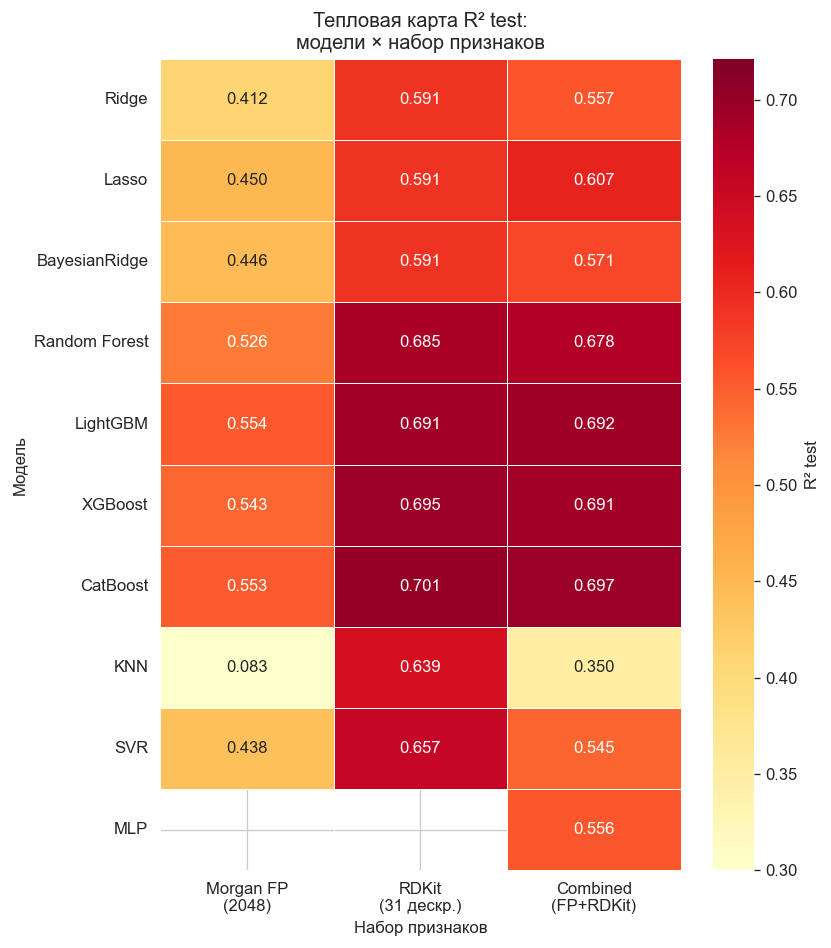

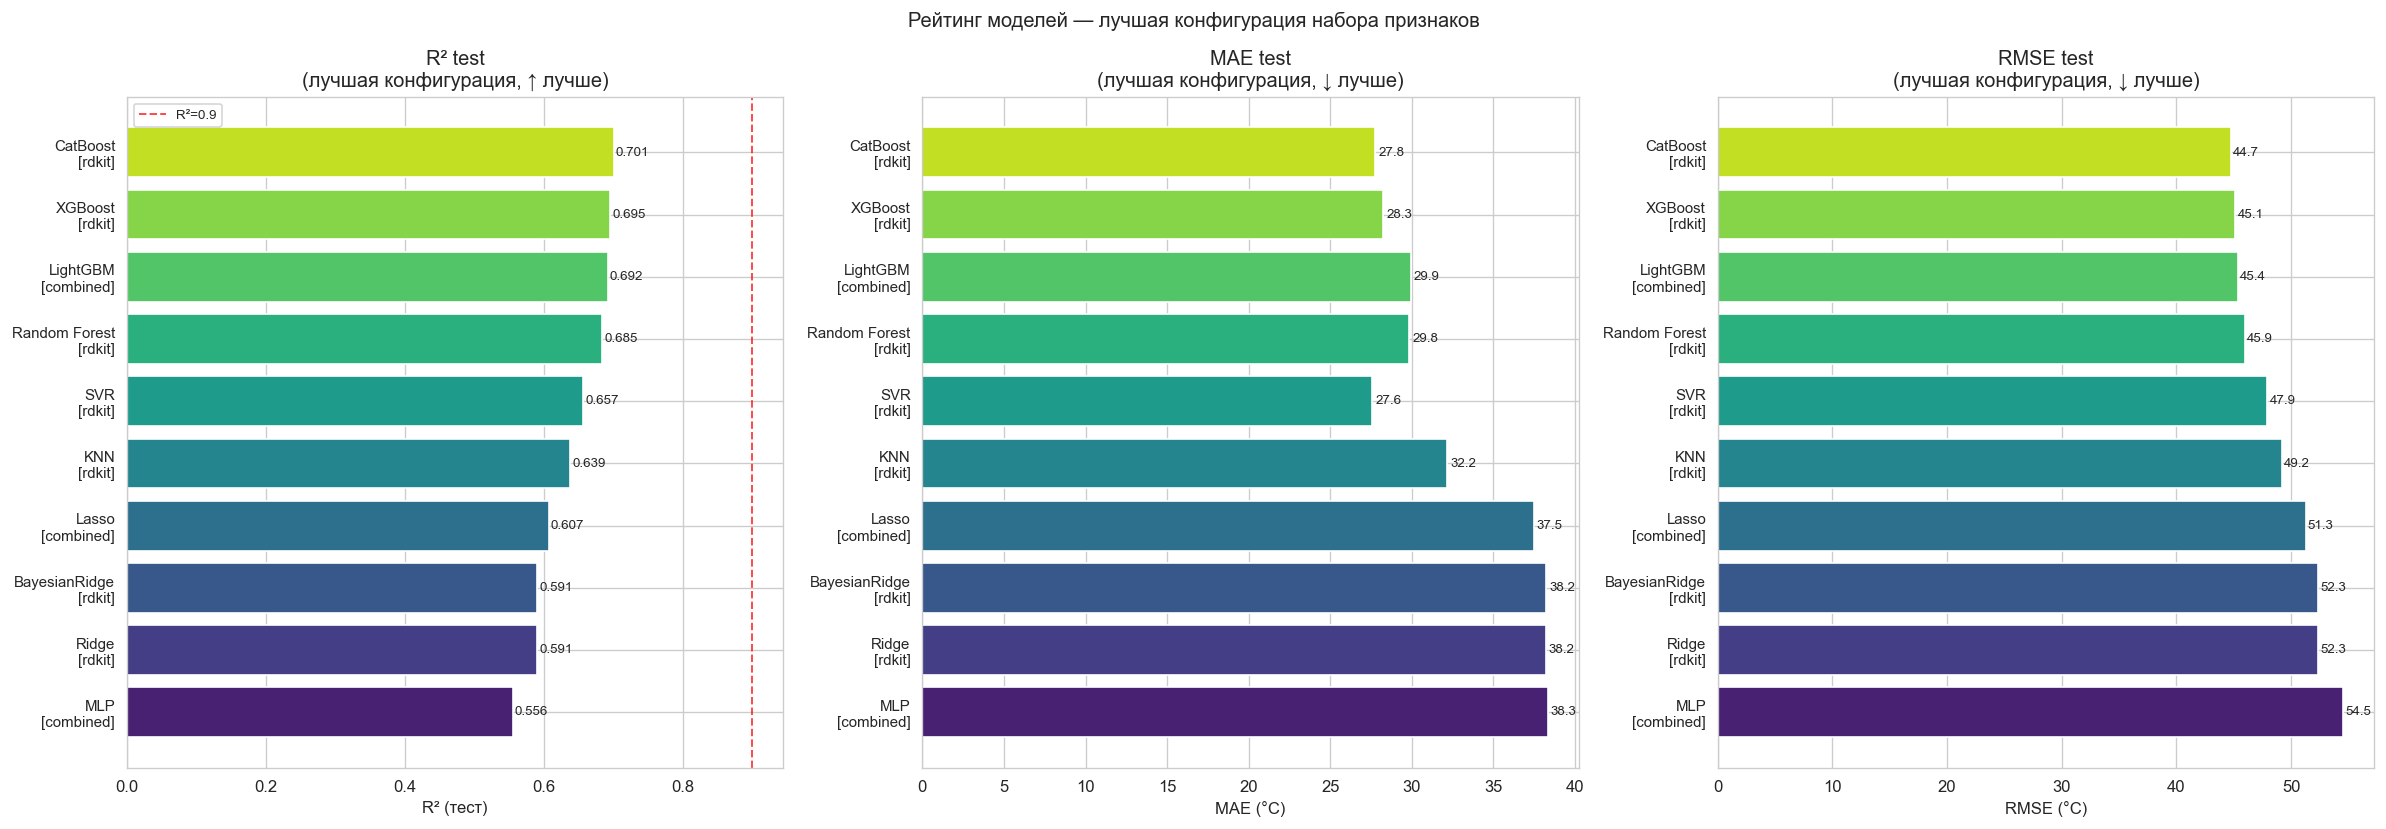

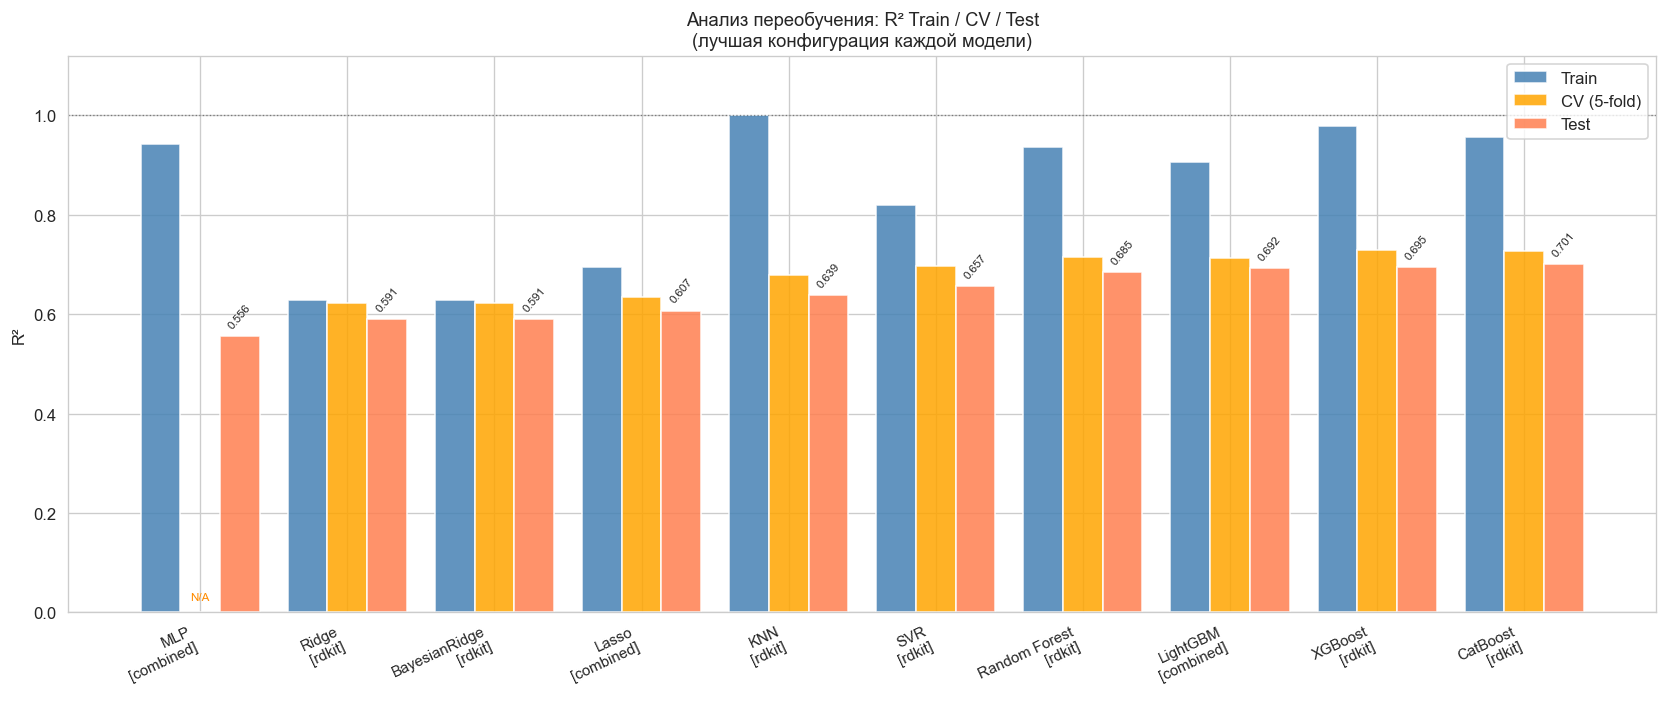

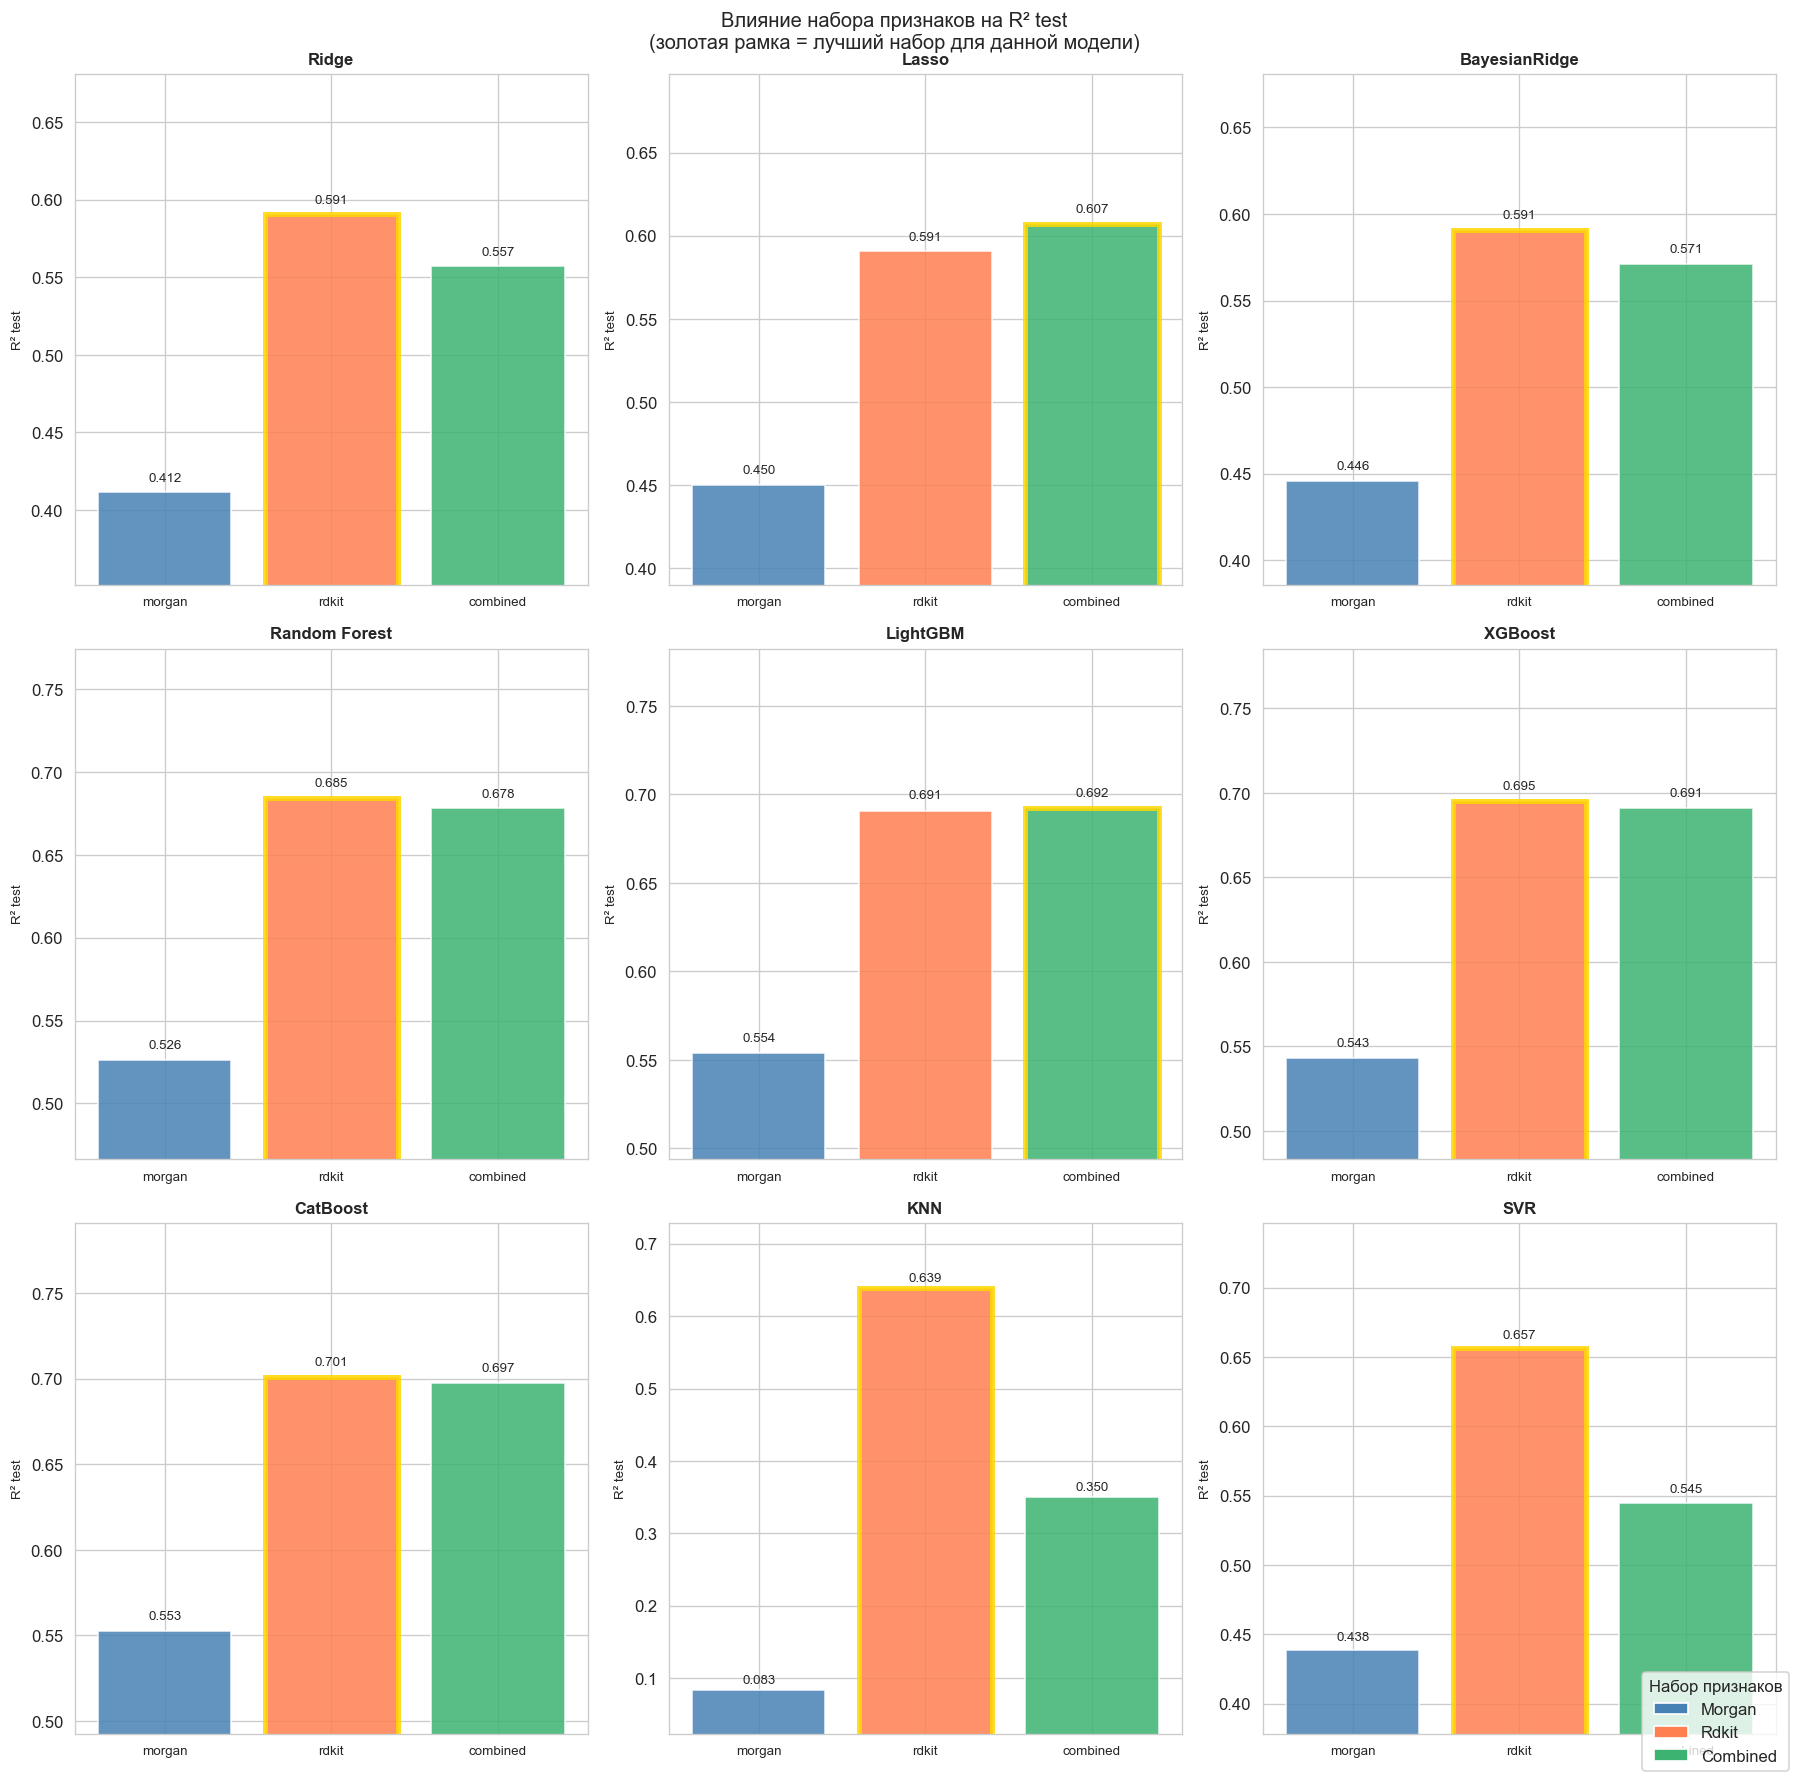

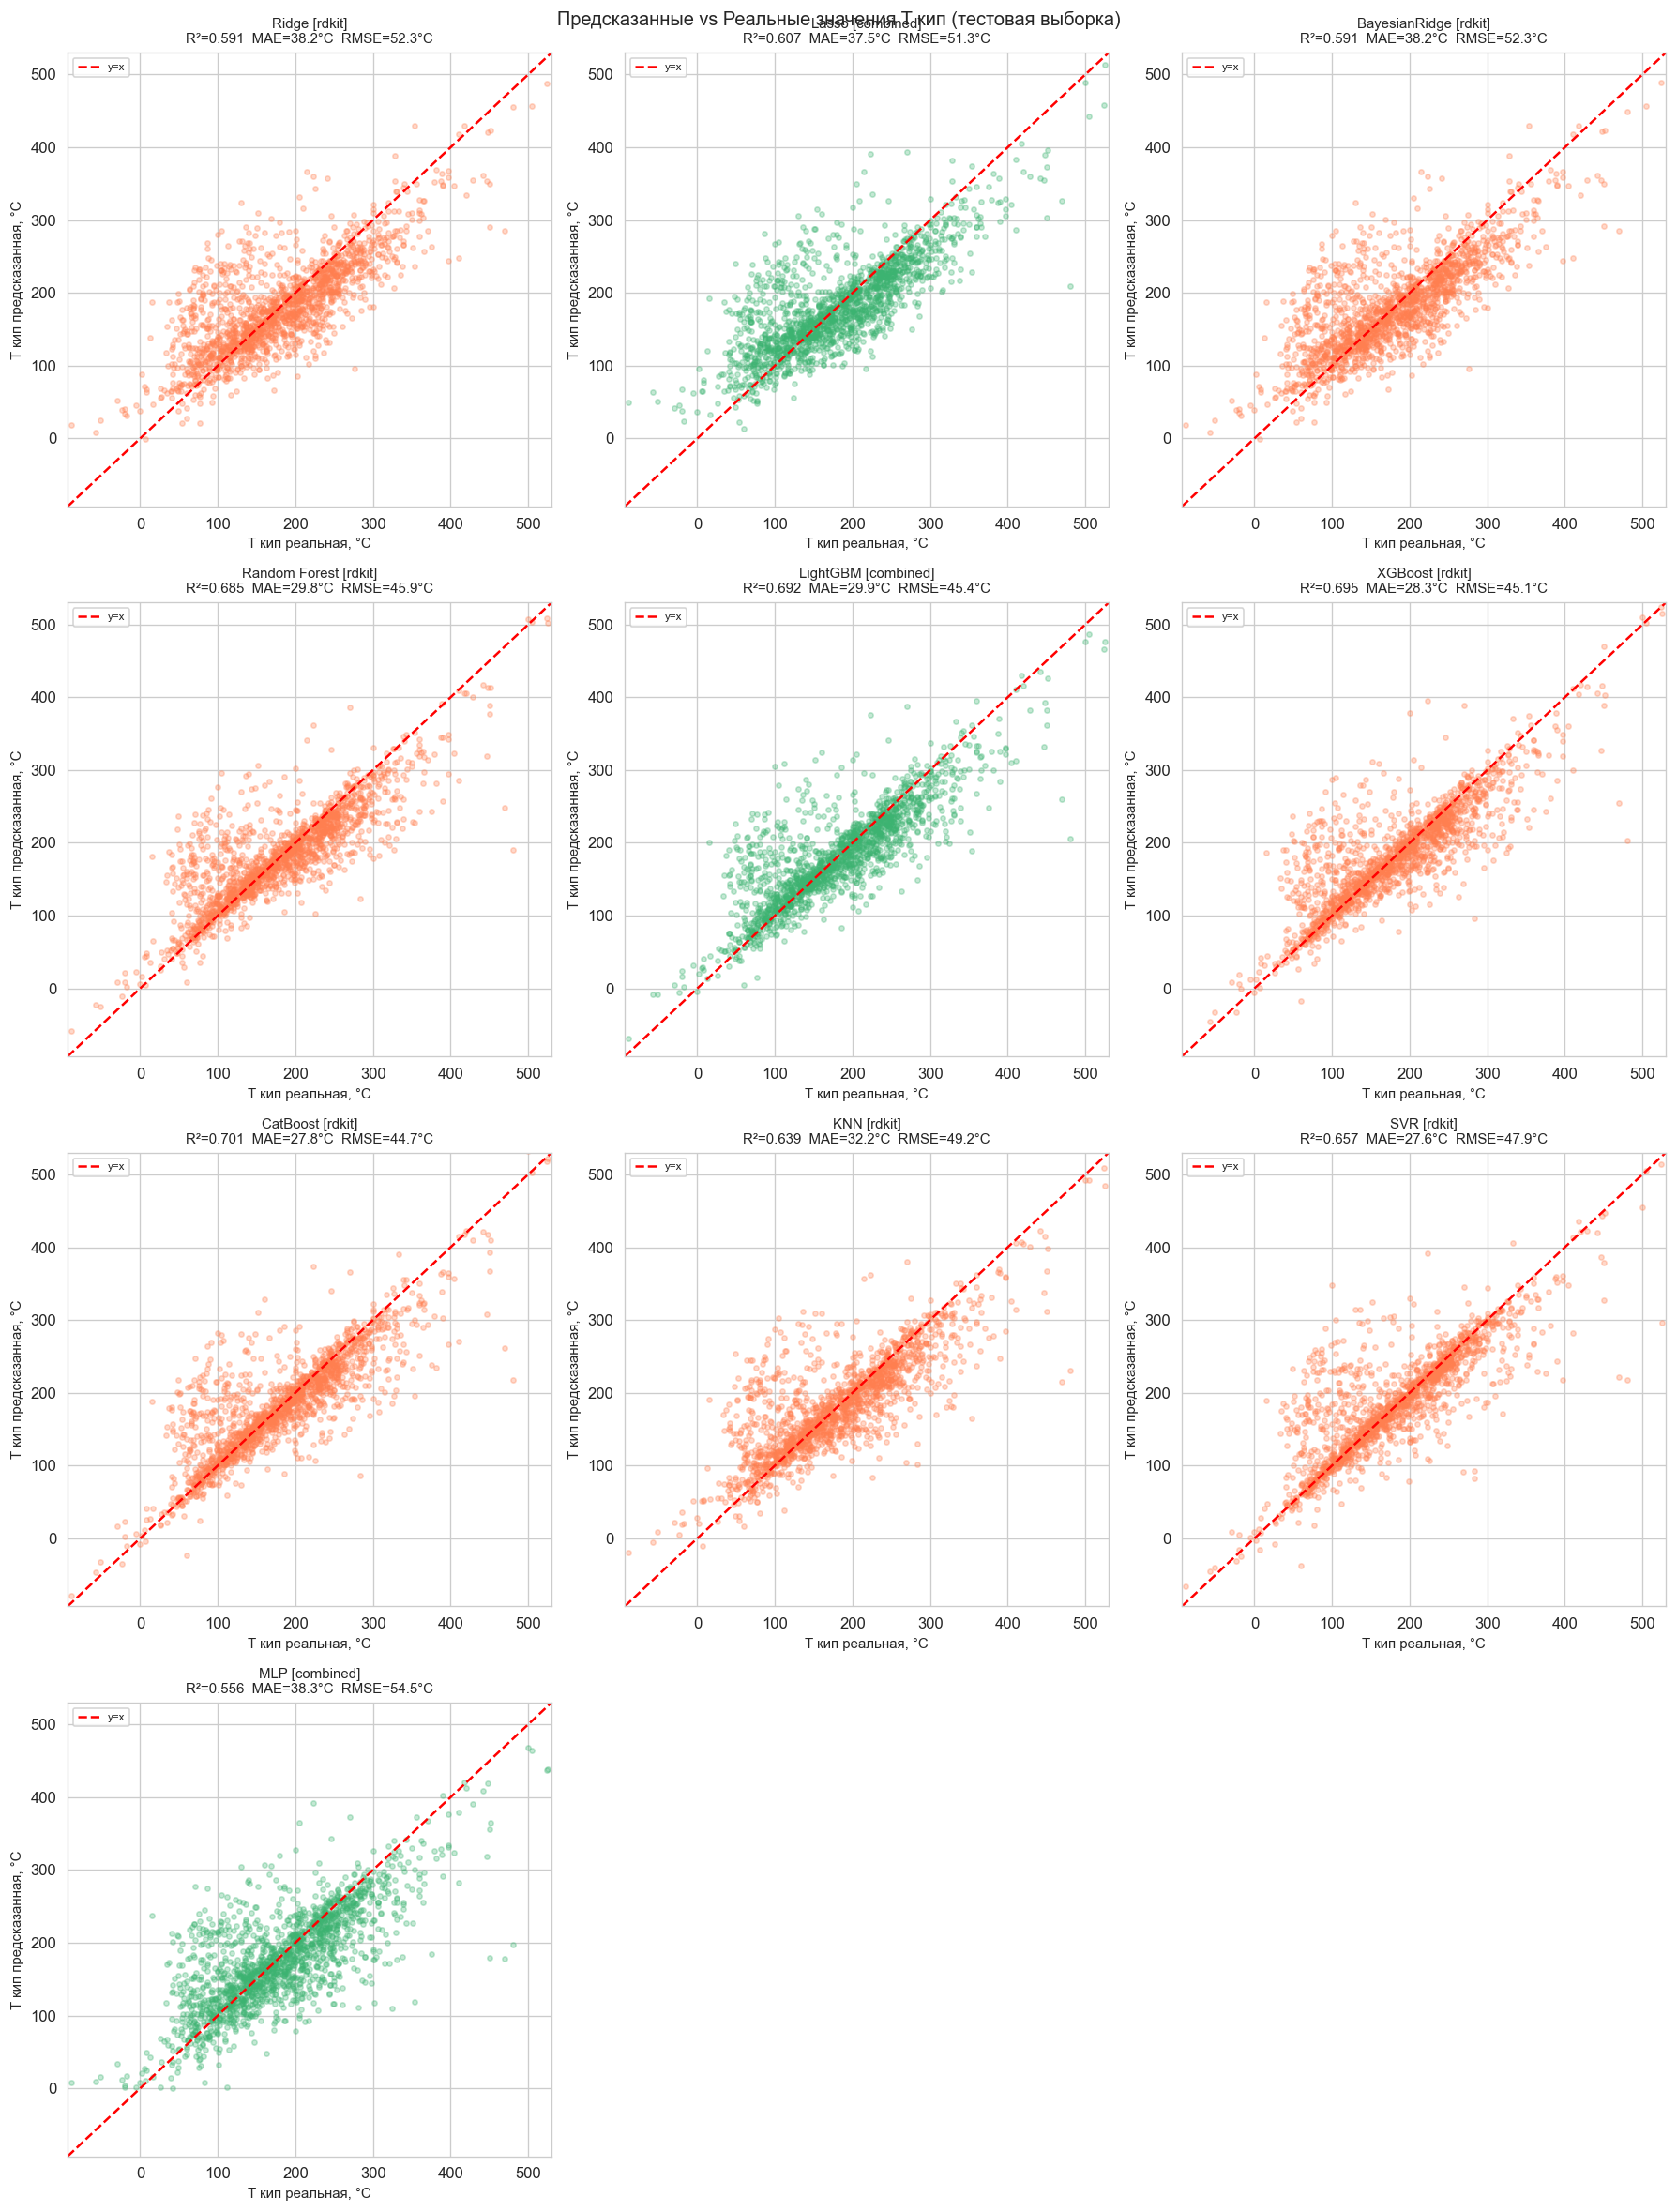

In [235]:
MODEL_NAMES_CLS = ['Ridge', 'Lasso', 'BayesianRidge', 'Random Forest',
                   'LightGBM', 'XGBoost', 'CatBoost', 'KNN', 'SVR']
FS_ORDER = ['morgan', 'rdkit', 'combined']

# ── 1. Тепловая карта R²_test: модели × наборы признаков ─────────────────────
_hm_models = list(MODEL_NAMES_CLS)
_hm_r2_rows = [
    [results.get(f'{mn} [{fs}]', {}).get('R2_test', np.nan) for fs in FS_ORDER]
    for mn in MODEL_NAMES_CLS
]
# Добавляем MLP (только combined FS; morgan и rdkit — NaN)
if 'MLP [combined]' in results:
    _hm_models.append('MLP')
    _hm_r2_rows.append([np.nan, np.nan, results['MLP [combined]']['R2_test']])
heatmap_r2 = np.array(_hm_r2_rows, dtype=float)

_hm_h = 7 + (1 if len(_hm_models) > 9 else 0)
fig_hm, ax_hm = plt.subplots(figsize=(7, _hm_h))
sns.heatmap(heatmap_r2, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['Morgan FP\n(2048)', 'RDKit\n(31 дескр.)', 'Combined\n(FP+RDKit)'],
            yticklabels=_hm_models, ax=ax_hm,
            vmin=max(0.3, float(np.nanmin(heatmap_r2)) - 0.05),
            vmax=min(1.0, float(np.nanmax(heatmap_r2)) + 0.02),
            cbar_kws={'label': 'R² test'}, linewidths=0.5, linecolor='white')
ax_hm.set_title('Тепловая карта R² test:\nмодели × набор признаков', fontsize=12)
ax_hm.set_xlabel('Набор признаков', fontsize=10)
ax_hm.set_ylabel('Модель', fontsize=10)
plt.tight_layout()
fig_hm.savefig(FIGURES_DIR / 'heatmap_r2_features.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2. Рейтинг лучших конфигураций: R², MAE, RMSE ────────────────────────────
best_items  = list(model_families.items())     # [(mn, fs), ...]
best_labels = [f'{mn}\n[{fs}]' for mn, fs in best_items]

def bkey(mn, fs): return f'{mn} [{fs}]'

r2_best   = [results[bkey(mn, fs)]['R2_test']  for mn, fs in best_items]
mae_best  = [results[bkey(mn, fs)]['MAE_test'] for mn, fs in best_items]
rmse_best = [results[bkey(mn, fs)]['RMSE_test']for mn, fs in best_items]

sort_idx  = np.argsort(r2_best)          # по возрастанию → barh снизу вверх
r2_s      = [r2_best[i]    for i in sort_idx]
mae_s     = [mae_best[i]   for i in sort_idx]
rmse_s    = [rmse_best[i]  for i in sort_idx]
lbl_s     = [best_labels[i] for i in sort_idx]

pal = sns.color_palette('viridis', len(sort_idx))

fig_rank, axes_rank = plt.subplots(1, 3, figsize=(20, 7))

# R²
axes_rank[0].barh(range(len(r2_s)), r2_s, color=pal, edgecolor='white')
axes_rank[0].set_yticks(range(len(lbl_s)))
axes_rank[0].set_yticklabels(lbl_s, fontsize=9)
axes_rank[0].set_xlabel('R² (тест)')
axes_rank[0].set_title('R² test\n(лучшая конфигурация, ↑ лучше)')
axes_rank[0].axvline(0.9, color='r', ls='--', lw=1.2, alpha=0.7, label='R²=0.9')
axes_rank[0].legend(fontsize=8)
for i, v in enumerate(r2_s):
    axes_rank[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)

# MAE
axes_rank[1].barh(range(len(mae_s)), mae_s, color=pal, edgecolor='white')
axes_rank[1].set_yticks(range(len(lbl_s)))
axes_rank[1].set_yticklabels(lbl_s, fontsize=9)
axes_rank[1].set_xlabel('MAE (°C)')
axes_rank[1].set_title('MAE test\n(лучшая конфигурация, ↓ лучше)')
for i, v in enumerate(mae_s):
    axes_rank[1].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8)

# RMSE
axes_rank[2].barh(range(len(rmse_s)), rmse_s, color=pal, edgecolor='white')
axes_rank[2].set_yticks(range(len(lbl_s)))
axes_rank[2].set_yticklabels(lbl_s, fontsize=9)
axes_rank[2].set_xlabel('RMSE (°C)')
axes_rank[2].set_title('RMSE test\n(лучшая конфигурация, ↓ лучше)')
for i, v in enumerate(rmse_s):
    axes_rank[2].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8)

plt.suptitle('Рейтинг моделей — лучшая конфигурация набора признаков', fontsize=12)
plt.tight_layout()
savefig_panels(fig_rank, axes_rank.flat, FIGURES_DIR / 'model_ranking',
               names=['r2', 'mae', 'rmse'])

# ── 3. Анализ переобучения: Train / CV / Test R² ─────────────────────────────
r2_tr_s = [results[bkey(*best_items[i])]['R2_train'] for i in sort_idx]
r2_cv_s = [results[bkey(*best_items[i])]['R2_cv']    for i in sort_idx]

x_pos = np.arange(len(sort_idx))
w     = 0.27

fig_of, ax_of = plt.subplots(figsize=(14, 6))
ax_of.bar(x_pos - w, r2_tr_s, w, label='Train',       color='steelblue', alpha=0.85)
# NaN cv_r2 -> рисуем заглушку и подписываем N/A
_cv_plot = [v if not (isinstance(v,float) and v!=v) else 0.0 for v in r2_cv_s]
ax_of.bar(x_pos,     _cv_plot, w, label='CV (5-fold)', color='orange',    alpha=0.85)
ax_of.bar(x_pos + w, r2_s,    w, label='Test',        color='coral',     alpha=0.85)
for _i, _v in enumerate(r2_cv_s):
    if isinstance(_v, float) and _v != _v:  # NaN
        ax_of.text(x_pos[_i], 0.02, 'N/A', ha='center', va='bottom',
                   fontsize=7, color='darkorange', rotation=0)
ax_of.set_xticks(x_pos)
ax_of.set_xticklabels(lbl_s, rotation=25, ha='right', fontsize=9)
ax_of.set_ylabel('R²')
ax_of.set_title('Анализ переобучения: R² Train / CV / Test\n'
                '(лучшая конфигурация каждой модели)', fontsize=11)
ax_of.set_ylim(0, 1.12)
ax_of.legend(fontsize=10)
ax_of.axhline(1.0, color='k', ls=':', lw=0.8, alpha=0.4)
for i, v in enumerate(r2_s):
    ax_of.text(x_pos[i] + w, v + 0.012, f'{v:.3f}',
               ha='center', va='bottom', fontsize=7, rotation=50)
plt.tight_layout()
fig_of.savefig(FIGURES_DIR / 'overfitting_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 4. Влияние набора признаков на R²_test для каждой модели ─────────────────
n_cls    = len(MODEL_NAMES_CLS)
n_cols_f = 3
n_rows_f = (n_cls + n_cols_f - 1) // n_cols_f

fig_fs, axes_fs = plt.subplots(n_rows_f, n_cols_f, figsize=(15, 5 * n_rows_f))
axes_fs_flat = axes_fs.flatten()

for ax, mn in zip(axes_fs_flat, MODEL_NAMES_CLS):
    r2_vals = [results.get(f'{mn} [{fs}]', {}).get('R2_test', 0.0) for fs in FS_ORDER]
    bars = ax.bar(FS_ORDER, r2_vals,
                  color=[FS_COLORS[fs] for fs in FS_ORDER],
                  alpha=0.85, edgecolor='white', linewidth=1)
    ax.set_title(mn, fontsize=10, fontweight='bold')
    ax.set_ylabel('R² test', fontsize=8)
    ax.set_ylim(max(0, min(r2_vals) - 0.06), min(1.0, max(r2_vals) + 0.09))
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    best_i = int(np.argmax(r2_vals))
    bars[best_i].set_edgecolor('gold')
    bars[best_i].set_linewidth(3)

for ax in axes_fs_flat[n_cls:]:
    ax.set_visible(False)

legend_handles = [Patch(facecolor=FS_COLORS[fs], label=fs.capitalize())
                  for fs in FS_ORDER]
fig_fs.legend(handles=legend_handles, loc='lower right',
              fontsize=10, title='Набор признаков')
plt.suptitle('Влияние набора признаков на R² test\n'
             '(золотая рамка = лучший набор для данной модели)', fontsize=12)
plt.tight_layout()

fs_names_safe = [mn.lower().replace(' ', '_') for mn in MODEL_NAMES_CLS]
fs_names_safe += [f'empty_{j}' for j in range(len(axes_fs_flat) - n_cls)]
savefig_panels(fig_fs, axes_fs_flat, FIGURES_DIR / 'feature_set_effect',
               names=fs_names_safe)

# ── 5. Scatter: предсказанные vs реальные (лучшая конфигурация) ──────────────
model_dict_map = {
    'Ridge':         best_ridge,
    'Lasso':         best_lasso,
    'BayesianRidge': best_br,
    'Random Forest': best_rf,
    'LightGBM':      best_lgb,
    'XGBoost':       best_xgb,
    'CatBoost':      best_cb,
    'KNN':           best_knn,
    'SVR':           best_svr,
}

best_preds = {}
for mn, fs in model_families.items():
    if mn == 'MLP':
        try:
            best_preds['MLP'] = mlp_predict_np(X_test_mlp)
        except NameError:
            pass
        continue
    best_preds[mn] = model_dict_map[mn][fs].predict(feature_sets[fs][1])

n_sc    = len(best_preds)
n_cols_sc = 3
n_rows_sc = (n_sc + n_cols_sc - 1) // n_cols_sc

fig_sc, axes_sc = plt.subplots(n_rows_sc, n_cols_sc,
                                figsize=(15, 5 * n_rows_sc))
axes_sc_flat = axes_sc.flatten()
mn_mx = (float(y_test.min()) - 5, float(y_test.max()) + 5)
pred_items = list(best_preds.items())

for i, (mn, yp) in enumerate(pred_items):
    ax  = axes_sc_flat[i]
    fs  = model_families[mn]
    res = results[f'{mn} [{fs}]']
    r2, mae, rmse = res['R2_test'], res['MAE_test'], res['RMSE_test']
    ax.scatter(y_test, yp, alpha=0.3, s=10,
               color=FS_COLORS.get(fs, 'steelblue'))
    ax.plot(mn_mx, mn_mx, 'r--', lw=1.5, label='y=x')
    ax.set_xlim(*mn_mx);  ax.set_ylim(*mn_mx)
    ax.set_xlabel('T кип реальная, °C', fontsize=9)
    ax.set_ylabel('T кип предсказанная, °C', fontsize=9)
    ax.set_title(f'{mn} [{fs}]\nR²={r2:.3f}  MAE={mae:.1f}°C  RMSE={rmse:.1f}°C',
                 fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(pred_items), len(axes_sc_flat)):
    axes_sc_flat[j].set_visible(False)

plt.suptitle('Предсказанные vs Реальные значения T кип (тестовая выборка)', fontsize=12)
plt.tight_layout()

sc_names = [mn.lower().replace(' ', '_') for mn, _ in pred_items]
sc_names += [f'empty_{j}' for j in range(len(axes_sc_flat) - len(pred_items))]
savefig_panels(fig_sc, axes_sc_flat, FIGURES_DIR / 'scatter_models', names=sc_names)

## 14. Область применимости (Williams plot)

**Область применимости (AD, Applicability Domain)** — это область признакового пространства, в которой модель делает надёжные предсказания.

**Williams plot** (Tropsha et al., 2003): по оси X — leverage $h_i = x_i^T(X_{\text{train}}^T X_{\text{train}})^{-1}x_i$ (степень «удалённости» молекулы от центроида обучающей выборки), по оси Y — стандартизированные остатки. Молекула **в AD**, если $h_i \le h^* = 3(p+1)/n_{\text{train}}$ И $|\text{res}_i| \le 3\sigma$.

Для высокоразмерных матриц (Morgan FP: p=2048) перед вычислением hat-матрицы применяется PCA-проекция на 50 главных компонент.

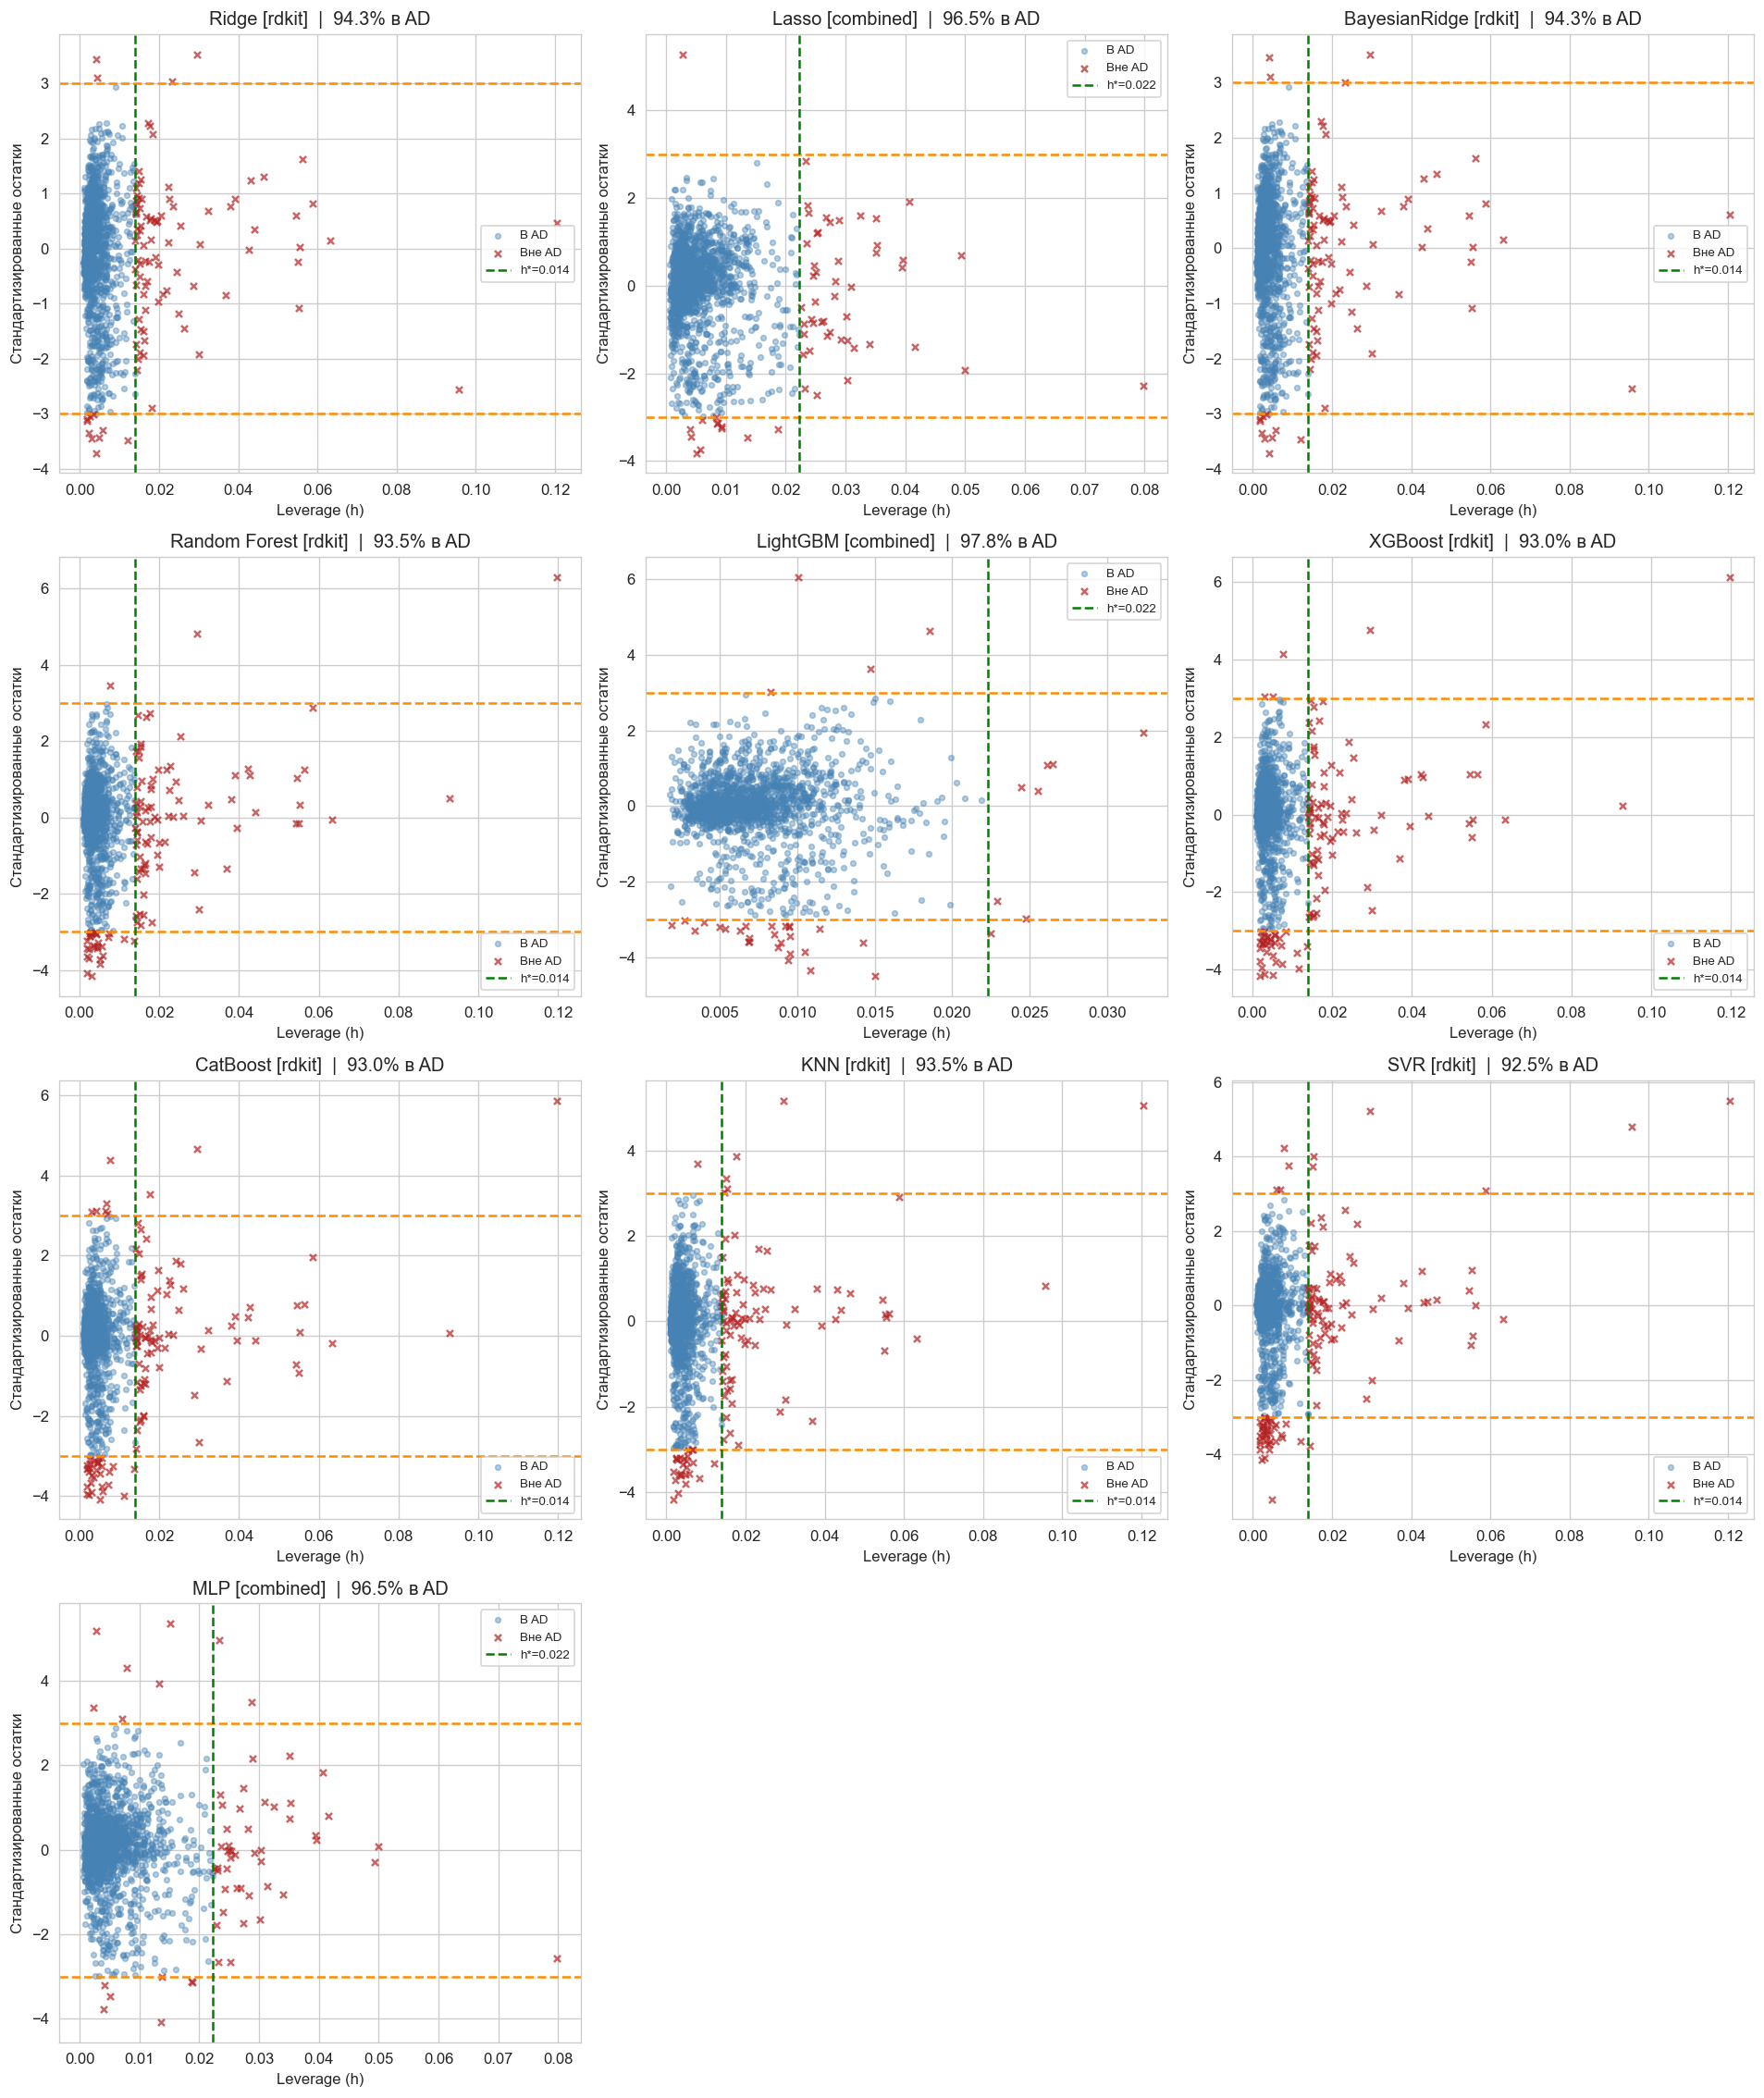


=== ОБЛАСТЬ ПРИМЕНИМОСТИ (% молекул в AD) ===
  Ridge [rdkit]                 :  94.3%  (leverage-выбросы: 85, residual-выбросы: 14)
  Lasso [combined]              :  96.5%  (leverage-выбросы: 47, residual-выбросы: 13)
  BayesianRidge [rdkit]         :  94.3%  (leverage-выбросы: 85, residual-выбросы: 14)
  Random Forest [rdkit]         :  93.5%  (leverage-выбросы: 83, residual-выбросы: 31)
  LightGBM [combined]           :  97.8%  (leverage-выбросы: 8, residual-выбросы: 31)
  XGBoost [rdkit]               :  93.0%  (leverage-выбросы: 83, residual-выбросы: 39)
  CatBoost [rdkit]              :  93.0%  (leverage-выбросы: 83, residual-выбросы: 40)
  KNN [rdkit]                   :  93.5%  (leverage-выбросы: 85, residual-выбросы: 32)
  SVR [rdkit]                   :  92.5%  (leverage-выбросы: 85, residual-выбросы: 50)
  MLP [combined]                :  96.5%  (leverage-выбросы: 47, residual-выбросы: 15)


In [236]:
fig, axes = plt.subplots(4, 3, figsize=(16, 19))
axes_flat = axes.flatten()

model_data = [
    ('Ridge',         best_ridge,  best_ridge_fs),
    ('Lasso',         best_lasso,  best_lasso_fs),
    ('BayesianRidge', best_br,     best_br_fs),
    ('Random Forest', best_rf,     best_rf_fs),
    ('LightGBM',      best_lgb,    best_lgb_fs),
    ('XGBoost',       best_xgb,    best_xgb_fs),
    ('CatBoost',      best_cb,     best_cb_fs),
    ('KNN',           best_knn,    best_knn_fs),
    ('SVR',           best_svr,    best_svr_fs),
]

wp_names = [f'{mn.lower().replace(" ", "_")}_{fs}' for mn, _, fs in model_data]

for ax, (mn, best_dict, best_fs) in zip(axes_flat, model_data):
    X_tr, X_te = feature_sets[best_fs]
    model_obj  = best_dict[best_fs]

    if hasattr(model_obj, 'named_steps') and 'scaler' in model_obj.named_steps:
        sc      = model_obj.named_steps['scaler']
        X_tr_sc = sc.transform(X_tr)
        X_te_sc = sc.transform(X_te)
    else:
        X_tr_sc = X_tr
        X_te_sc = X_te

    y_pred  = model_obj.predict(X_te)
    ad_info = williams_plot(X_tr_sc, X_te_sc, y_test, y_pred,
                            f'{mn} [{best_fs}]', ax=ax)
    ad_results[f'{mn} [{best_fs}]'] = ad_info

# MLP: X_train_mlp / X_test_mlp уже нормализованы StandardScaler
_ax_mlp = axes_flat[9]
try:
    _y_pred_mlp = mlp_predict_np(X_test_mlp)
    _ad_mlp = williams_plot(X_train_mlp, X_test_mlp, y_test, _y_pred_mlp,
                            'MLP [combined]', ax=_ax_mlp)
    ad_results['MLP [combined]'] = _ad_mlp
    wp_names.append('mlp_combined')
except NameError:
    _ax_mlp.text(0.5, 0.5, 'MLP недоступен\n(запустите ячейки 28-34)',
                 ha='center', va='center', transform=_ax_mlp.transAxes,
                 fontsize=10, color='grey', style='italic')
    _ax_mlp.set_title('MLP [combined]')
    wp_names.append('mlp_combined_skip')

# Скрыть пустые субплоты (10 и 11)
for _j in range(10, len(axes_flat)):
    axes_flat[_j].set_visible(False)

plt.tight_layout()
savefig_panels(fig, axes_flat, FIGURES_DIR / 'williams_plots',
               names=wp_names + [f'empty_{_k}' for _k in range(len(axes_flat)-len(wp_names))],
               show=True)

print('\n=== ОБЛАСТЬ ПРИМЕНИМОСТИ (% молекул в AD) ===')
for key, info in ad_results.items():
    print(f'  {key:<30}: {info["pct_in_ad"]:5.1f}%  '
          f'(leverage-выбросы: {info["n_outliers_leverage"]}, '
          f'residual-выбросы: {info["n_outliers_residual"]})')


## 15. Химическая интерпретация через SHAP

SHAP-значения (SHapley Additive exPlanations) позволяют связать математические признаки с физической химией межмолекулярных взаимодействий, определяющих температуру кипения.

$$T_{\text{кип}} \sim \Delta H_{\text{vap}} =
\Delta H_{\text{дисп}} + \Delta H_{\text{диполь}} +
\Delta H_{\text{H-связь}} + \Delta H_{\pi\text{-стэк}}$$

SHAP строится для **лучшей конфигурации** каждой модели. Для древесных моделей используется `TreeExplainer` (точный), для линейных — `LinearExplainer`, для KNN/SVR — `KernelExplainer` (приближённый, на подвыборке 200 молекул).


SHAP: Ridge [rdkit]  R²_test=0.5906
  SHAP из кэша: shap_ridge_rdkit.pkl
  SHAP shapes: sv=(300, 31), Xp=(300, 31), fnames=31


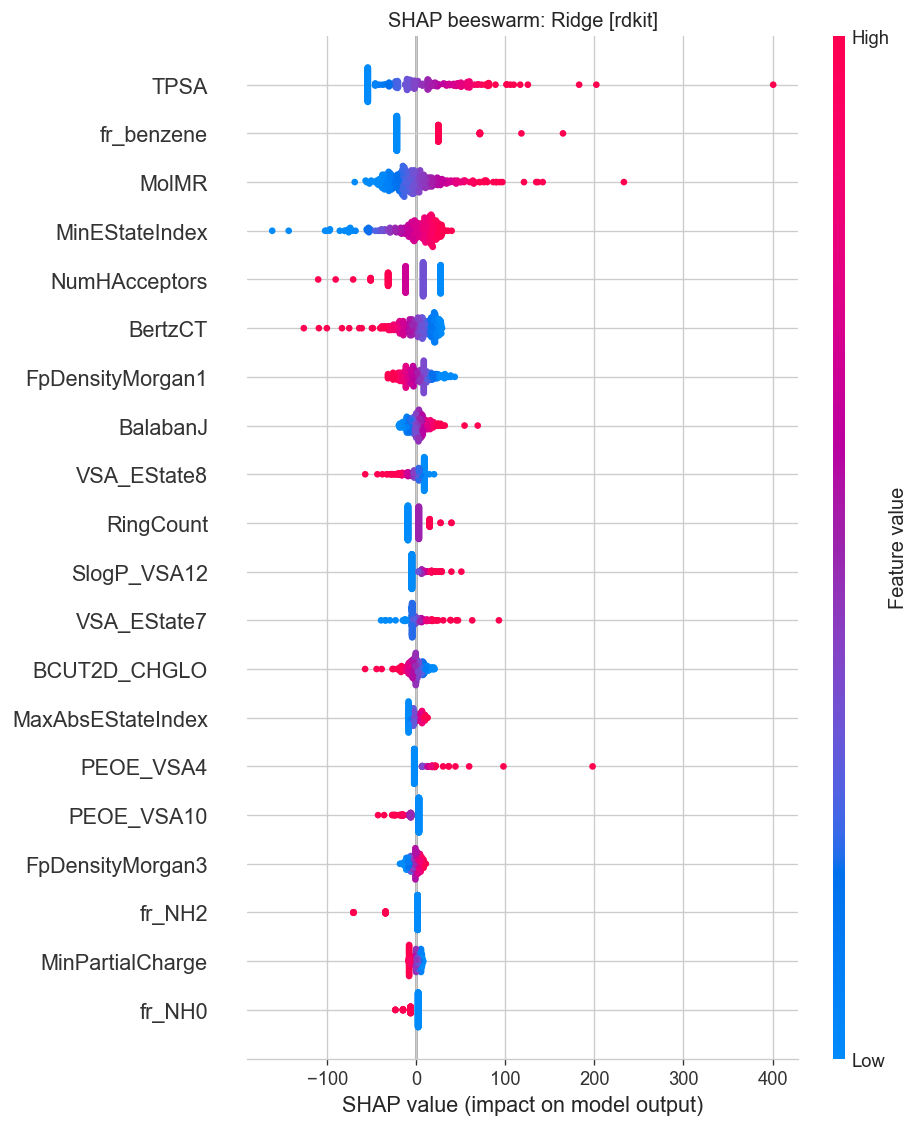

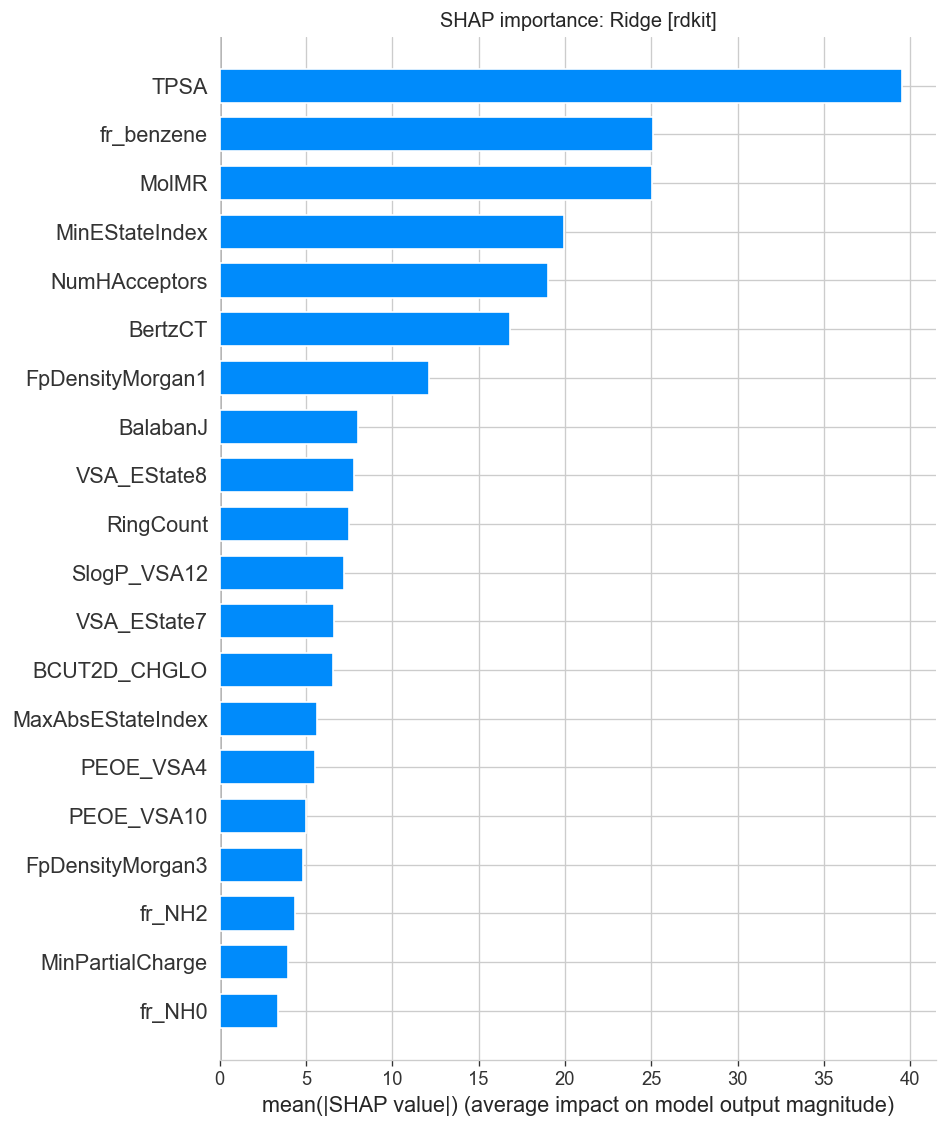

  ✓ shap_beeswarm_ridge_rdkit.png,  shap_bar_ridge_rdkit.png

SHAP: Lasso [combined]  R²_test=0.6070
  SHAP из кэша: shap_lasso_combined.pkl
  SHAP shapes: sv=(300, 25), Xp=(300, 25), fnames=25


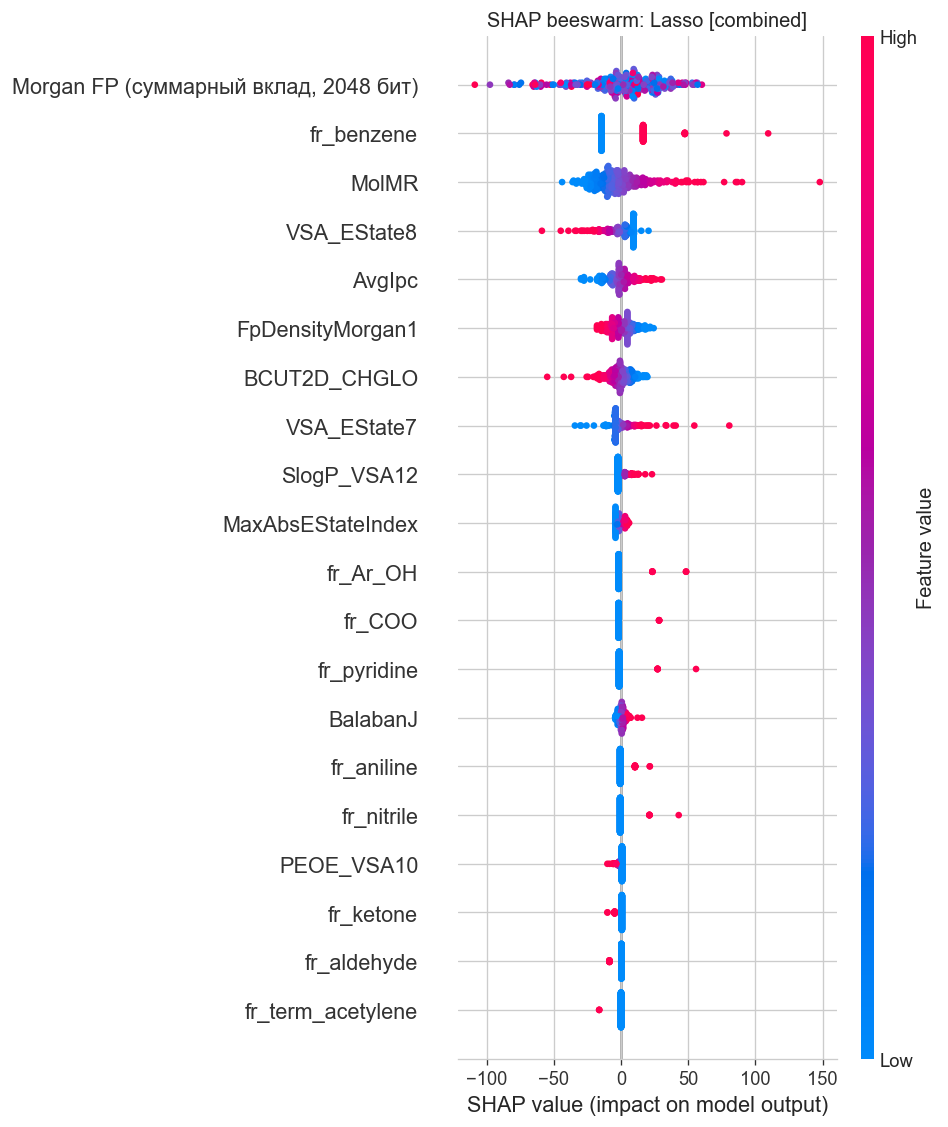

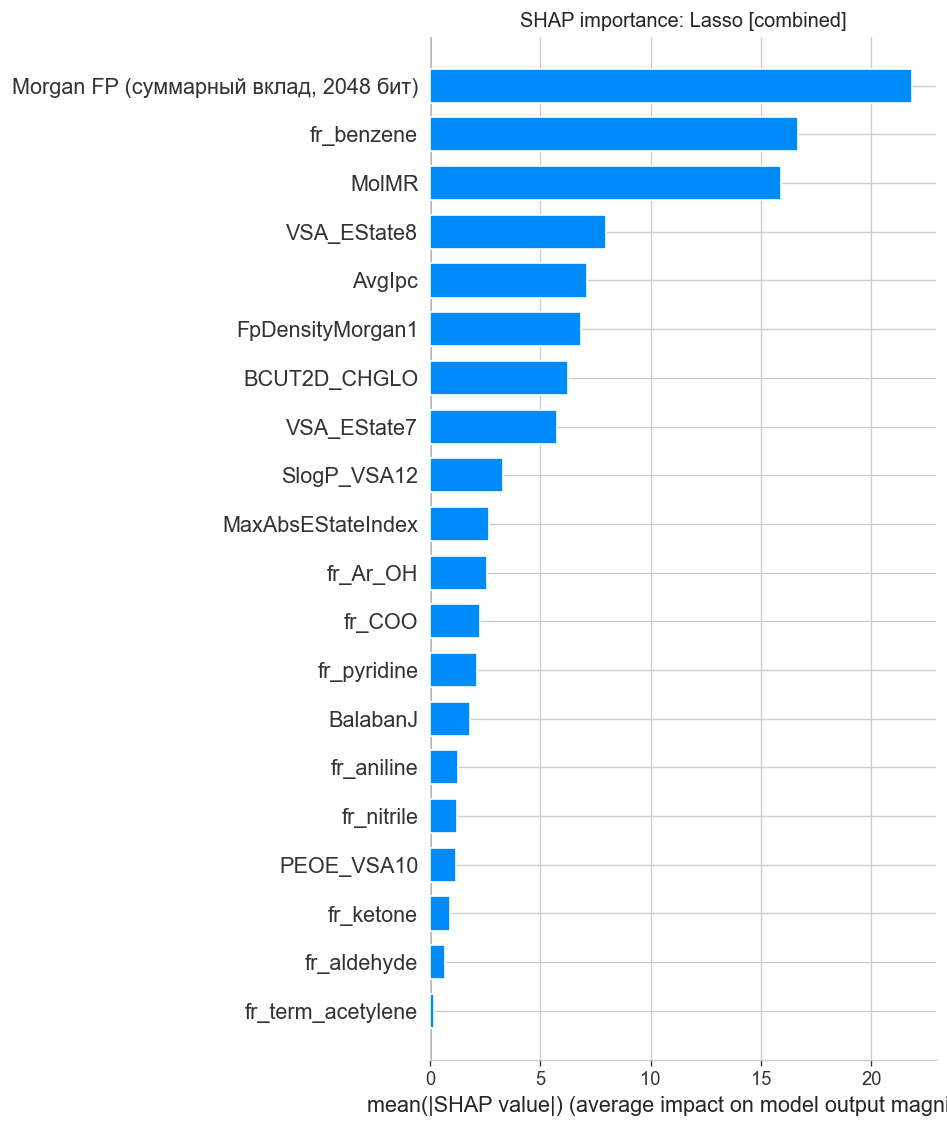

  ✓ shap_beeswarm_lasso_combined.png,  shap_bar_lasso_combined.png

SHAP: BayesianRidge [rdkit]  R²_test=0.5907
  SHAP из кэша: shap_bayesianridge_rdkit.pkl
  SHAP shapes: sv=(300, 31), Xp=(300, 31), fnames=31


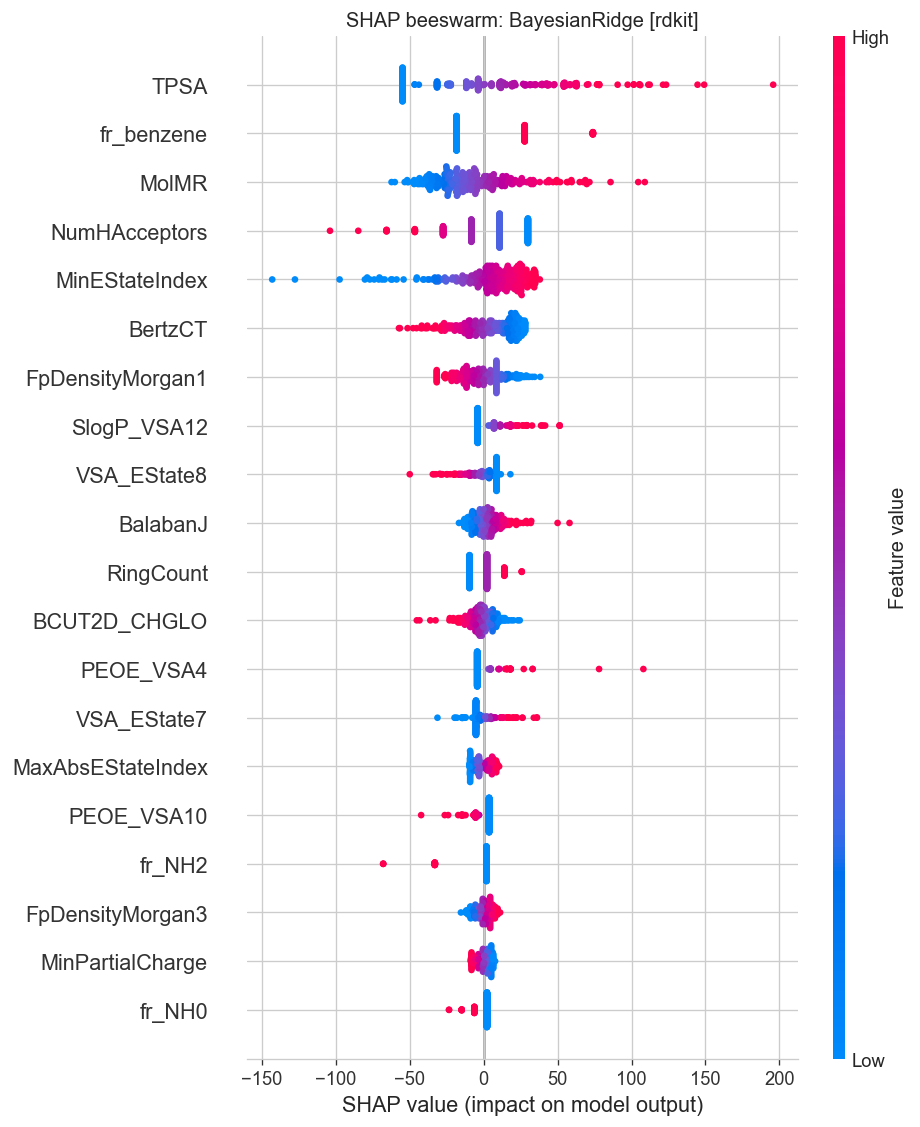

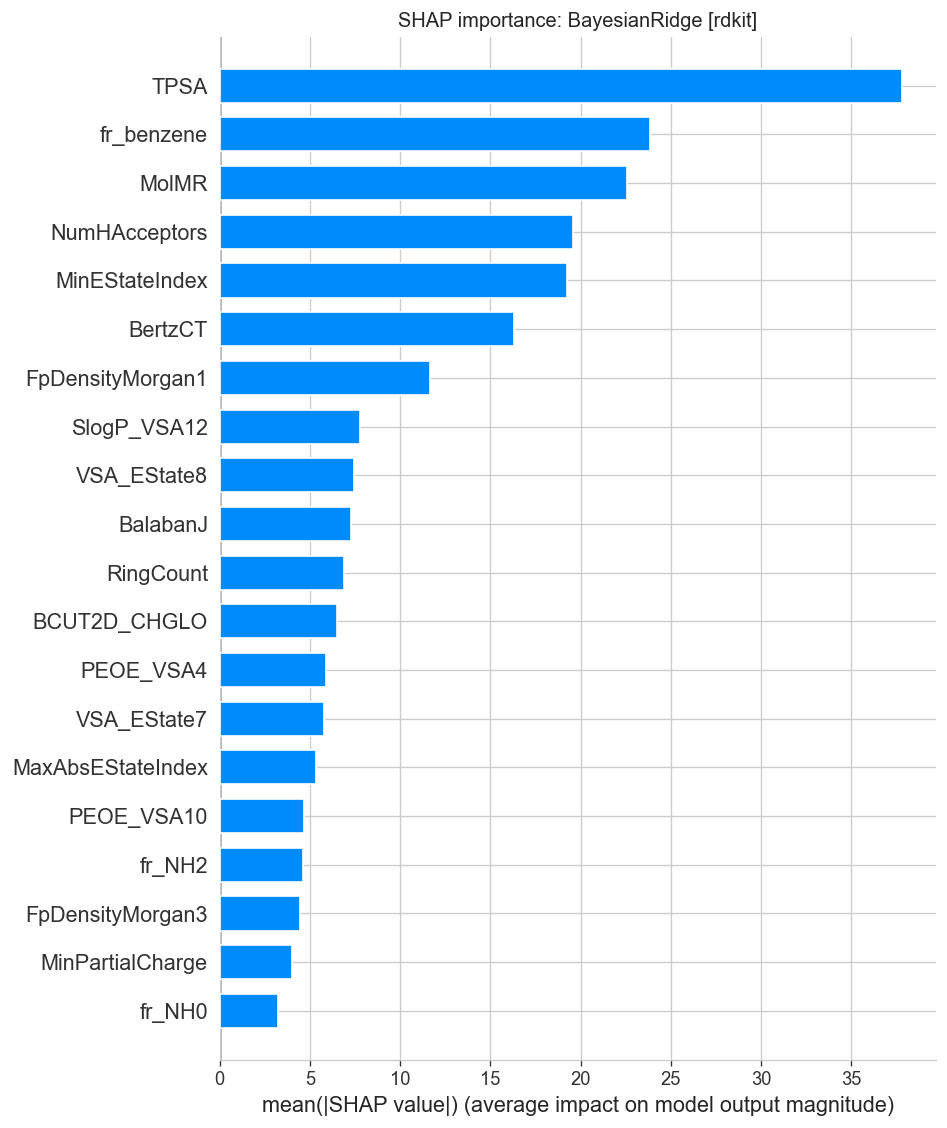

  ✓ shap_beeswarm_bayesianridge_rdkit.png,  shap_bar_bayesianridge_rdkit.png

SHAP: Random Forest [rdkit]  R²_test=0.6845
  SHAP из кэша: shap_random_forest_rdkit.pkl
  SHAP shapes: sv=(300, 31), Xp=(300, 31), fnames=31


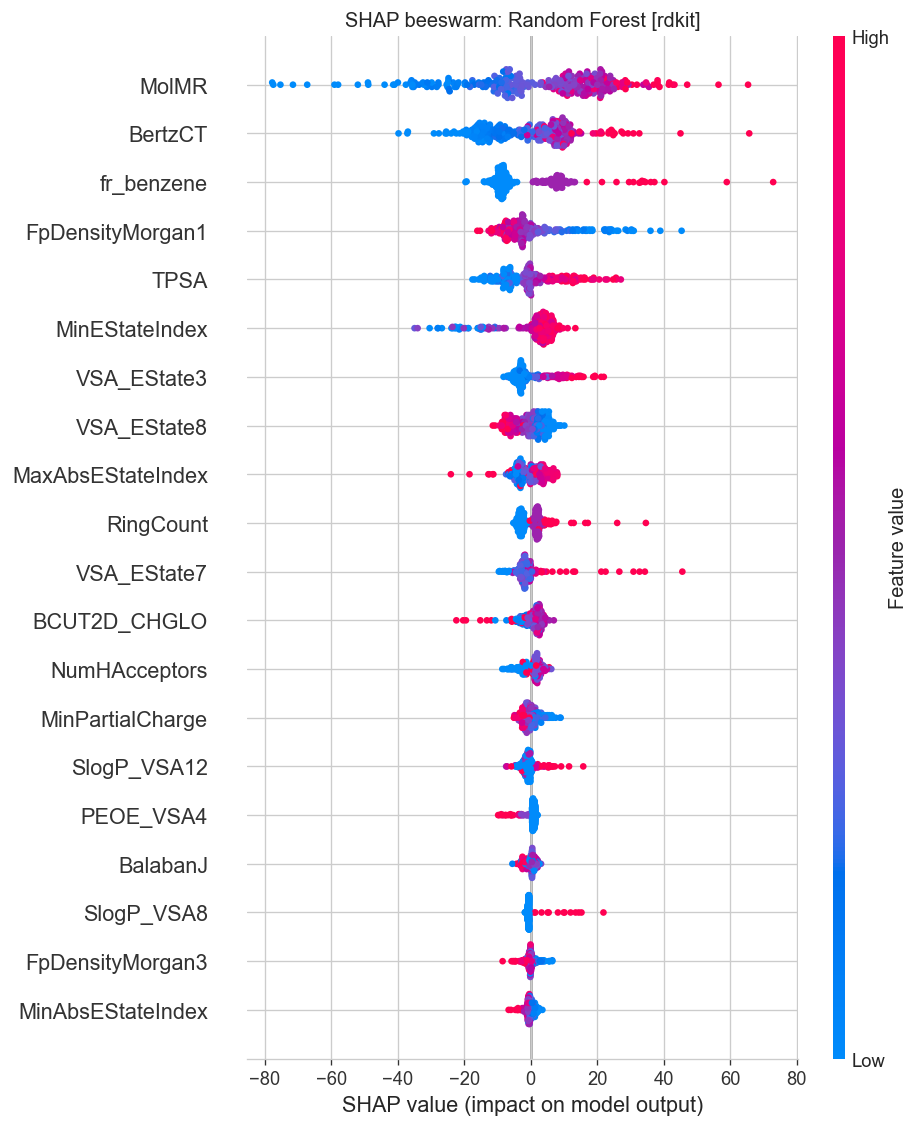

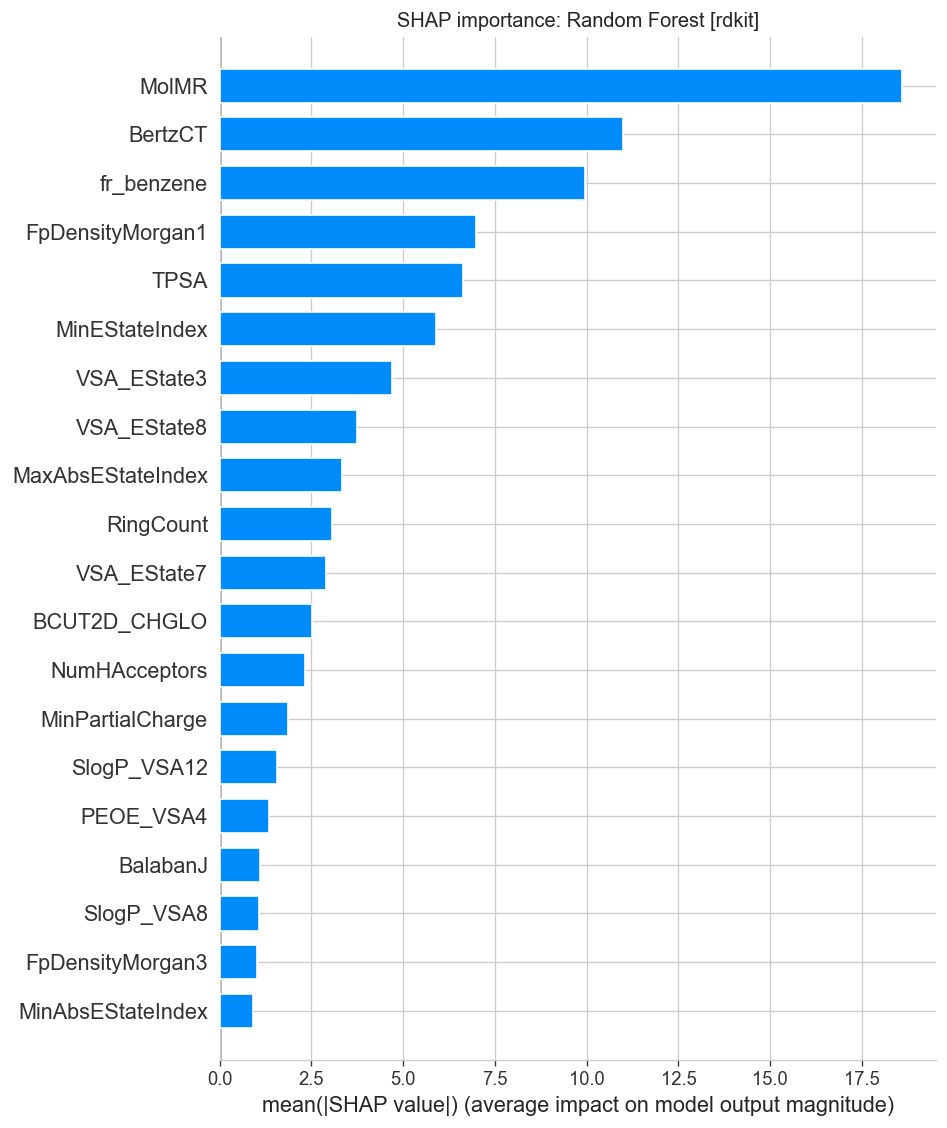

  ✓ shap_beeswarm_random_forest_rdkit.png,  shap_bar_random_forest_rdkit.png

SHAP: LightGBM [combined]  R²_test=0.6923
  SHAP из кэша: shap_lightgbm_combined.pkl
  SHAP shapes: sv=(300, 25), Xp=(300, 25), fnames=25


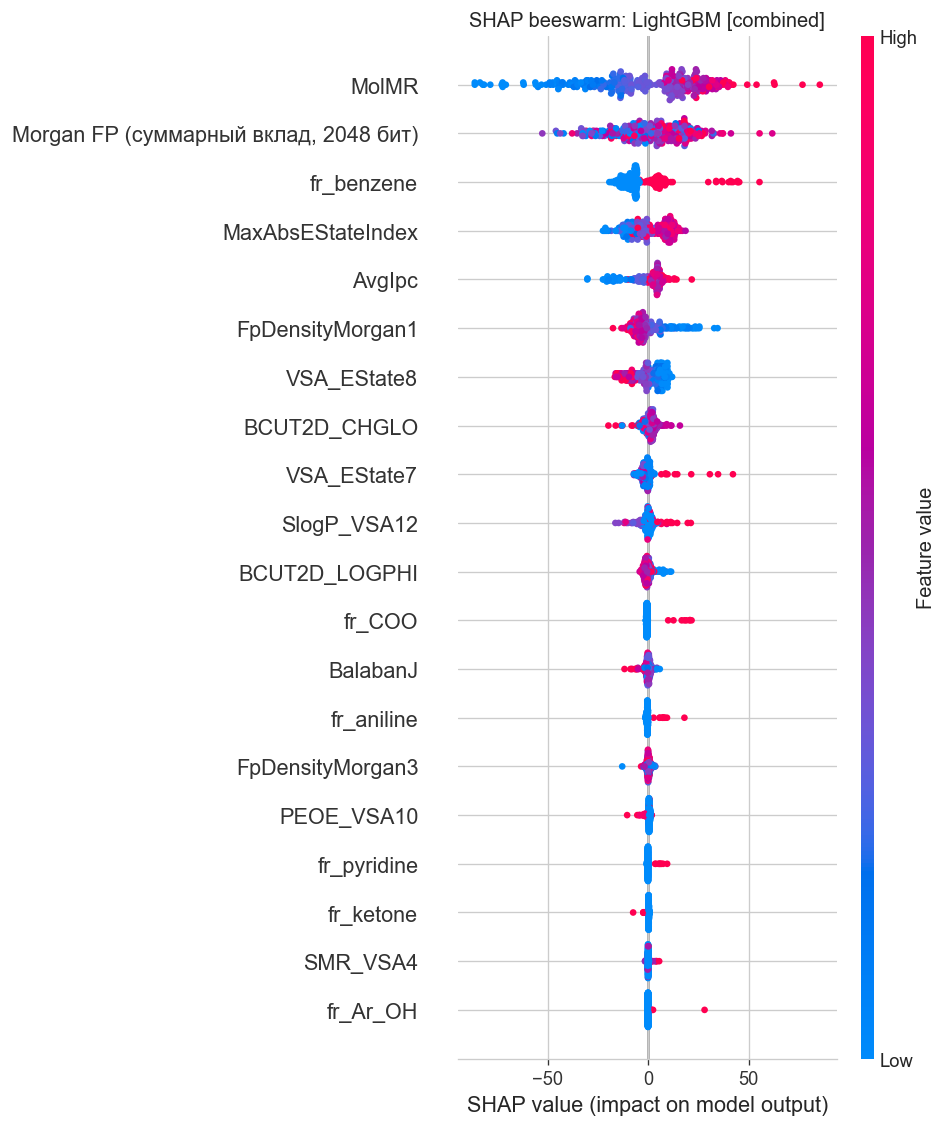

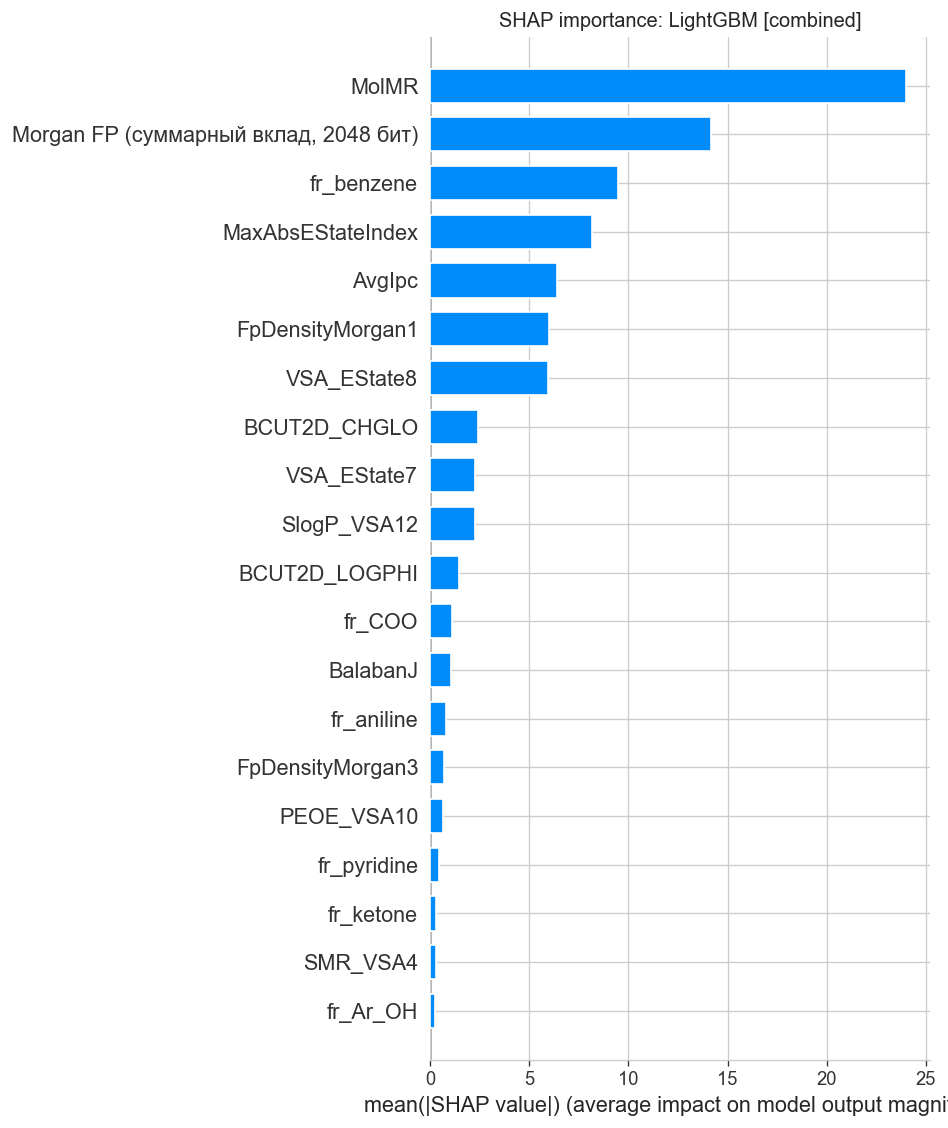

  ✓ shap_beeswarm_lightgbm_combined.png,  shap_bar_lightgbm_combined.png

SHAP: XGBoost [rdkit]  R²_test=0.6953
  SHAP из кэша: shap_xgboost_rdkit.pkl
  SHAP shapes: sv=(300, 31), Xp=(300, 31), fnames=31


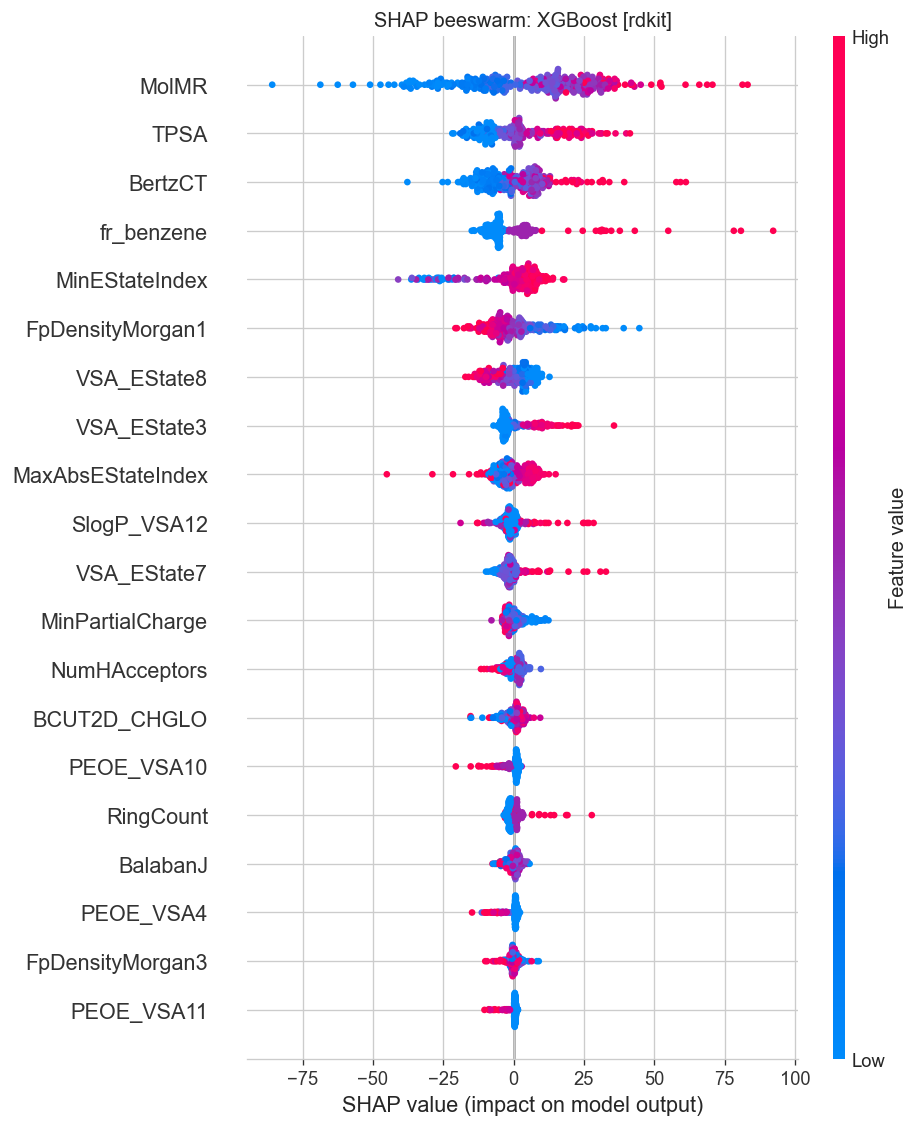

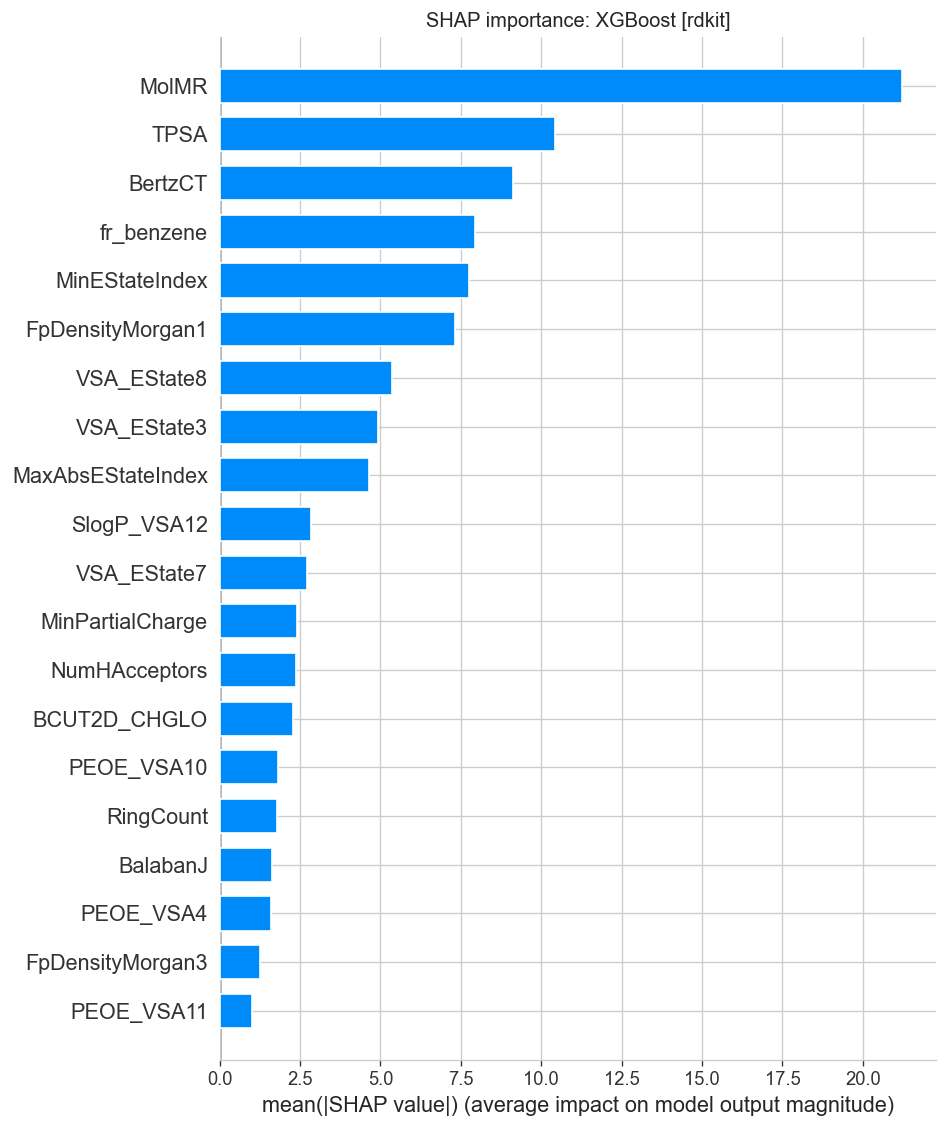

  ✓ shap_beeswarm_xgboost_rdkit.png,  shap_bar_xgboost_rdkit.png

SHAP: CatBoost [rdkit]  R²_test=0.7010
  SHAP из кэша: shap_catboost_rdkit.pkl
  SHAP shapes: sv=(300, 31), Xp=(300, 31), fnames=31


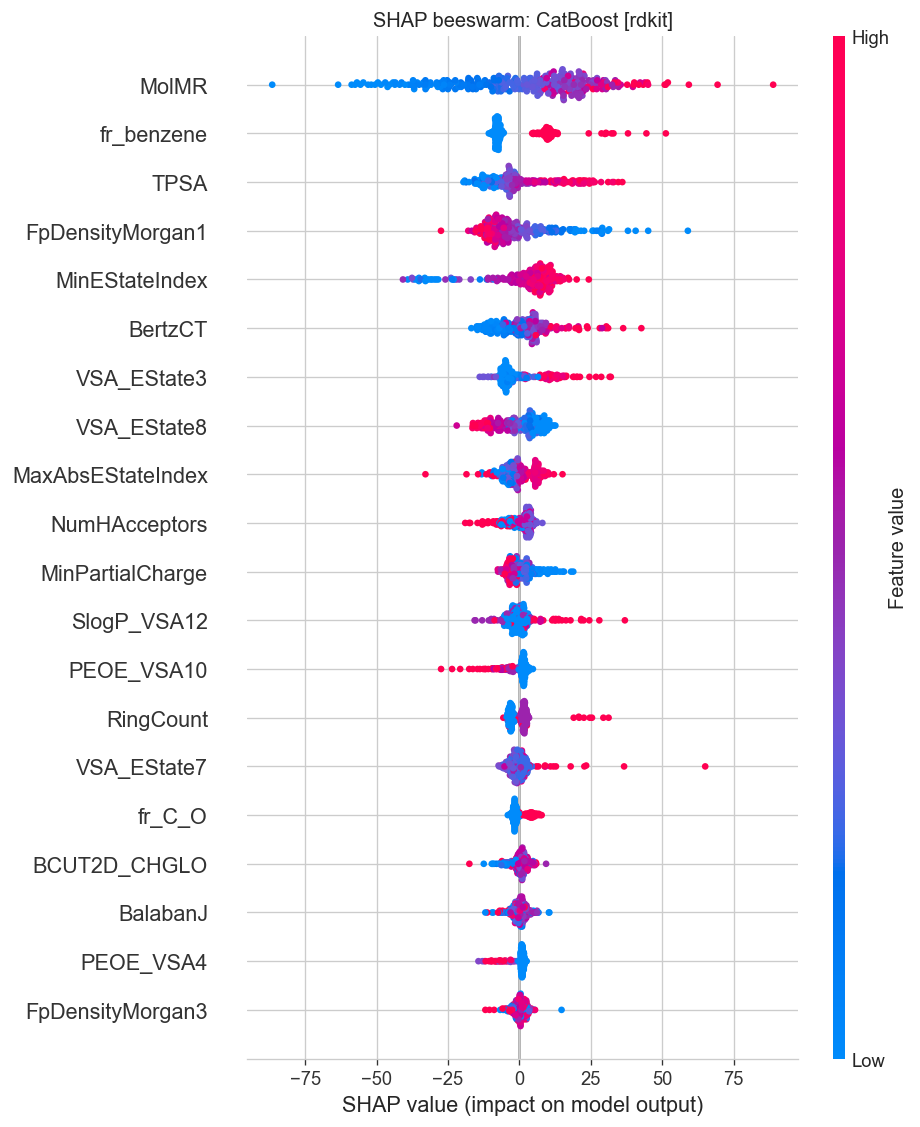

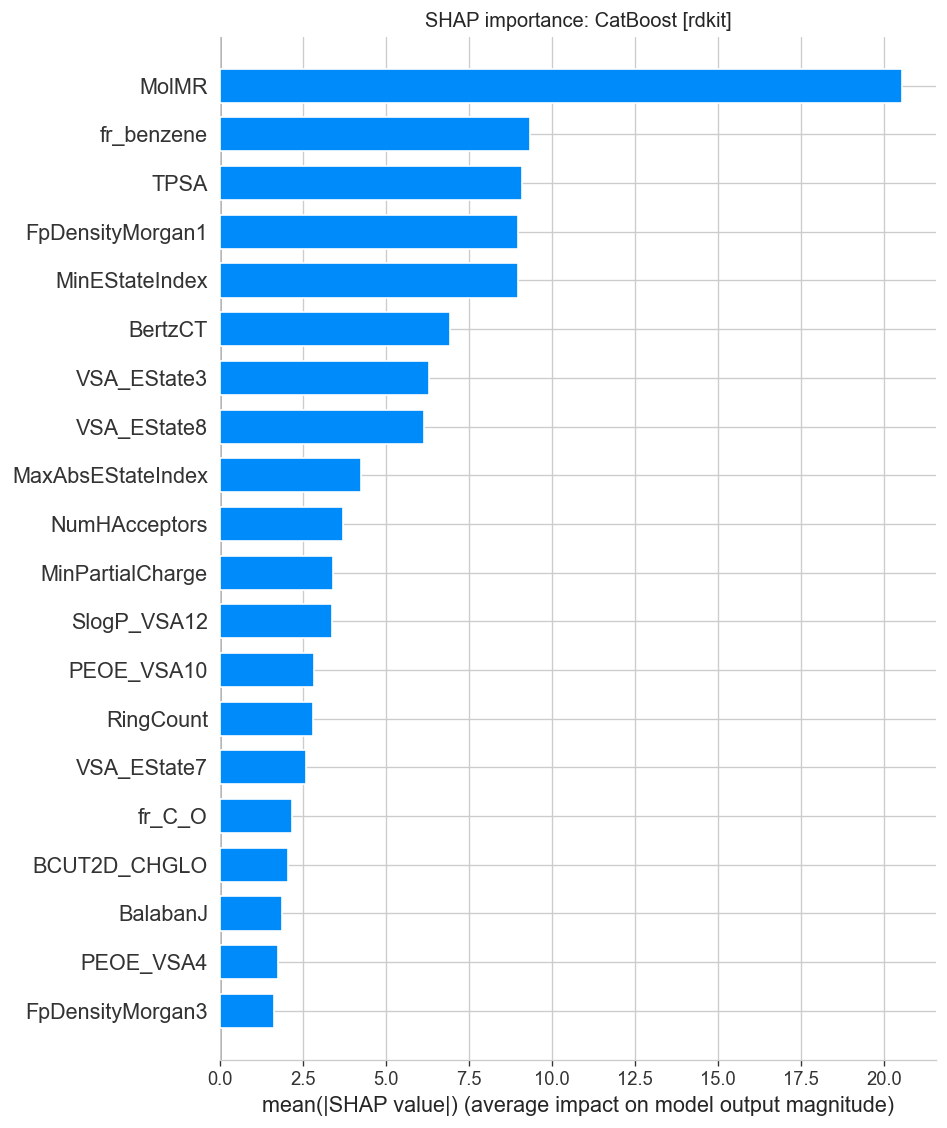

  ✓ shap_beeswarm_catboost_rdkit.png,  shap_bar_catboost_rdkit.png

SHAP: KNN [rdkit]  R²_test=0.6386
  SHAP из кэша: shap_knn_rdkit.pkl
  SHAP shapes: sv=(100, 31), Xp=(100, 31), fnames=31


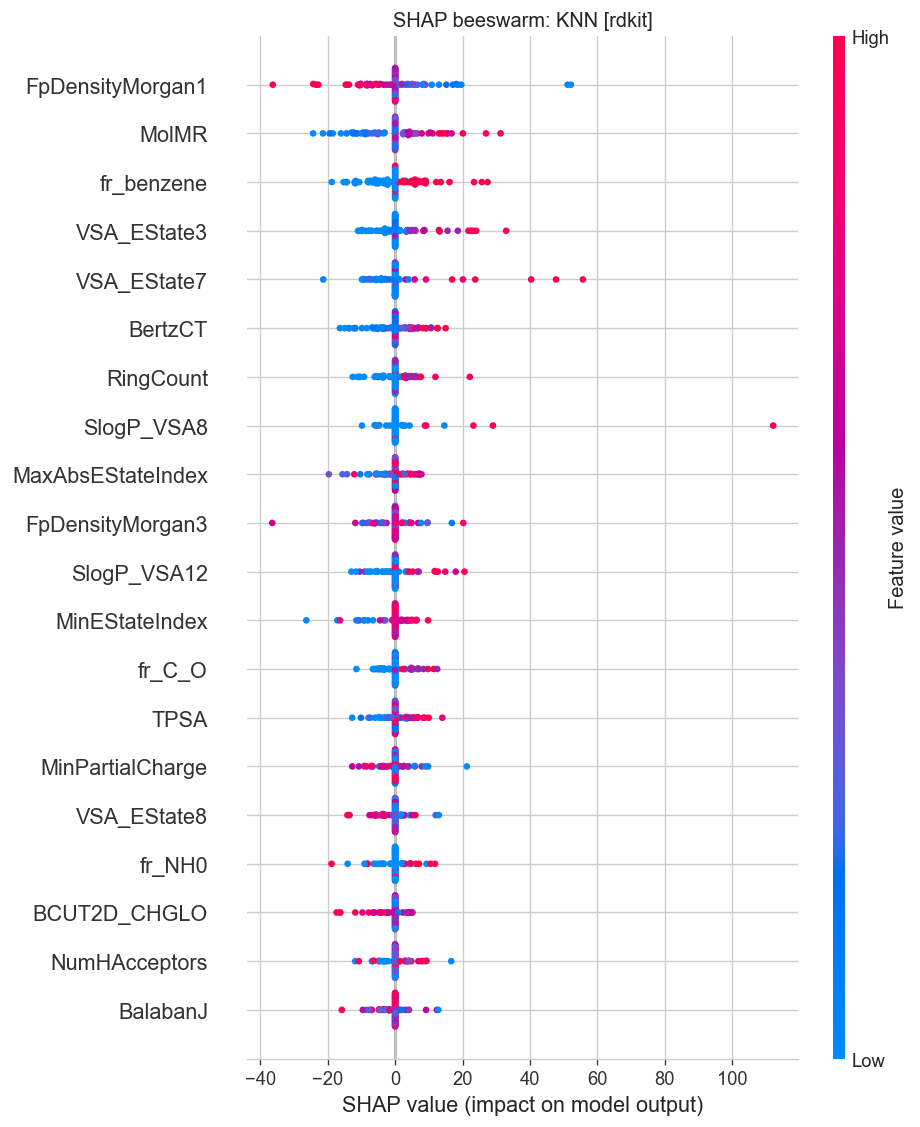

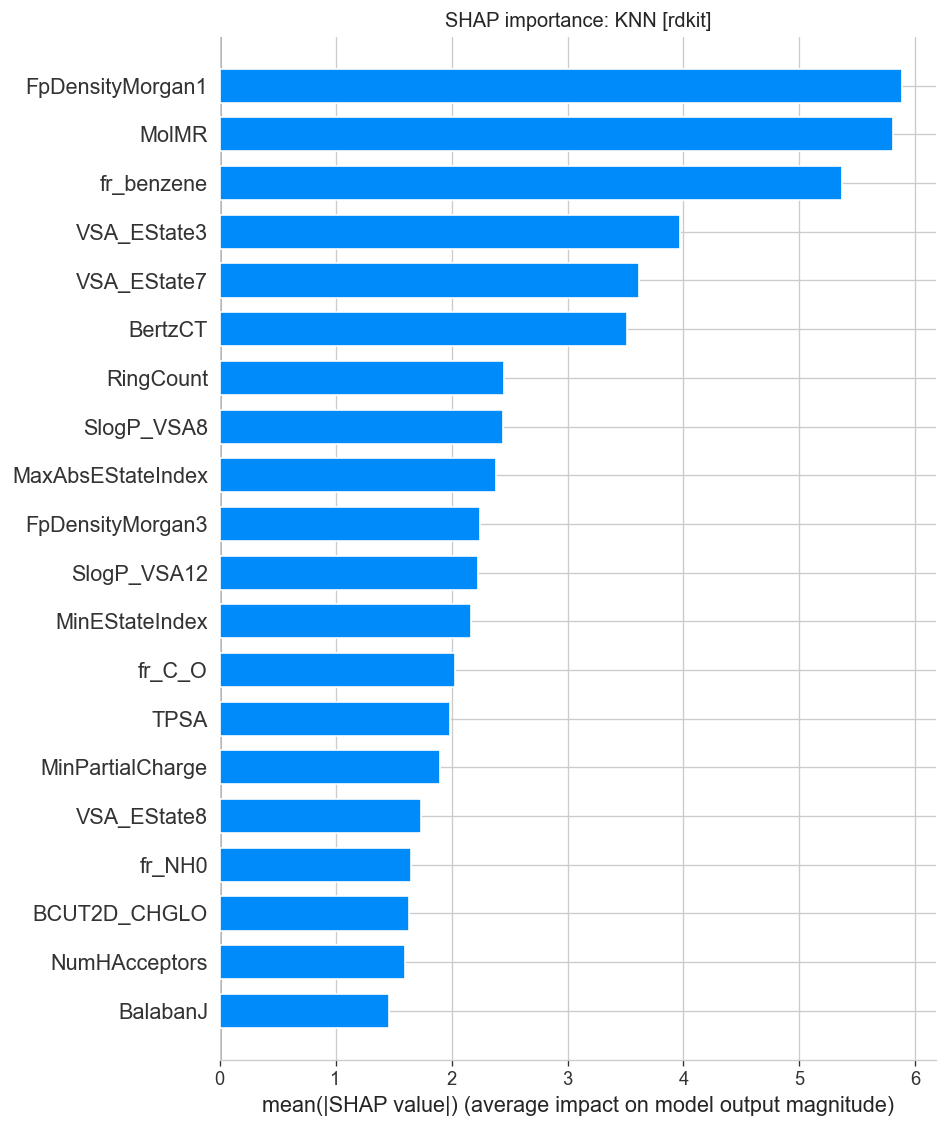

  ✓ shap_beeswarm_knn_rdkit.png,  shap_bar_knn_rdkit.png

SHAP: SVR [rdkit]  R²_test=0.6566
  SHAP из кэша: shap_svr_rdkit.pkl
  SHAP shapes: sv=(100, 31), Xp=(100, 31), fnames=31


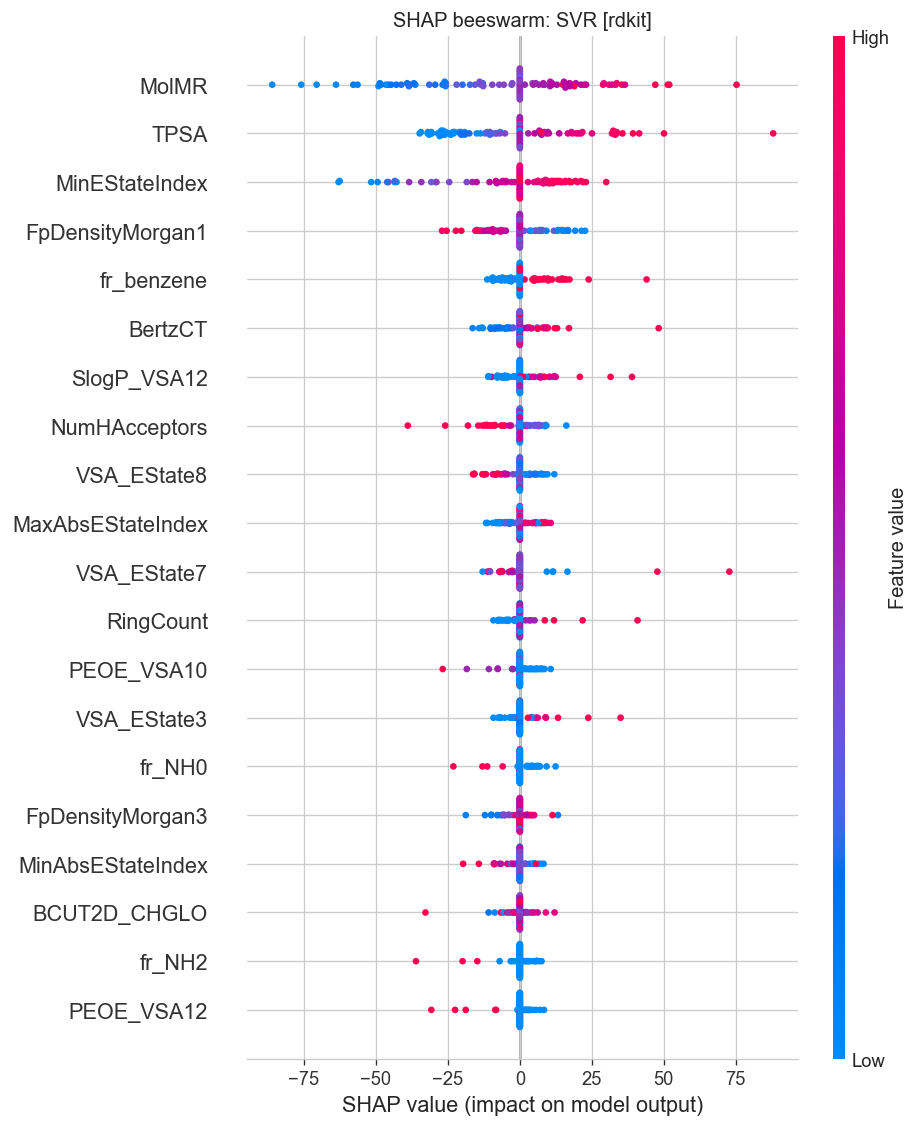

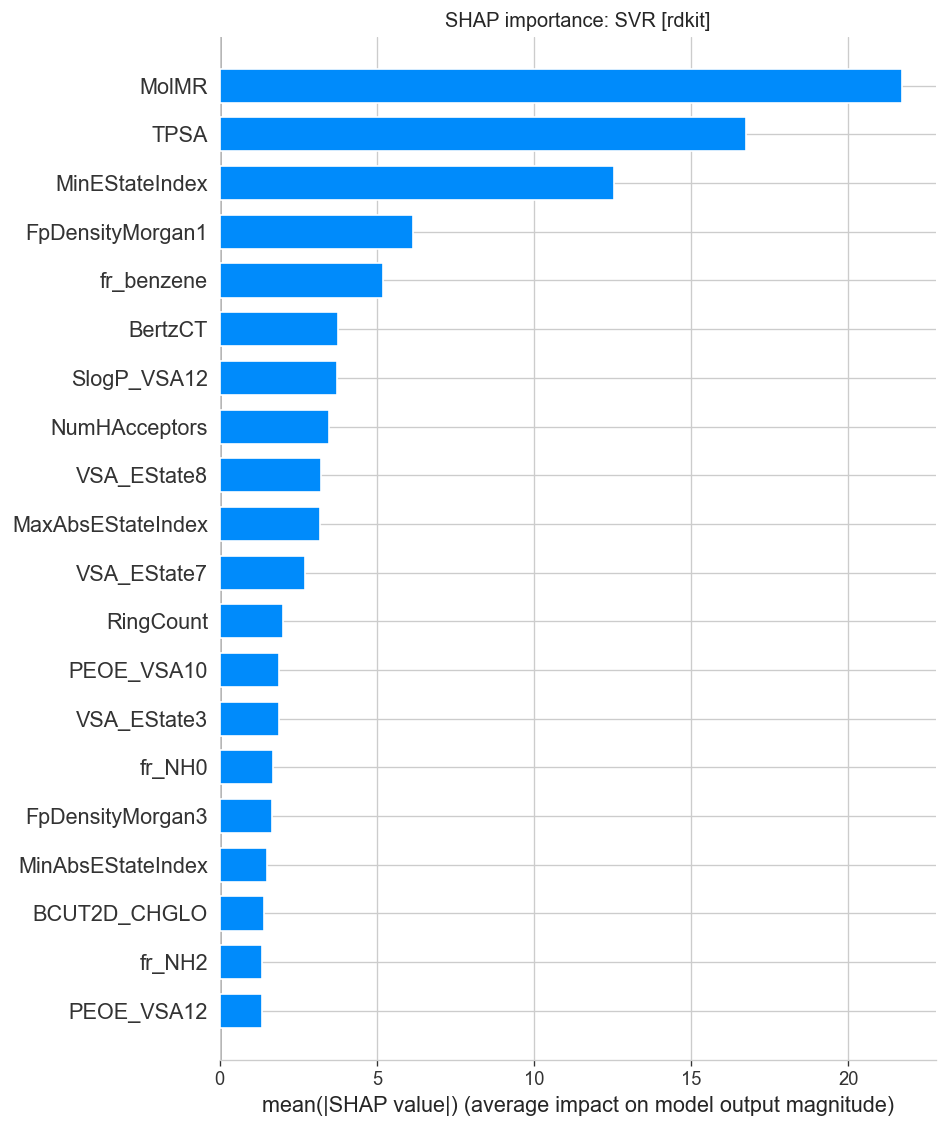

  ✓ shap_beeswarm_svr_rdkit.png,  shap_bar_svr_rdkit.png

SHAP: MLP [combined]  R²_test=0.5555
  SHAP из кэша: shap_mlp_combined.pkl
  SHAP shapes: sv=(50, 25), Xp=(300, 25), fnames=25
  WARN: row mismatch → trimmed to 50 rows


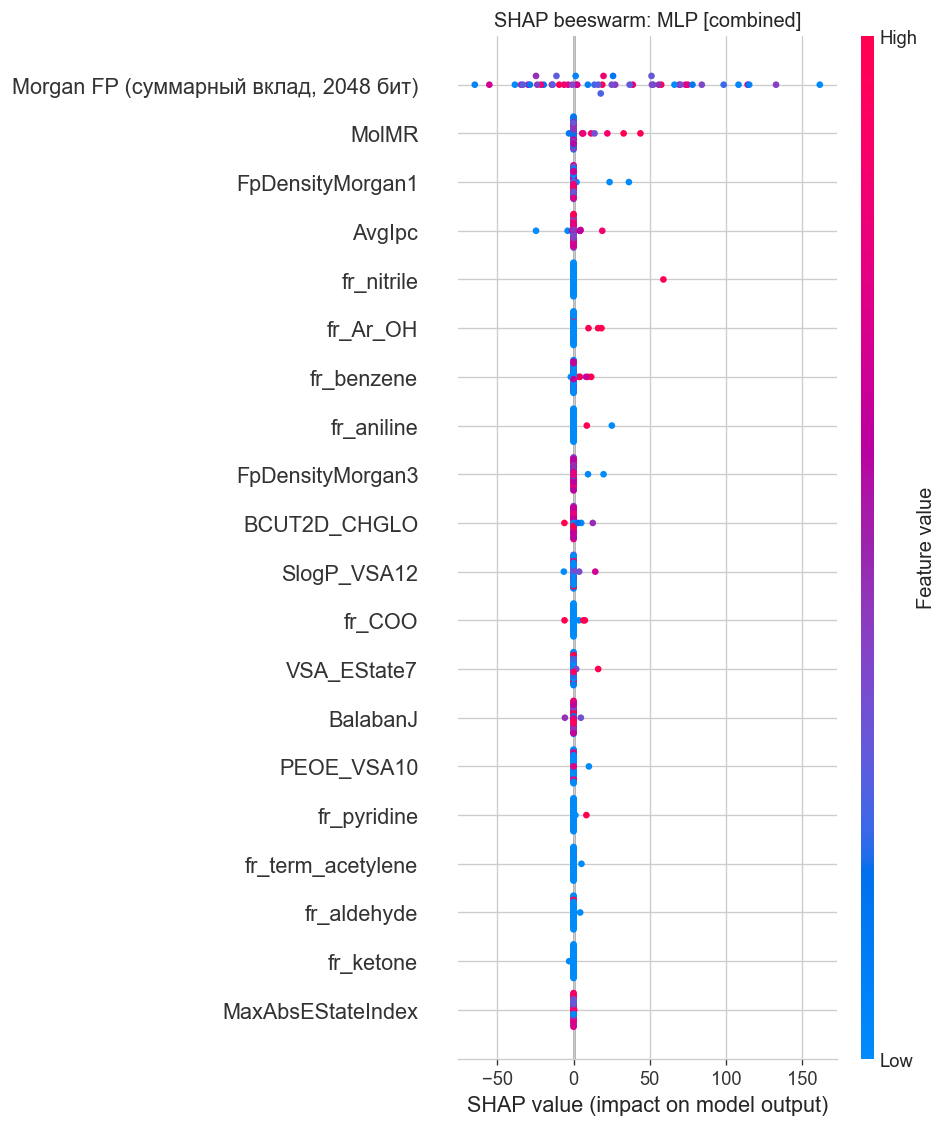

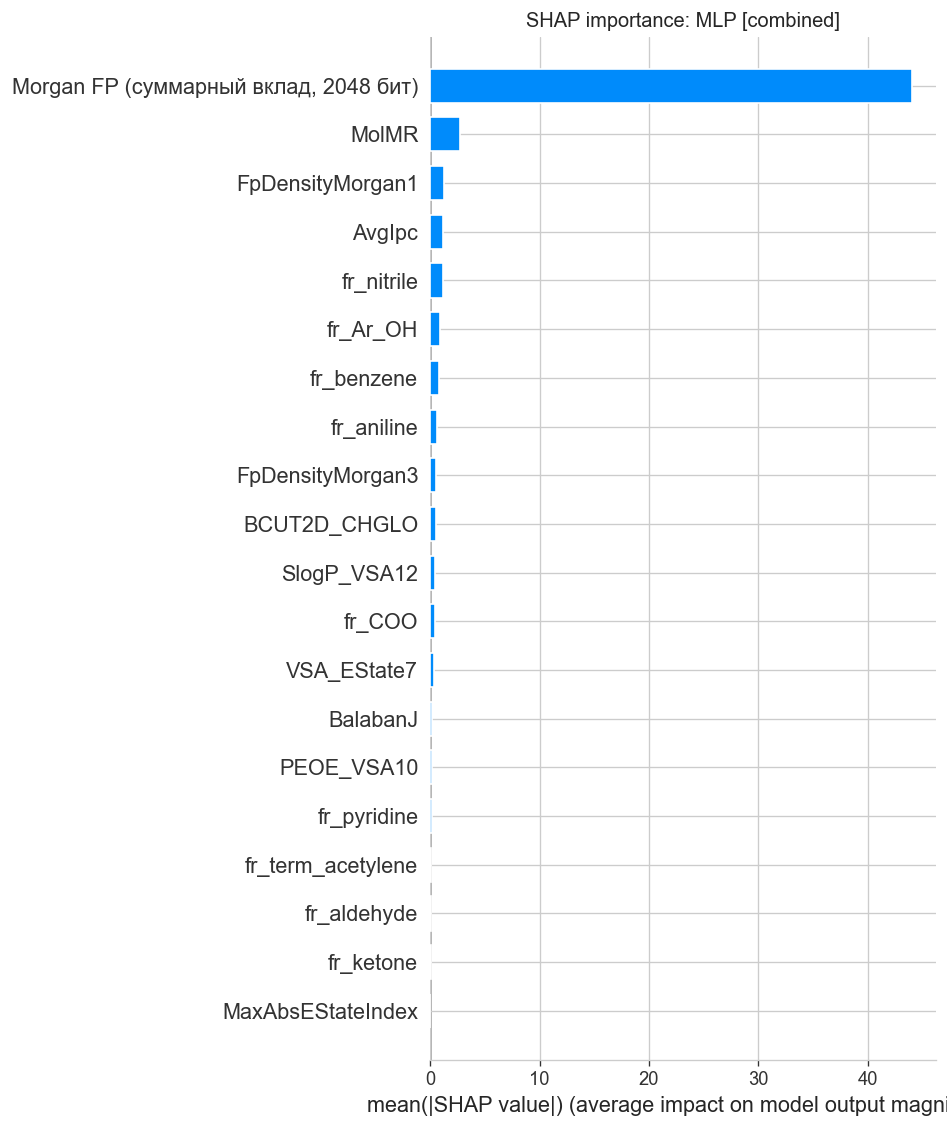

  ✓ shap_beeswarm_mlp_combined.png,  shap_bar_mlp_combined.png

SHAP: топ-5 признаков по моделям
  CatBoost           [rdkit]  R²=0.7010
    1. MolMR
    2. fr_benzene
    3. TPSA
    4. FpDensityMorgan1
    5. MinEStateIndex
  XGBoost            [rdkit]  R²=0.6953
    1. MolMR
    2. TPSA
    3. BertzCT
    4. fr_benzene
    5. MinEStateIndex
  LightGBM           [combined]  R²=0.6923
    1. MolMR
    2. Morgan FP (суммарный вклад, 2048 бит)
    3. fr_benzene
    4. MaxAbsEStateIndex
    5. AvgIpc
  Random Forest      [rdkit]  R²=0.6845
    1. MolMR
    2. BertzCT
    3. fr_benzene
    4. FpDensityMorgan1
    5. TPSA
  SVR                [rdkit]  R²=0.6566
    1. MolMR
    2. TPSA
    3. MinEStateIndex
    4. FpDensityMorgan1
    5. fr_benzene
  KNN                [rdkit]  R²=0.6386
    1. FpDensityMorgan1
    2. MolMR
    3. fr_benzene
    4. VSA_EState3
    5. VSA_EState7
  Lasso              [combined]  R²=0.6070
    1. Morgan FP (суммарный вклад, 2048 бит)
    2. fr_benzene
    3.

In [237]:
# ═══════════════════════════════════════════════════════════════════════════
# SHAP-анализ для ВСЕХ лучших моделей (10 штук)
#
# Метод по типу модели:
#   TreeExplainer  : Random Forest, LightGBM, XGBoost, CatBoost  → секунды
#   LinearExplainer: Ridge, Lasso, BayesianRidge                 → секунды
#   DeepExplainer  : MLP (PyTorch)                               → 1-2 мин
#   KernelExplainer: KNN, SVR                                    → 5-30 мин
#
# SKIP_KERNEL_SHAP = True → пропустить KNN и SVR SHAP
# Все результаты кэшируются в models/shap_cache/
# ═══════════════════════════════════════════════════════════════════════════
SKIP_KERNEL_SHAP = False   # ← True чтобы пропустить KNN и SVR

_TREE_MODELS   = {'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost'}
_LINEAR_MODELS = {'Ridge', 'Lasso', 'BayesianRidge'}
_KERNEL_MODELS = {'KNN', 'SVR'}

_all_model_dicts_shap = {
    'Ridge':         best_ridge,
    'Lasso':         best_lasso,
    'BayesianRidge': best_br,
    'Random Forest': best_rf,
    'LightGBM':      best_lgb,
    'XGBoost':       best_xgb,
    'CatBoost':      best_cb,
    'KNN':           best_knn,
    'SVR':           best_svr,
}
_feat_map_shap = {
    'morgan':   morgan_cols,
    'rdkit':    rdkit_cols,
    'combined': combined_cols,
}

_rng_shap = np.random.RandomState(RANDOM_STATE + 77)
N_BG_SHAP   = 100   # фоновых точек
N_EXPL_SHAP = 300   # тест. точек (100 для KernelExplainer)

_shap_summary = []   # для итогового сводного графика

for mn, fs in model_families.items():
    _r2_str = f'{results.get(f"{mn} [{fs}]", {}).get("R2_test", 0):.4f}'
    print(f'\n{"="*60}')
    print(f'SHAP: {mn} [{fs}]  R²_test={_r2_str}')

    if SKIP_KERNEL_SHAP and mn in _KERNEL_MODELS:
        print(f'  Пропущен (SKIP_KERNEL_SHAP=True)')
        continue

    _sfx     = mn.lower().replace(' ', '_')
    _cache_f = SHAP_CACHE_DIR / f'shap_{_sfx}_{fs}.pkl'

    # ── Кэш ──────────────────────────────────────────────────────────────────
    # Валидация кэша: должен быть dict с ключами sv/X_plot/feat_names
    if _cache_f.exists():
        _cdata_chk = pickle.load(open(_cache_f, 'rb'))
        if not (isinstance(_cdata_chk, dict) and 'sv' in _cdata_chk):
            print(f'  Кэш устарел (старый формат) → удаляем, пересчитываем')
            _cache_f.unlink()
    if _cache_f.exists():
        _cdata = pickle.load(open(_cache_f, 'rb'))
        _sv, _Xp, _fnames = _cdata['sv'], _cdata['X_plot'], _cdata['feat_names']
        print(f'  SHAP из кэша: {_cache_f.name}')
    else:
        # ── Подготовка данных ─────────────────────────────────────────────────
        if mn == 'MLP':
            _X_tr_raw = X_train_mlp
            _X_te_raw = X_test_mlp
            _fnames   = combined_cols
        else:
            _X_tr_raw, _X_te_raw = feature_sets[fs]
            _fnames = _feat_map_shap[fs]
            # Применяем scaler только если модель — Pipeline со step 'scaler'
            # Tree-модели и KNN/SVR хранятся как голые estimators без скейлинга
            _model_obj_tmp = _all_model_dicts_shap[mn][fs]
            if hasattr(_model_obj_tmp, 'named_steps') and 'scaler' in _model_obj_tmp.named_steps:
                _scaler_p = _model_obj_tmp.named_steps['scaler']
                _X_tr_raw = _scaler_p.transform(_X_tr_raw)
                _X_te_raw = _scaler_p.transform(_X_te_raw)
            # else: tree/KNN/SVR — используем сырые признаки напрямую

        _n_expl = 100 if mn in _KERNEL_MODELS else N_EXPL_SHAP
        _idx_bg   = _rng_shap.choice(len(_X_tr_raw),
                                      min(N_BG_SHAP, len(_X_tr_raw)), replace=False)
        _idx_expl = _rng_shap.choice(len(_X_te_raw),
                                      min(_n_expl, len(_X_te_raw)), replace=False)
        _Xbg   = _X_tr_raw[_idx_bg]
        _Xexpl = _X_te_raw[_idx_expl]

        # ── Explainer ─────────────────────────────────────────────────────────
        if mn in _TREE_MODELS:
            _model_obj = _all_model_dicts_shap[mn][fs]
            _inner = _model_obj.named_steps['model'] if hasattr(_model_obj, 'named_steps') else _model_obj
            _expl  = shap.TreeExplainer(_inner)
            _sv    = _expl.shap_values(_Xexpl)
            if isinstance(_sv, list): _sv = _sv[0]
            if hasattr(_sv, 'values'): _sv = _sv.values
            _sv = np.asarray(_sv, dtype=float)

        elif mn in _LINEAR_MODELS:
            _model_obj = _all_model_dicts_shap[mn][fs]
            _inner = _model_obj.named_steps['model'] if hasattr(_model_obj, 'named_steps') else _model_obj
            _expl  = shap.LinearExplainer(_inner, _Xbg)
            _sv    = _expl.shap_values(_Xexpl)
            if isinstance(_sv, list): _sv = _sv[0]
            if hasattr(_sv, 'values'): _sv = _sv.values
            _sv = np.asarray(_sv, dtype=float)

        elif mn == 'MLP':
            # Проверяем доступность model_mlp
            try:
                _test_mn = model_mlp
                _test_np = mlp_predict_np
            except NameError as _ne:
                print(f'  WARN: {_ne}')
                print('  Для SHAP MLP запустите ячейки 28-34, затем повторите.')
                continue
            _mlp_shap_ok = False
            try:
                _Xbg_t   = torch.FloatTensor(_Xbg).to(DEVICE)
                _Xexpl_t = torch.FloatTensor(_Xexpl).to(DEVICE)
                _expl    = shap.DeepExplainer(model_mlp, _Xbg_t)
                _sv_raw  = _expl.shap_values(_Xexpl_t)
                _sv = _sv_raw[0] if isinstance(_sv_raw, list) else _sv_raw
                if hasattr(_sv, 'cpu'):    _sv = _sv.cpu().numpy()
                elif hasattr(_sv, 'detach'): _sv = _sv.detach().numpy()
                _mlp_shap_ok = True
                print(f'  DeepExplainer OK, shape={_sv.shape}')
            except Exception as _e:
                print(f'  DeepExplainer: {_e}')
                print(f'  → KernelExplainer (50 bg, 50 expl, nsamples=100)...')
            if not _mlp_shap_ok:
                _Xexpl = _Xexpl[:50]  # ← обновляем чтобы _Xp совпал
                _expl = shap.KernelExplainer(mlp_predict_np, _Xbg[:50])
                _sv   = _expl.shap_values(_Xexpl, nsamples=100)

        else:  # KNN, SVR
            _model_obj = _all_model_dicts_shap[mn][fs]
            _inner = _model_obj.named_steps['model'] if hasattr(_model_obj, 'named_steps') else _model_obj
            print(f'  KernelExplainer (bg={len(_Xbg)}, expl={len(_Xexpl)}, nsamples=100)...')
            _expl = shap.KernelExplainer(_inner.predict, _Xbg)
            _sv   = _expl.shap_values(_Xexpl, nsamples=100)
            if isinstance(_sv, list): _sv = _sv[0]
            if hasattr(_sv, 'values'): _sv = _sv.values
            _sv = np.asarray(_sv, dtype=float)

        _Xp = _Xexpl
        pickle.dump({'sv': _sv, 'X_plot': _Xp, 'feat_names': _fnames},
                    open(_cache_f, 'wb'), protocol=4)
        print(f'  SHAP сохранён: {_cache_f.name}')

    # ── Агрегируем Morgan FP биты → один признак (2048 → 1) ────────────────
    # Morgan_0…Morgan_2047 заменяются на «Morgan FP (суммарный вклад, 2048 бит)»
    def _agg_morgan_sv(sv, Xp, fnames):
        # Гарантируем plain numpy array (SHAP может вернуть Explanation object)
        sv  = np.asarray(sv.values  if hasattr(sv,  'values') else sv,  dtype=float)
        Xp  = np.asarray(Xp.values  if hasattr(Xp,  'values') else Xp,  dtype=float)
        _is_mg = np.array(['Morgan_' in fn for fn in fnames], dtype=bool)
        _n_mg  = int(_is_mg.sum())
        if _n_mg < 100:          # rdkit (31 признак) — агрегация не нужна
            return sv, Xp, list(fnames)
        _mg_sv = sv[:, _is_mg].sum(axis=1, keepdims=True)   # суммарный вклад
        _mg_Xp = Xp[:, _is_mg].mean(axis=1, keepdims=True)  # среднее для цвета
        _rd_sv = sv[:, ~_is_mg]
        _rd_Xp = Xp[:, ~_is_mg]
        _rd_fn = [fn for fn, m in zip(fnames, _is_mg) if not m]
        _sv_o  = np.hstack([_mg_sv, _rd_sv]) if len(_rd_fn) else _mg_sv
        _Xp_o  = np.hstack([_mg_Xp, _rd_Xp]) if len(_rd_fn) else _mg_Xp
        _fn_o  = [f'Morgan FP (суммарный вклад, {_n_mg} бит)'] + _rd_fn
        return _sv_o.astype(float), _Xp_o.astype(float), _fn_o
    _sv_pl, _Xp_pl, _fn_pl = _agg_morgan_sv(_sv, _Xp, _fnames)

    # ── Графики ───────────────────────────────────────────────────────────────
    _bee = FIGURES_DIR / f'shap_beeswarm_{_sfx}_{fs}.png'
    _bar = FIGURES_DIR / f'shap_bar_{_sfx}_{fs}.png'

    # Диагностика и защита от row-mismatch
    _sv_pl = np.asarray(_sv_pl, dtype=float)
    _Xp_pl = np.asarray(_Xp_pl, dtype=float)
    if _sv_pl.ndim == 1: _sv_pl = _sv_pl.reshape(1, -1)
    if _Xp_pl.ndim == 1: _Xp_pl = _Xp_pl.reshape(1, -1)
    print(f'  SHAP shapes: sv={_sv_pl.shape}, Xp={_Xp_pl.shape}, fnames={len(_fn_pl)}')
    if _sv_pl.shape[0] != _Xp_pl.shape[0]:
        _r = min(_sv_pl.shape[0], _Xp_pl.shape[0])
        _sv_pl, _Xp_pl = _sv_pl[:_r], _Xp_pl[:_r]
        print(f'  WARN: row mismatch → trimmed to {_r} rows')
    # Beeswarm
    shap.summary_plot(_sv_pl, _Xp_pl, feature_names=_fn_pl,
                      max_display=20, show=False)
    plt.title(f'SHAP beeswarm: {mn} [{fs}]', fontsize=12)
    plt.tight_layout()
    plt.savefig(_bee, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

    # Bar importance
    shap.summary_plot(_sv_pl, _Xp_pl, feature_names=_fn_pl,
                      max_display=20, plot_type='bar', show=False)
    plt.title(f'SHAP importance: {mn} [{fs}]', fontsize=12)
    plt.tight_layout()
    plt.savefig(_bar, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f'  ✓ {_bee.name},  {_bar.name}')

    # Топ-5 признаков для сводки (по агрегированным данным)
    _mean_abs = np.abs(_sv_pl).mean(axis=0)
    _top5_idx = np.argsort(_mean_abs)[::-1][:5]
    _top5_f   = [_fn_pl[_i] if _i < len(_fn_pl) else f'feat_{_i}'
                 for _i in _top5_idx]
    _shap_summary.append({'model': mn, 'fs': fs,
                          'top5': _top5_f,
                          'r2': results.get(f'{mn} [{fs}]', {}).get('R2_test', 0)})

# ── Сводная таблица топ признаков ────────────────────────────────────────────
print('\n' + '='*60)
print('SHAP: топ-5 признаков по моделям')
print('='*60)
for _row in sorted(_shap_summary, key=lambda x: -x['r2']):
    print(f'  {_row["model"]:<18} [{_row["fs"]}]  R²={_row["r2"]:.4f}')
    for _j, _f in enumerate(_row["top5"], 1):
        print(f'    {_j}. {_f}')

print('\n=== SHAP-анализ завершён для всех моделей ===')


## 16. Выводы

### Качество моделей

Диапазон температур кипения: ~752 °C (от −161.5 до 590.5 °C). Тестовая выборка: 1715 молекул.
Тестовый RMSE варьируется от 44.7 °C (CatBoost) до 54.5 °C (MLP), что соответствует 6–7% от диапазона значений.
Сводная таблица сохранена в `../data_ml/model_results.csv`.

#### Фактическая иерархия методов (по R²_test на лучшем наборе признаков)

| Место | Метод | Набор | R²_test | RMSE (°C) | Обоснование |
|---|---|---|---|---|---|
| 1 | CatBoost | rdkit | 0.701 | 44.7 | Ordered boosting + симметричные деревья; наилучший результат |
| 2 | XGBoost | rdkit | 0.695 | 45.1 | Level-wise бустинг; уступает CatBoost незначительно |
| 3 | LightGBM | combined | 0.692 | 45.4 | Leaf-wise + GOSS; единственный из бустинга, выигравший от X_combined |
| 4 | Random Forest | rdkit | 0.685 | 45.9 | Ансамбль деревьев; выше дисперсия, чем у бустинга |
| 5 | SVR | rdkit | 0.657 | 47.9 | RBF-ядро хорошо работает на непрерывных дескрипторах |
| 6 | KNN | rdkit | 0.639 | 49.2 | Переобучение (R²_train=1.0); тестовый результат выше линейных моделей |
| 7 | Lasso | combined | 0.607 | 51.3 | L1 эффективно обнулил нерелевантные FP-биты |
| 8 | BayesianRidge | rdkit | 0.591 | 52.3 | Линейная байесовская; результат совпадает с Ridge |
| 9 | Ridge | rdkit | 0.591 | 52.3 | Линейная L2; не улавливает нелинейные взаимодействия |
| 10 | MLP | combined | 0.556 | 54.5 | 3 скрытых слоя (Optuna); не превзошёл бустинг на данном объёме |

### Влияние набора признаков

| Класс моделей | Лучший набор | Причина |
|---|---|---|
| Ridge, BayesianRidge | **X_rdkit** | 31 непрерывный дескриптор даёт линейный сигнал; 2048 бинарных FP добавляют шум |
| Lasso | **X_combined** | L1-регуляризация обнуляет нерелевантные FP-биты; Morgan FP суммарно вносит вклад |
| RF, XGBoost, CatBoost | **X_rdkit** | Добавление 2048 FP не улучшило тестовый R² для этих моделей |
| LightGBM | **X_combined** | Leaf-wise рост + GOSS позволил эффективно отобрать информативные FP-биты |
| KNN, SVR | **X_rdkit** | Евклидово и RBF-расстояние теряет физический смысл в разреженном 2048-мерном пространстве |
| MLP | **X_combined** | Единственный набор признаков (MLP обучался только на X_combined) |

X_morgan — Ни одна из 10 моделей не показала лучший результат на X_morgan

### Область применимости (Williams plot)

- Молекулы вне AD по **leverage** (h > h*) — структурно нетипичны для обучающей выборки.
- Молекулы вне AD по **остаткам** (|res| > 3σ) — модель систематически ошибается на них.
- Доля молекул в AD: 92.5% (SVR) — 97.8% (LightGBM). Модели на X_combined имеют меньше leverage-выбросов (8–47) по сравнению с X_rdkit (83–85), поскольку PCA(50) сжимает пространство и смещает h* вверх.
- h* = 3(p+1)/n_train; для высокоразмерных наборов (Morgan FP: p=2048) применяется PCA(50 компонент).

### Химическая интерпретация (SHAP)
SHAP-значения позволяют связать математические признаки с физической химией
межмолекулярных взаимодействий, определяющих температуру кипения.

#### Теоретическая основа

$$T_{\text{кип}} \sim \Delta H_{\text{vap}} =
\Delta H_{\text{дисп}} + \Delta H_{\text{диполь}} +
\Delta H_{\text{H-связь}} + \Delta H_{\pi\text{-стэк}}$$

| Признак | Тип взаимодействия | Влияние на T кип |
|---|---|---|
| `MolMR` | Дисперсия (Лондон) | ↑ поляризуемость → ↑ T кип |
| `TPSA`, `PEOE_VSA*` | Дипол-дипол | ↑ полярность → ↑ T кип |
| `fr_benzene`, `RingCount` | π–π стэкинг | ↑ ароматичность → ↑ T кип |
| `NumHAcceptors`, `fr_NH2`, `fr_NH0` | Водородные связи | ↑ H-связи → ↑ T кип |
| `BalabanJ`, `FpDensityMorgan*` | Ветвление / топология | ↑ ветвление → ↓ T кип |

`MolMR` — ведущий признак в 9 из 10 моделей (в KNN первое место занимает `FpDensityMorgan1`).
Согласие SHAP-важностей между LinearExplainer (Ridge/Lasso) и TreeExplainer (бустинг)
подтверждает физическую обоснованность: если обе группы выделяют одни и те же дескрипторы,
это не артефакт конкретной модели.

SHAP-анализ подтверждает физико-химическое обоснование:

1. **Дисперсионные взаимодействия** (Лондон): `MolMR`, `BertzCT` — крупные и сложные
   молекулы поляризуемее → сильнее удерживаются в жидкой фазе → Tкип выше.
   Согласуется с правилом Трутона ($\Delta H_{vap}/T_{bp} \approx$ const).

2. **Дипол-дипол и H-связи**: `TPSA`, `PEOE_VSA*`, `NumHAcceptors` — полярные молекулы
   и молекулы с донорами/акцепторами H-связи имеют повышенную Tкип.

3. **π-π стэкинг**: `fr_benzene`, `RingCount` — ароматические кольца увеличивают
   энергию когезии жидкости.

4. **Топологическое ветвление**: `BalabanJ` — разветвлённые молекулы хуже упакованы,
   слабее взаимодействуют → Tкип ниже (классический пример: н-пентан 36°C vs неопентан 9°C).

**Следующий шаг:** `gnn.ipynb` — графовые нейронные сети на тех же данных для сравнения
с классическими молекулярными дескрипторами.

## 17. Анализ ошибок модели (CatBoost [rdkit])

**Цель:** выяснить, почему тестовый RMSE составляет ~45 °C (~6 % от диапазона 752 °C),
и выявить классы соединений, для которых модель ошибается систематически.

**Модель:** CatBoost [rdkit] — лучший результат по R² (0.701).  
**Данные:** `merged_nbp_clean.sdf` (порядок строк совпадает с `y.npy`);  
тестовая выборка — 1715 молекул (`random_state=42`, случайное разбиение).  

**Структура раздела:** загрузка данных → гистограммы ошибок → интерактивный scatter → топ-12 худших структур → ошибка по диапазонам T_кип → ошибка по химическим классам → ошибка vs молекулярные свойства → распределение train vs test → выводы.

In [238]:
# ── 17.1: Загрузка SDF, предсказания CatBoost ─────────────────────────────
import pickle, base64, io as _io
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors

def _get_prop(mol, name, default=''):
    try:
        if mol.HasProp(name):
            return mol.GetProp(name)
    except Exception:
        pass
    return default

# Читаем SDF (порядок == порядок y.npy) ──────────────────────────────────────
sdf_path = DATA_DIR / 'merged_nbp_clean.sdf'
suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=True)

rows_sdf = []
for mol in suppl:
    if mol is not None:
        t_str = _get_prop(mol, 'Temperature_Celsius', 'nan')
        try:
            t_val = float(t_str)
        except ValueError:
            t_val = float('nan')
        try:
            n_src = int(_get_prop(mol, 'n_sources', '1'))
        except ValueError:
            n_src = 1
        rows_sdf.append({
            'mol':          mol,
            'SMILES':       _get_prop(mol, 'SMILES') or Chem.MolToSmiles(mol),
            'compound':     _get_prop(mol, 'compound'),
            'T_exp':        t_val,
            'CAS':          _get_prop(mol, 'CAS'),
            'source':       _get_prop(mol, 'source'),
            'n_sources':    n_src,
            'merge_status': _get_prop(mol, 'merge_status'),
        })
    else:
        rows_sdf.append({'mol': None, 'SMILES': '', 'compound': '',
                         'T_exp': float('nan'), 'CAS': '', 'source': '',
                         'n_sources': 0, 'merge_status': ''})

df_all_sdf = pd.DataFrame(rows_sdf)
print(f"SDF прочитан: {len(df_all_sdf)} записей  (None: {df_all_sdf['mol'].isna().sum()})")

valid = ~df_all_sdf['T_exp'].isna()
mismatch = int(np.sum(~np.isclose(df_all_sdf.loc[valid, 'T_exp'].values, y[valid], atol=0.01)))
print(f"Несовпадений T_exp vs y.npy: {mismatch}  (ожидается 0)")

# Загрузка CatBoost ──────────────────────────────────────────────────────────
cb_path = MODELS_DIR / 'catboost_rdkit.pkl'
with open(cb_path, 'rb') as fh:
    cb_model = pickle.load(fh)
print(f"Модель: {type(cb_model).__name__}")

X_rdkit_cb = X_rdkit[test_idx]
y_pred_cb  = cb_model.predict(X_rdkit_cb)

df_test_err = df_all_sdf.iloc[test_idx].copy().reset_index(drop=True)
df_test_err['T_pred']    = y_pred_cb
df_test_err['error']     = df_test_err['T_pred'] - df_test_err['T_exp']
df_test_err['abs_error'] = df_test_err['error'].abs()

_rmse_ea = float(np.sqrt((df_test_err['error']**2).mean()))
_mae_ea  = float(df_test_err['abs_error'].mean())
_bias_ea = float(df_test_err['error'].mean())
_r2_ea   = 1.0 - float((df_test_err['error']**2).sum()) / float(((df_test_err['T_exp'] - df_test_err['T_exp'].mean())**2).sum())

print(f"\nCatBoost [rdkit]  |  n_test={len(df_test_err)}")
print(f"  R\u00b2   = {_r2_ea:.4f}")
print(f"  RMSE = {_rmse_ea:.2f} \u00b0C")
print(f"  MAE  = {_mae_ea:.2f} \u00b0C")
print(f"  Bias = {_bias_ea:+.2f} \u00b0C")
_pct30 = (df_test_err['abs_error'] < 30).mean() * 100
_pct50 = (df_test_err['abs_error'] < 50).mean() * 100
print(f"  |err| < 30 \u00b0C: {_pct30:.1f}%   |err| < 50 \u00b0C: {_pct50:.1f}%")


SDF прочитан: 8572 записей  (None: 0)
Несовпадений T_exp vs y.npy: 0  (ожидается 0)
Модель: CatBoostRegressor

CatBoost [rdkit]  |  n_test=1715
  R²   = 0.7010
  RMSE = 44.72 °C
  MAE  = 27.77 °C
  Bias = +1.08 °C
  |err| < 30 °C: 72.2%   |err| < 50 °C: 82.2%


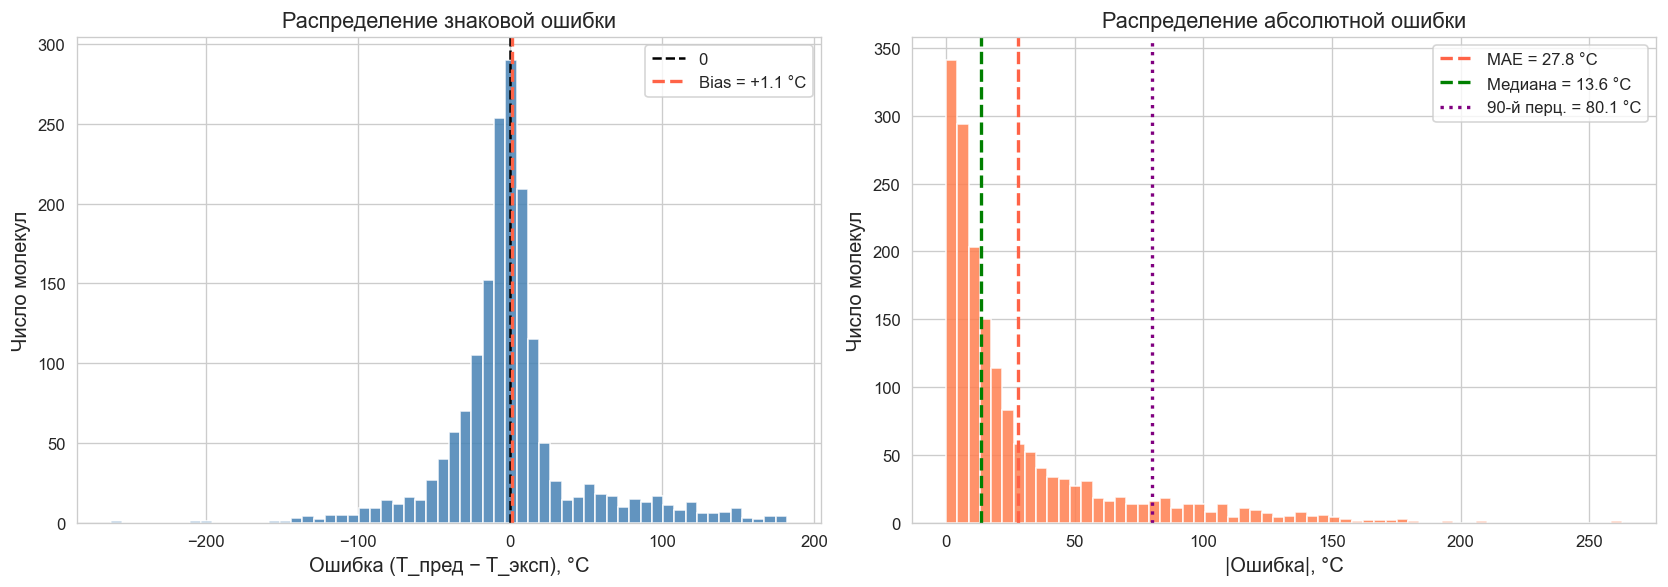

Сохранено: error_distribution.png


In [239]:
# ── 17.2: Гистограммы ошибок ───────────────────────────────────────────────
fig_eh, axes_eh = plt.subplots(1, 2, figsize=(14, 5))

axes_eh[0].hist(df_test_err['error'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes_eh[0].axvline(0, color='black', ls='--', lw=1.5, label='0')
axes_eh[0].axvline(_bias_ea, color='tomato', ls='--', lw=2, label=f'Bias = {_bias_ea:+.1f} \u00b0C')
axes_eh[0].set_xlabel('\u041e\u0448\u0438\u0431\u043a\u0430 (T_\u043f\u0440\u0435\u0434 \u2212 T_\u044d\u043a\u0441\u043f), \u00b0C', fontsize=12)
axes_eh[0].set_ylabel('\u0427\u0438\u0441\u043b\u043e \u043c\u043e\u043b\u0435\u043a\u0443\u043b', fontsize=12)
axes_eh[0].set_title('\u0420\u0430\u0441\u043f\u0440\u0435\u0434\u0435\u043b\u0435\u043d\u0438\u0435 \u0437\u043d\u0430\u043a\u043e\u0432\u043e\u0439 \u043e\u0448\u0438\u0431\u043a\u0438', fontsize=13)
axes_eh[0].legend()

_med_ae = float(df_test_err['abs_error'].median())
_q90_ae = float(df_test_err['abs_error'].quantile(0.90))
axes_eh[1].hist(df_test_err['abs_error'], bins=60, color='coral', edgecolor='white', alpha=0.85)
axes_eh[1].axvline(_mae_ea, color='tomato',  ls='--', lw=2, label=f'MAE = {_mae_ea:.1f} \u00b0C')
axes_eh[1].axvline(_med_ae, color='green',   ls='--', lw=2, label=f'\u041c\u0435\u0434\u0438\u0430\u043d\u0430 = {_med_ae:.1f} \u00b0C')
axes_eh[1].axvline(_q90_ae, color='purple',  ls=':',  lw=2, label=f'90-\u0439 \u043f\u0435\u0440\u0446. = {_q90_ae:.1f} \u00b0C')
axes_eh[1].set_xlabel('|\u041e\u0448\u0438\u0431\u043a\u0430|, \u00b0C', fontsize=12)
axes_eh[1].set_ylabel('\u0427\u0438\u0441\u043b\u043e \u043c\u043e\u043b\u0435\u043a\u0443\u043b', fontsize=12)
axes_eh[1].set_title('\u0420\u0430\u0441\u043f\u0440\u0435\u0434\u0435\u043b\u0435\u043d\u0438\u0435 \u0430\u0431\u0441\u043e\u043b\u044e\u0442\u043d\u043e\u0439 \u043e\u0448\u0438\u0431\u043a\u0438', fontsize=13)
axes_eh[1].legend()

fig_eh.tight_layout()
fig_eh.savefig(FIGURES_DIR / 'error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: error_distribution.png')


**17.2 Гистограммы ошибок. Данные: тестовая выборка (n≈ 1715 молекул).**

- **Левый график** — знаковая ошибка (Tпред − Tэксп). Симметрия распределения и положение пика около нуля указывают на отсутствие систематического смещения. Если пик смещён вправо — модель в среднем переоценивает Tкип; влево — недооценивает.  
- **Правый график** — абсолютная ошибка |ошибка|. Если медиана ниже MAE, распределение асимметрично: большинство молекул предсказывается хорошо, но небольшая часть даёт очень большие ошибки („хвост“ распределения).

In [240]:
# ── 17.3: Plotly scatter (тестовая выборка) ──────────────────────────────
import plotly.graph_objects as go

# customdata: [name, SMILES_short, T_exp, T_pred, error, n_sources]
_cdata = [
    [str(cmpd),
     (str(smi)[:60] + '...') if len(str(smi)) > 60 else str(smi),
     f'{te:.1f}',
     f'{tp:.1f}',
     f'{err:+.1f}',
     str(ns)]
    for cmpd, smi, te, tp, err, ns in zip(
        df_test_err['compound'],
        df_test_err['SMILES'],
        df_test_err['T_exp'],
        df_test_err['T_pred'],
        df_test_err['error'],
        df_test_err['n_sources'],
    )
]

_htemplate = (
    '<b>%{customdata[0]}</b><br>'
    'SMILES: %{customdata[1]}<br>'
    'Tэксп: %{customdata[2]} °C<br>'
    'Tпред: %{customdata[3]} °C<br>'
    'Ошибка: %{customdata[4]} °C<br>'
    'Ист.: %{customdata[5]}'
    '<extra></extra>'
)

_t_min = float(df_test_err['T_exp'].min())
_t_max = float(df_test_err['T_exp'].max())

fig_scatter = go.Figure()
fig_scatter.add_trace(go.Scatter(
    x=df_test_err['T_exp'].tolist(),
    y=df_test_err['T_pred'].tolist(),
    mode='markers',
    marker=dict(
        size=5,
        color=df_test_err['error'].tolist(),
        colorscale='RdBu_r',
        colorbar=dict(title='Ошибка<br>(°C)', thickness=15),
        cmin=-150, cmax=150, opacity=0.65,
    ),
    customdata=_cdata,
    hovertemplate=_htemplate,
    name='Тестовые молекулы',
))
fig_scatter.add_trace(go.Scatter(
    x=[_t_min, _t_max], y=[_t_min, _t_max],
    mode='lines', line=dict(color='black', dash='dash', width=1.5),
    name='Идеальное предсказание',
    hoverinfo='skip',
))
fig_scatter.update_layout(
    title=f'CatBoost [rdkit]: T_пред vs T_эксп  '
          f'(R²={_r2_ea:.3f}, RMSE={_rmse_ea:.1f} °C)',
    xaxis_title='Экспериментальная T_кип, °C',
    yaxis_title='Предсказанная T_кип, °C',
    width=720, height=620, template='plotly_white',
)
fig_scatter.show()
_html_path = FIGURES_DIR / 'error_scatter_catboost.html'
fig_scatter.write_html(str(_html_path))
print(f'Сохранено: {_html_path.name}')
print(f'Тестовых точек: {len(df_test_err)}')


Сохранено: error_scatter_catboost.html
Тестовых точек: 1715


**17.3 Scatter-диаграмма Tпред vs Tэксп. Данные: тестовая выборка (n≈ 1715 молекул).**

Каждая точка — одна молекула из тестовой выборки. Чёрная пунктирная диагональ — линия идеального предсказания (Tпред = Tэксп).  
- **Красные точки** (ниже диагонали): модель **переоценивает** Tкип.  
- **Синие точки** (выше диагонали): модель **недооценивает** Tкип.  
- Точки далеко от диагонали — основные источники RMSE.  
- При наведении курсора отображается название соединения, SMILES и значения Tэксп, Tпред и ошибки.

=== Топ-12 молекул с наибольшей |ошибкой| ===


,compound,T_эксп,T_пред,Ошибка,|Ошибка|,n_ист,source
1,(Nitrilotris(methylene))triphosphonic acid,480.0,217.3,-262.7,262.7,1,ochem
2,"(4aR,5aS,8aR,13aS,15aS,15bR)-10,11-dimethoxy-4a,5,5a,7,8,13a,15,15a,15b,16-decahydro-2H-4,6-methanoindolo[3,2,1-ij]oxepino[2,3,4-de]pyrrolo[2,3-h]quinolin-14-one",470.0,261.2,-208.8,208.8,1,pubchem
3,Tributyl(3-methyl-2-butenyl)tin,283.0,86.3,-196.7,196.7,1,ochem
4,Tween 20,100.0,282.3,+182.3,182.3,1,ochem
5,Methyl 2-(1-adamantyl)acetate,86.0,264.5,+178.5,178.5,1,ochem
6,1-Bromocyclododecane,91.5,269.1,+177.6,177.6,1,ochem
7,"Undecanoic acid, methyl ester",71.0,247.5,+176.5,176.5,1,chemeo
8,N-Methylnaphthalene-1-methylamine,104.5,278.9,+174.4,174.4,1,ochem
9,N-methyl-2-pyridin-2-ylethanamine,15.0,188.0,+173.0,173.0,1,pubchem
10,4-Methoxyphenyl chloroformate,49.0,217.5,+168.5,168.5,1,ochem


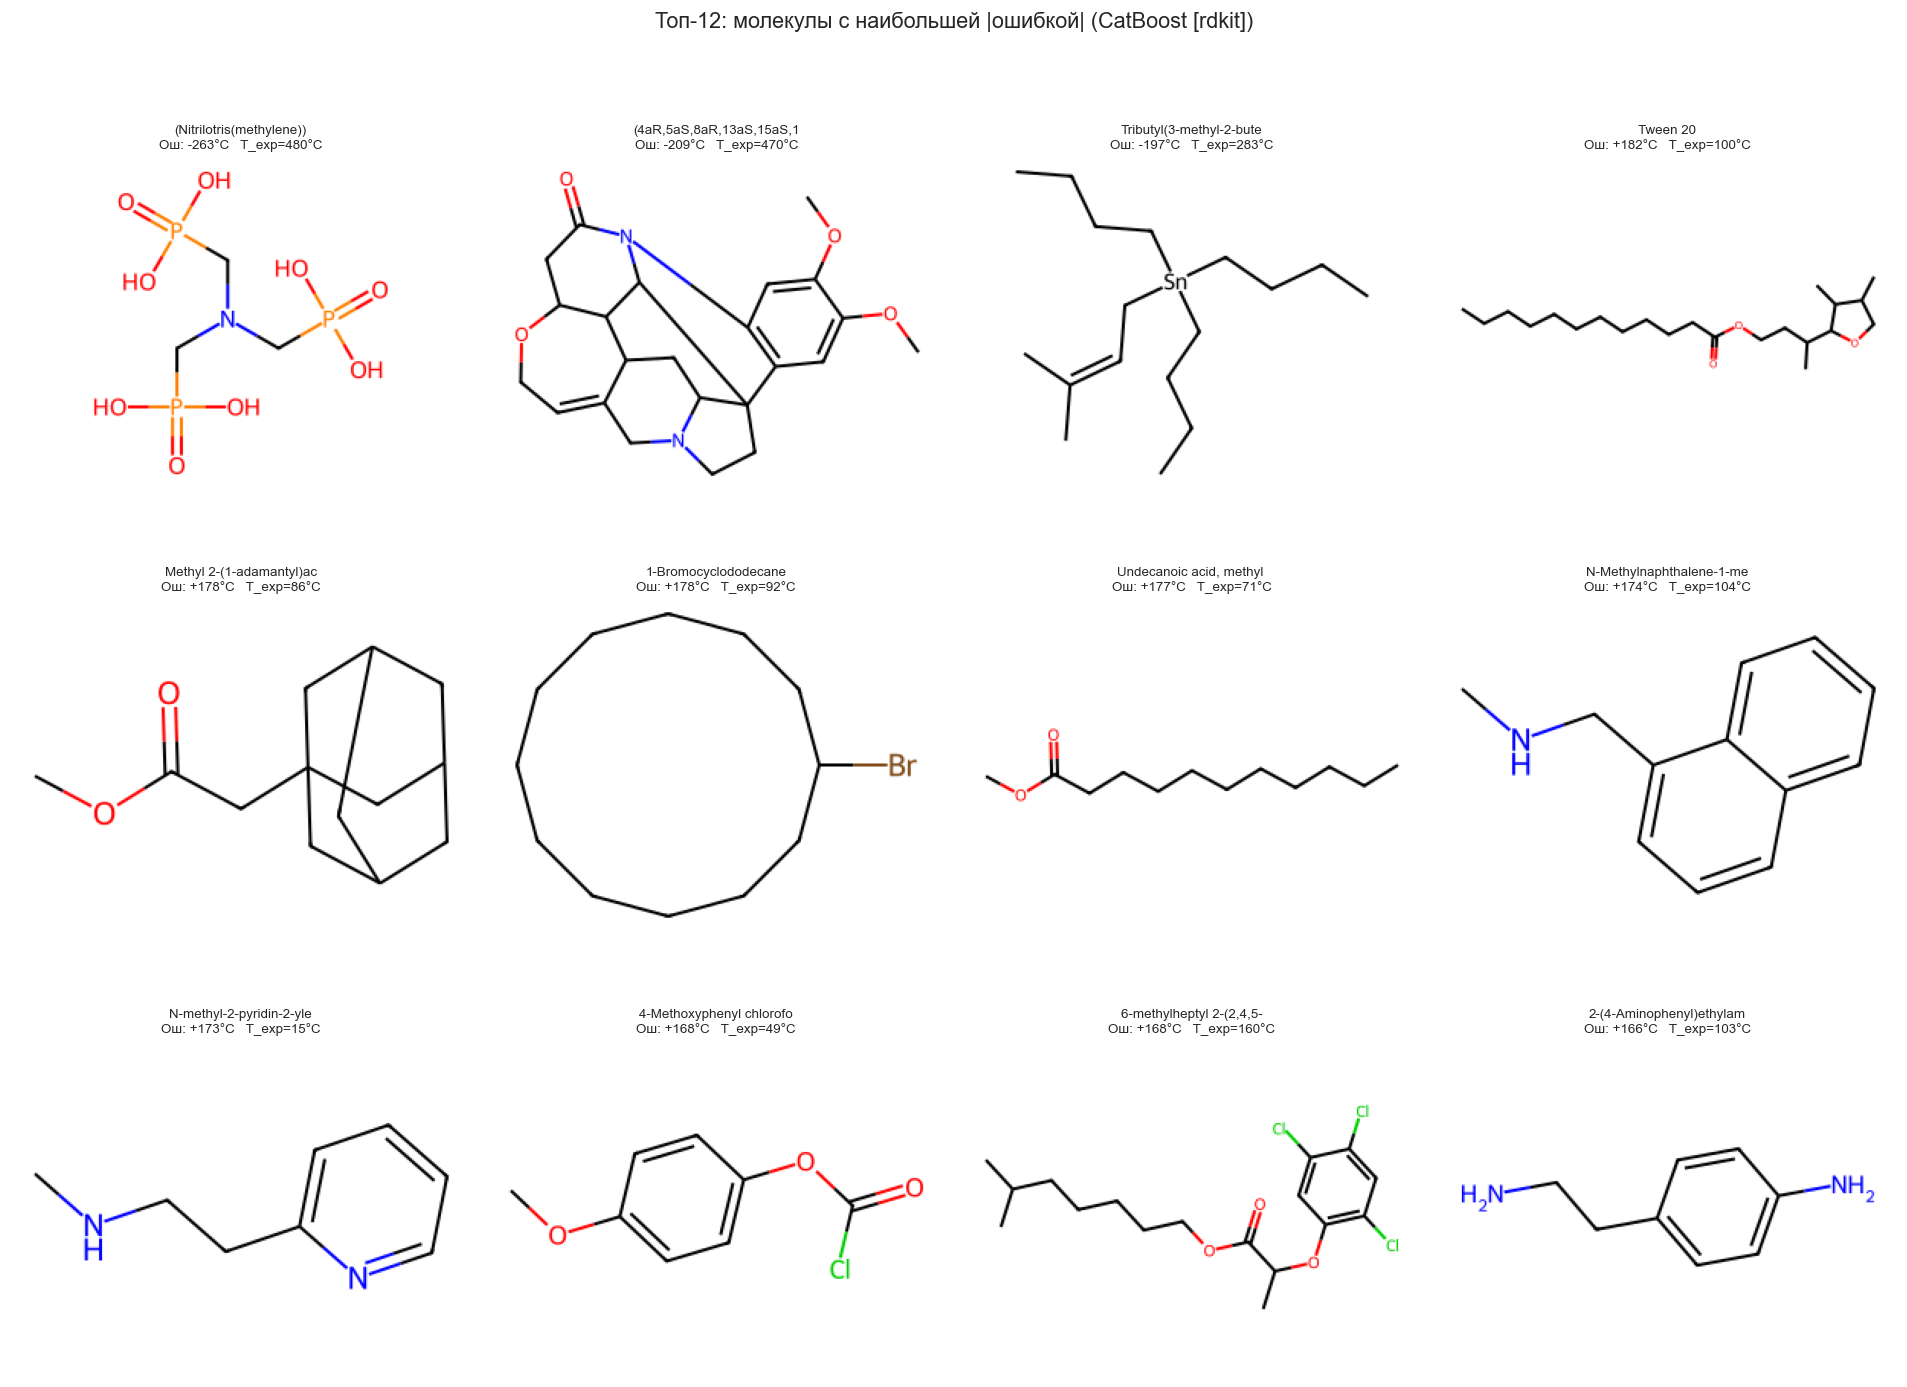

Сохранено: error_top12_worst.png


In [241]:
# ── 17.4: Топ-12 худших предсказаний (структуры) ─────────────────────────
top12_err = (
    df_test_err
    .nlargest(12, 'abs_error')
    [['compound', 'SMILES', 'T_exp', 'T_pred', 'error', 'abs_error',
      'n_sources', 'source', 'merge_status']]
    .reset_index(drop=True)
)
top12_err.index += 1

print('=== \u0422\u043e\u043f-12 \u043c\u043e\u043b\u0435\u043a\u0443\u043b \u0441 \u043d\u0430\u0438\u0431\u043e\u043b\u044c\u0448\u0435\u0439 |\u043e\u0448\u0438\u0431\u043a\u043e\u0439| ===')
display(
    top12_err[['compound', 'T_exp', 'T_pred', 'error', 'abs_error', 'n_sources', 'source']]
    .rename(columns={'T_exp': 'T_\u044d\u043a\u0441\u043f', 'T_pred': 'T_\u043f\u0440\u0435\u0434',
                     'error': '\u041e\u0448\u0438\u0431\u043a\u0430', 'abs_error': '|\u041e\u0448\u0438\u0431\u043a\u0430|',
                     'n_sources': 'n_\u0438\u0441\u0442'})
    .style
    .format({'T_\u044d\u043a\u0441\u043f': '{:.1f}', 'T_\u043f\u0440\u0435\u0434': '{:.1f}',
             '\u041e\u0448\u0438\u0431\u043a\u0430': '{:+.1f}', '|\u041e\u0448\u0438\u0431\u043a\u0430|': '{:.1f}'})
    .background_gradient(subset=['|\u041e\u0448\u0438\u0431\u043a\u0430|'], cmap='Reds')
)

# Сетка структур через matplotlib (Draw.MolToImage -> PIL -> imshow)
fig_t12, axes_t12 = plt.subplots(3, 4, figsize=(16, 12))
for ax_t, (_, row_t) in zip(axes_t12.flatten(), top12_err.iterrows()):
    mol_t = Chem.MolFromSmiles(str(row_t['SMILES']))
    if mol_t is not None:
        pil_mol = Draw.MolToImage(mol_t, size=(300, 220))
        ax_t.imshow(pil_mol)
    name_s = str(row_t['compound'])[:24]
    ax_t.set_title(
        f"{name_s}\n"
        f"\u041e\u0448: {row_t['error']:+.0f}\u00b0C   "
        f"T_exp={row_t['T_exp']:.0f}\u00b0C",
        fontsize=8, pad=4
    )
    ax_t.axis('off')

fig_t12.suptitle('\u0422\u043e\u043f-12: \u043c\u043e\u043b\u0435\u043a\u0443\u043b\u044b \u0441 \u043d\u0430\u0438\u0431\u043e\u043b\u044c\u0448\u0435\u0439 |\u043e\u0448\u0438\u0431\u043a\u043e\u0439| (CatBoost [rdkit])',
                 fontsize=13, y=1.01)
fig_t12.tight_layout()
fig_t12.savefig(FIGURES_DIR / 'error_top12_worst.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: error_top12_worst.png')


**17.4 Топ-12 худших предсказаний. Данные: тестовая выборка.**

12 молекул с наибольшей абсолютной ошибкой в тестовой выборке.  
Под каждой структурой: знаковая ошибка («Ош:») и экспериментальная Tкип.  
- **Положительная ошибка** (Ош: +X °C): модель предсказала Tкип *выше* реальной.  
- **Отрицательная** (Ош: −X °C): модель предсказала *ниже* реальной.  

Обратите внимание на структурные особенности: наличие необычных заместителей, цвиттерионных центров или редких сочетаний групп позволяет сделать выводы о причинах ошибки.

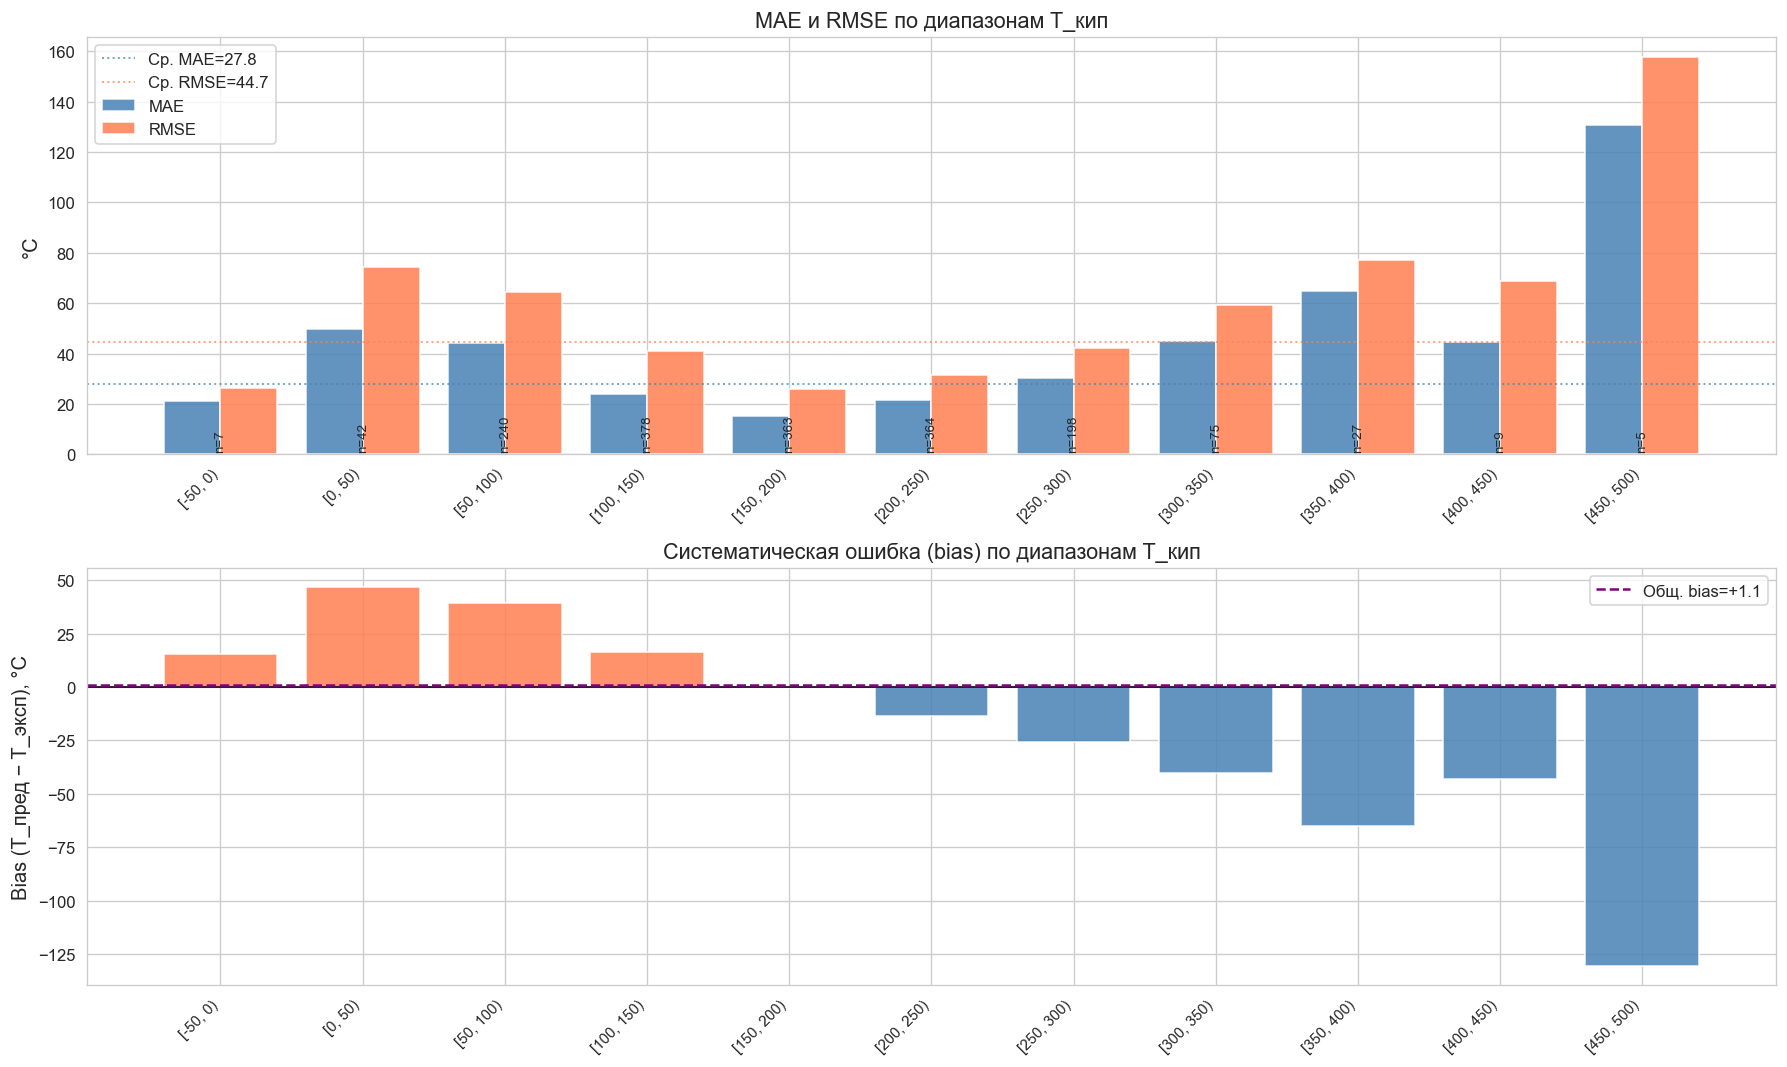

Сохранено: error_by_bp_range.png

     T_bin   n   mae  rmse   bias
  [-50, 0)   7  21.3  26.2   15.6
   [0, 50)  42  49.7  74.4   46.8
 [50, 100) 240  44.2  64.6   39.5
[100, 150) 378  24.1  41.2   16.6
[150, 200) 363  15.4  25.9   -0.6
[200, 250) 364  21.5  31.5  -13.5
[250, 300) 198  30.3  42.2  -25.8
[300, 350)  75  45.1  59.2  -40.0
[350, 400)  27  64.8  77.0  -64.8
[400, 450)   9  44.8  68.9  -43.1
[450, 500)   5 130.7 157.8 -130.7


In [242]:
# ── 17.5: Ошибка по диапазонам T_кип (бины 50 °C) ────────────────────────
import math

_t_lo = int(math.floor(df_test_err['T_exp'].min() / 50)) * 50
_t_hi = int(math.ceil( df_test_err['T_exp'].max() / 50)) * 50 + 50
_bin_edges = list(range(_t_lo, _t_hi, 50))

df_test_err['T_bin'] = pd.cut(df_test_err['T_exp'], bins=_bin_edges, right=False)

_bst = (
    df_test_err.groupby('T_bin', observed=True)
    .agg(n=('abs_error','count'),
         mae=('abs_error','mean'),
         rmse=('error', lambda x: float(np.sqrt((x**2).mean()))),
         bias=('error','mean'))
    .reset_index()
)
_bst = _bst[_bst['n'] >= 5].copy()
_xlbl = [str(b) for b in _bst['T_bin']]
_xp   = list(range(len(_bst)))
_w    = 0.4

fig_bins, axes_bins = plt.subplots(2, 1, figsize=(15, 9))

axes_bins[0].bar([x-_w/2 for x in _xp], _bst['mae'],  width=_w, color='steelblue', alpha=0.85, label='MAE')
axes_bins[0].bar([x+_w/2 for x in _xp], _bst['rmse'], width=_w, color='coral',     alpha=0.85, label='RMSE')
axes_bins[0].axhline(_mae_ea,  color='steelblue', ls=':', lw=1.2, alpha=0.7, label=f'\u0421\u0440. MAE={_mae_ea:.1f}')
axes_bins[0].axhline(_rmse_ea, color='coral',     ls=':', lw=1.2, alpha=0.7, label=f'\u0421\u0440. RMSE={_rmse_ea:.1f}')
for x, (_, rb) in zip(_xp, _bst.iterrows()):
    axes_bins[0].text(x, 1, f'n={rb["n"]}', ha='center', fontsize=8, rotation=90, va='bottom')
axes_bins[0].set_xticks(_xp); axes_bins[0].set_xticklabels(_xlbl, rotation=45, ha='right', fontsize=9)
axes_bins[0].set_ylabel('\u00b0C', fontsize=12)
axes_bins[0].set_title('MAE \u0438 RMSE \u043f\u043e \u0434\u0438\u0430\u043f\u0430\u0437\u043e\u043d\u0430\u043c T_\u043a\u0438\u043f', fontsize=13)
axes_bins[0].legend(fontsize=10)

_cb = ['coral' if b > 0 else 'steelblue' for b in _bst['bias']]
axes_bins[1].bar(_xp, _bst['bias'], color=_cb, alpha=0.85)
axes_bins[1].axhline(0, color='black', lw=1)
axes_bins[1].axhline(_bias_ea, color='purple', ls='--', lw=1.5, label=f'\u041e\u0431\u0449. bias={_bias_ea:+.1f}')
axes_bins[1].set_xticks(_xp); axes_bins[1].set_xticklabels(_xlbl, rotation=45, ha='right', fontsize=9)
axes_bins[1].set_ylabel('Bias (T_\u043f\u0440\u0435\u0434 \u2212 T_\u044d\u043a\u0441\u043f), \u00b0C', fontsize=12)
axes_bins[1].set_title('\u0421\u0438\u0441\u0442\u0435\u043c\u0430\u0442\u0438\u0447\u0435\u0441\u043a\u0430\u044f \u043e\u0448\u0438\u0431\u043a\u0430 (bias) \u043f\u043e \u0434\u0438\u0430\u043f\u0430\u0437\u043e\u043d\u0430\u043c T_\u043a\u0438\u043f', fontsize=13)
axes_bins[1].legend(fontsize=10)

fig_bins.tight_layout()
fig_bins.savefig(FIGURES_DIR / 'error_by_bp_range.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: error_by_bp_range.png\n')
print(_bst[['T_bin','n','mae','rmse','bias']].to_string(index=False, float_format=lambda v: f'{v:.1f}'))


**17.5 Ошибка по диапазонам Tкип. Данные: тестовая выборка.**

- **Верхний график**: MAE и RMSE в каждом температурном бине (ширина 50 °C). Пунктирные линии — среднее по всей тестовой выборке. Бины, где планки выше пунктира, — наиболее проблемные диапазоны.  
- **Нижний график**: систематическое смещение (bias). Красный (bias > 0): модель переоценивает Tкип в этом диапазоне. Синий (bias < 0): недооценивает.  

Если MAE повышен в граничных диапазонах (< −50 °C или > 350 °C), это указывает, что в тренировочной выборке таких молекул мало.

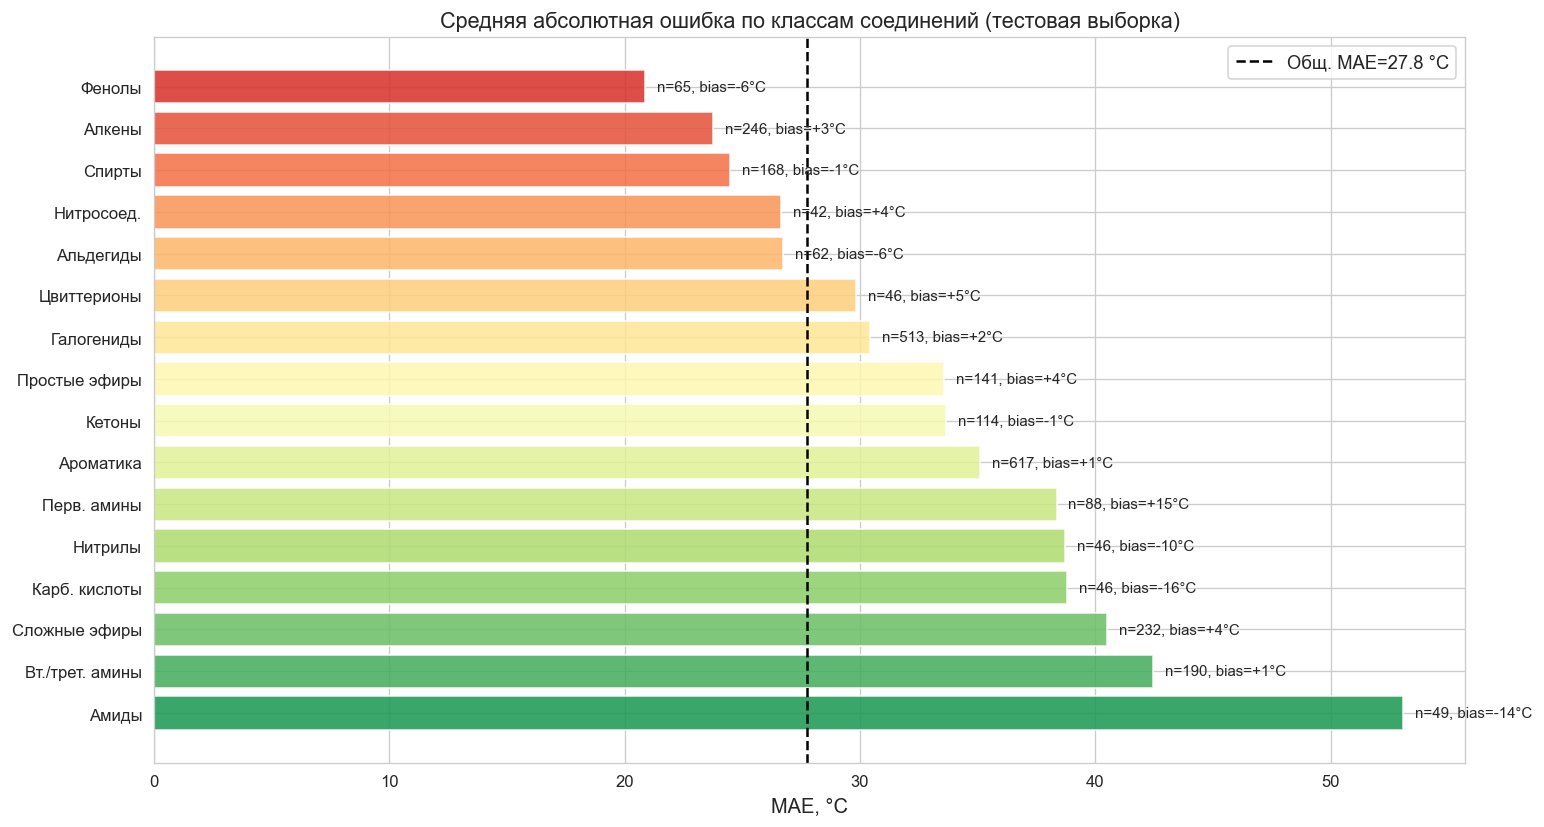

Сохранено: error_by_class.png

          Класс   n  MAE  RMSE  Bias
          Амиды  49 53.1  69.0 -13.8
Вт./трет. амины 190 42.5  61.4   0.5
  Сложные эфиры 232 40.5  58.1   4.2
  Карб. кислоты  46 38.8  56.1 -15.7
        Нитрилы  46 38.7  49.6 -10.1
    Перв. амины  88 38.4  57.5  14.6
      Ароматика 617 35.1  52.8   1.4
         Кетоны 114 33.7  47.6  -1.2
  Простые эфиры 141 33.6  50.7   4.2
     Галогениды 513 30.4  46.6   2.3
    Цвиттерионы  46 29.8  42.5   5.1
      Альдегиды  62 26.7  40.1  -5.5
     Нитросоед.  42 26.6  39.1   3.6
         Спирты 168 24.5  37.9  -1.0
         Алкены 246 23.8  43.2   2.7
         Фенолы  65 20.9  33.0  -6.1


In [243]:
# ── 17.6: Ошибка по химическим классам (SMARTS, тестовая выборка) ──────────
from rdkit.Chem import MolFromSmarts as _smarts

_CHEM_CLASSES = {
    'Ароматика':         _smarts('c1ccccc1'),
    'Спирты':              _smarts('[OX2H][CX4]'),
    'Фенолы':              _smarts('[OX2H]c'),
    'Простые эфиры':      _smarts('[CX4][OX2][CX4]'),
    'Карб. кислоты': _smarts('[CX3](=O)[OX2H1]'),
    'Сложные эфиры':      _smarts('[CX3](=O)[OX2][#6]'),
    'Альдегиды':           _smarts('[CX3H1](=O)'),
    'Кетоны':               _smarts('[#6][CX3](=O)[#6]'),
    'Перв. амины':     _smarts('[NX3H2][#6]'),
    'Вт./трет. амины':  _smarts('[NX3H0,NX3H1;!$([NX3](=O))]'),
    'Амиды':                _smarts('[NX3][CX3](=[OX1])'),
    'Нитросоед.':        _smarts('[N+](=O)[O-]'),
    'Галогениды':          _smarts('[F,Cl,Br,I]'),
    'Нитрилы':              _smarts('[CX2]#[NX1]'),
    'Алкены':               _smarts('[CX3]=[CX3]'),
}

def _is_zwitterion(mol):
    if mol is None: return False
    ch = [a.GetFormalCharge() for a in mol.GetAtoms()]
    return any(c > 0 for c in ch) and any(c < 0 for c in ch)

_df = df_test_err
for _cls, _patt in _CHEM_CLASSES.items():
    _df[_cls] = _df['mol'].apply(
        lambda m, p=_patt: bool(m is not None and m.HasSubstructMatch(p))
    )
_df['Цвиттерионы'] = _df['mol'].apply(_is_zwitterion)

_all_cls = list(_CHEM_CLASSES.keys()) + ['Цвиттерионы']
_cls_rows = []
for _cls in _all_cls:
    _sub = _df[_df[_cls]]
    if len(_sub) < 3: continue
    _cls_rows.append({'Класс': _cls, 'n': len(_sub),
                      'MAE': float(_sub['abs_error'].mean()),
                      'RMSE': float(np.sqrt((_sub['error']**2).mean())),
                      'Bias': float(_sub['error'].mean())})
_cls_df = pd.DataFrame(_cls_rows).sort_values('MAE', ascending=False)

fig_cls, ax_cls = plt.subplots(figsize=(13, 7))
_cmap_v = np.linspace(0.1, 0.9, len(_cls_df))
_clrs = plt.cm.RdYlGn_r(_cmap_v)
_bars_c = ax_cls.barh(_cls_df['Класс'], _cls_df['MAE'], color=_clrs, alpha=0.85)
ax_cls.axvline(_mae_ea, color='black', ls='--', lw=1.5, label=f'Общ. MAE={_mae_ea:.1f} °C')
for _bar, (_, _rc) in zip(_bars_c, _cls_df.iterrows()):
    ax_cls.text(_bar.get_width()+0.5, _bar.get_y()+_bar.get_height()/2,
                f"n={_rc['n']}, bias={_rc['Bias']:+.0f}°C", va='center', fontsize=9)
ax_cls.set_xlabel('MAE, °C', fontsize=12)
ax_cls.set_title('Средняя абсолютная ошибка по классам соединений (тестовая выборка)', fontsize=13)
ax_cls.legend(fontsize=11)
fig_cls.tight_layout()
fig_cls.savefig(FIGURES_DIR / 'error_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_by_class.png\n')
print(_cls_df.to_string(index=False, float_format=lambda v: f'{v:.1f}'))


**17.6 Ошибка по химическим классам. Данные: тестовая выборка.**

Горизонтальные столбцы — MAE модели для молекул, содержащих данную функциональную группу. Одна молекула может войти в несколько классов одновременно. Справа от каждого столбца — число молекул (n) и среднее смещение (bias).  
- Классы **правее** пунктирной линии предсказываются **хуже** среднего.  
- Классы **левее** — лучше среднего.  
- **Bias > 0**: модель систематически завышает Tкип для этого класса.  
- **Bias < 0**: модель занижает Tкип.  
- **Цвиттерионы**: зарядовые взаимодействия определяют Tкип, но не отражены в 2D-дескрипторах нейтральных SMILES.  
- **Карб. кислоты**: в жидкой фазе димеризуются через H-связи, что завышает экспериментальную Tкип относительно предсказания по 2D-структуре.

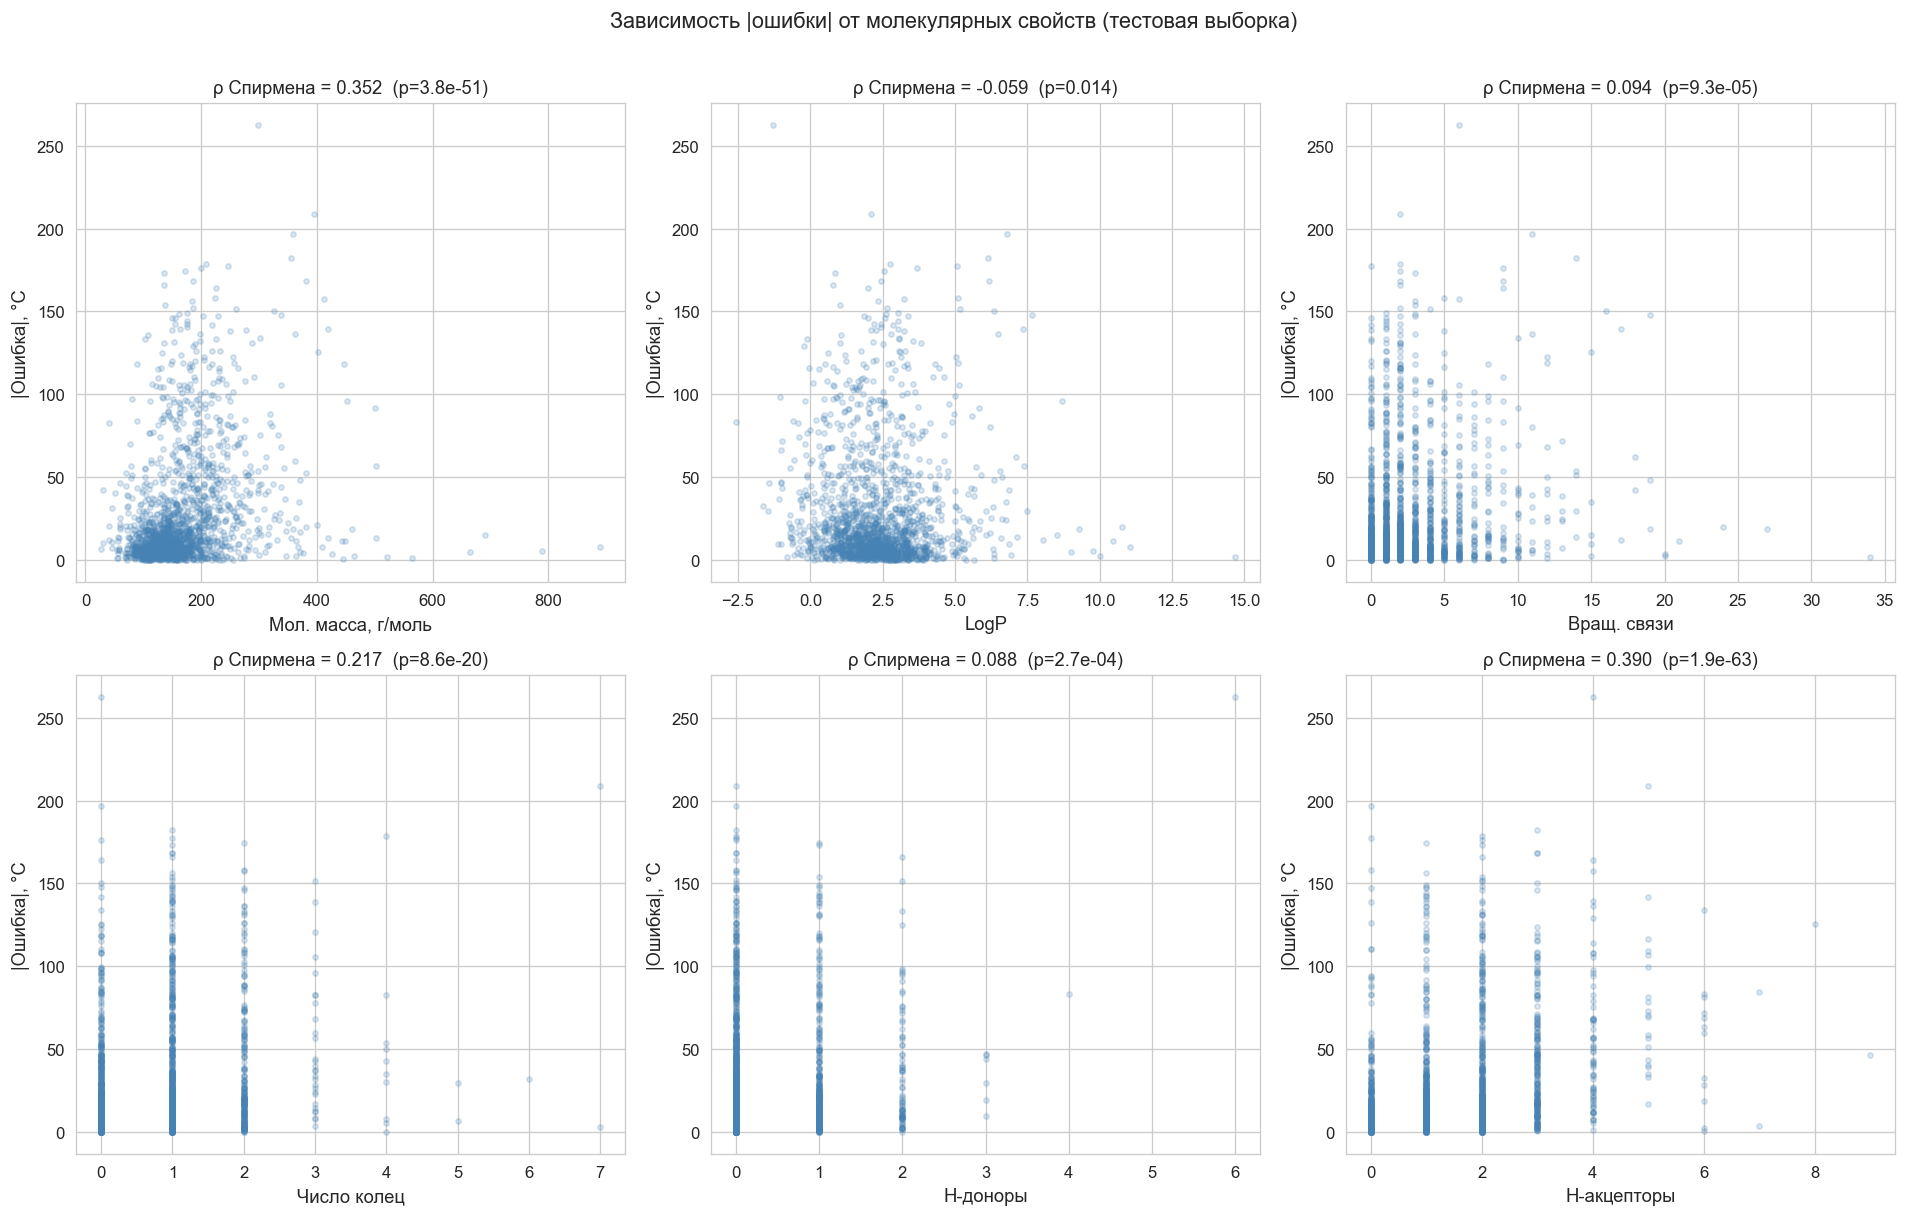

Сохранено: error_vs_mol_props.png


In [244]:
# ── 17.7: Ошибка vs молекулярные свойства ────────────────────────────────
from scipy.stats import spearmanr as _spearmanr

_mp = []
for _mol in df_test_err['mol']:
    if _mol is not None:
        _mp.append({'MolWt': Descriptors.MolWt(_mol),
                    'LogP':  Descriptors.MolLogP(_mol),
                    'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(_mol),
                    'Rings':    rdMolDescriptors.CalcNumRings(_mol),
                    'HBD':      rdMolDescriptors.CalcNumHBD(_mol),
                    'HBA':      rdMolDescriptors.CalcNumHBA(_mol)})
    else:
        _mp.append({k: float('nan') for k in ('MolWt','LogP','RotBonds','Rings','HBD','HBA')})

_mp_df = pd.DataFrame(_mp)
for _c in _mp_df.columns:
    df_test_err[_c] = _mp_df[_c].values

_pcols  = ['MolWt','LogP','RotBonds','Rings','HBD','HBA']
_plbls  = ['\u041c\u043e\u043b. \u043c\u0430\u0441\u0441\u0430, \u0433/\u043c\u043e\u043b\u044c','LogP','\u0412\u0440\u0430\u0449. \u0441\u0432\u044f\u0437\u0438','\u0427\u0438\u0441\u043b\u043e \u043a\u043e\u043b\u0435\u0446','H-\u0434\u043e\u043d\u043e\u0440\u044b','H-\u0430\u043a\u0446\u0435\u043f\u0442\u043e\u0440\u044b']

fig_p, axes_p = plt.subplots(2, 3, figsize=(16, 10))
for ax_p, _pc, _pl in zip(axes_p.flatten(), _pcols, _plbls):
    _msk = ~df_test_err[_pc].isna()
    _xv, _yv = df_test_err.loc[_msk, _pc], df_test_err.loc[_msk, 'abs_error']
    _rho, _pv = _spearmanr(_xv, _yv)
    ax_p.scatter(_xv, _yv, alpha=0.2, s=10, color='steelblue', rasterized=True)
    ax_p.set_xlabel(_pl, fontsize=11)
    ax_p.set_ylabel('|\u041e\u0448\u0438\u0431\u043a\u0430|, \u00b0C', fontsize=11)
    _ps = f'{_pv:.1e}' if _pv < 0.001 else f'{_pv:.3f}'
    ax_p.set_title(f'\u03c1 \u0421\u043f\u0438\u0440\u043c\u0435\u043d\u0430 = {_rho:.3f}  (p={_ps})', fontsize=11)

fig_p.suptitle('\u0417\u0430\u0432\u0438\u0441\u0438\u043c\u043e\u0441\u0442\u044c |\u043e\u0448\u0438\u0431\u043a\u0438| \u043e\u0442 \u043c\u043e\u043b\u0435\u043a\u0443\u043b\u044f\u0440\u043d\u044b\u0445 \u0441\u0432\u043e\u0439\u0441\u0442\u0432 (\u0442\u0435\u0441\u0442\u043e\u0432\u0430\u044f \u0432\u044b\u0431\u043e\u0440\u043a\u0430)',
               fontsize=13, y=1.01)
fig_p.tight_layout()
fig_p.savefig(FIGURES_DIR / 'error_vs_mol_props.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: error_vs_mol_props.png')


**17.7 Ошибка vs молекулярные свойства. Данные: тестовая выборка.**

Каждый сабплот — одно молекулярное свойство (X) vs абсолютная ошибка (Y). Аннотация показывает коэффициент ранговой корреляции Ρ Спирмена.  

Как читать:  
- **ρ > 0, p < 0.05** — чем больше свойство, тем *хуже* предсказание.  
- **ρ < 0, p < 0.05** — чем больше свойство, тем *лучше* предсказание.  
- **p > 0.05** — значимой монотонной связи не обнаружено.

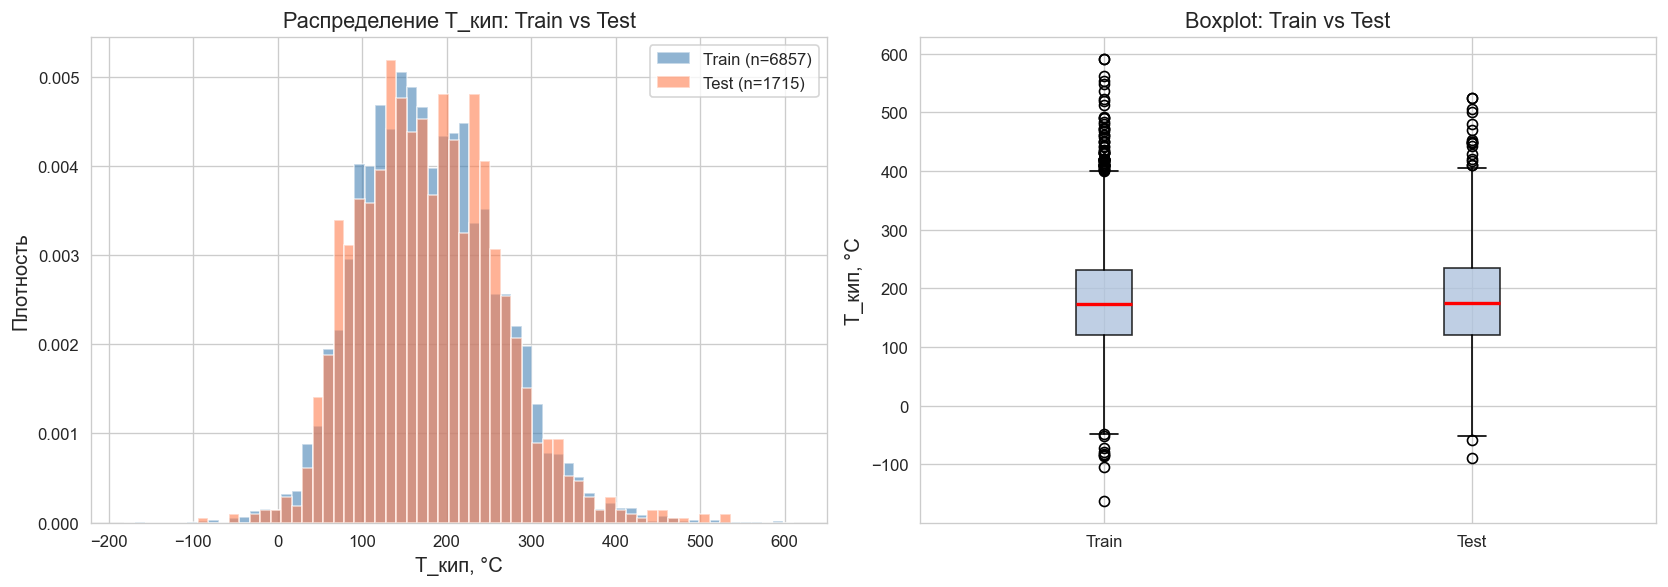

Сохранено: train_test_distribution.png



,Train,Test
count,6857.0,1715.0
mean,179.3,179.8
std,81.6,81.8
min,-161.5,-88.5
25%,120.0,120.0
50%,173.0,174.5
75%,232.0,235.0
max,590.5,525.0


In [245]:
# ── 17.8: Распределение T_кип: train vs test ─────────────────────────────
_y_tr = y[train_idx]
_y_te = y[test_idx]
_bd   = np.linspace(y.min()-20, y.max()+20, 65)

fig_dist, axes_d = plt.subplots(1, 2, figsize=(14, 5))
axes_d[0].hist(_y_tr, bins=_bd, density=True, alpha=0.60, color='steelblue', label=f'Train (n={len(_y_tr)})')
axes_d[0].hist(_y_te, bins=_bd, density=True, alpha=0.60, color='coral',     label=f'Test (n={len(_y_te)})')
axes_d[0].set_xlabel('T_\u043a\u0438\u043f, \u00b0C', fontsize=12)
axes_d[0].set_ylabel('\u041f\u043b\u043e\u0442\u043d\u043e\u0441\u0442\u044c', fontsize=12)
axes_d[0].set_title('\u0420\u0430\u0441\u043f\u0440\u0435\u0434\u0435\u043b\u0435\u043d\u0438\u0435 T_\u043a\u0438\u043f: Train vs Test', fontsize=13)
axes_d[0].legend()

axes_d[1].boxplot([_y_tr, _y_te], labels=['Train','Test'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
                  medianprops=dict(color='red', linewidth=2))
axes_d[1].set_ylabel('T_\u043a\u0438\u043f, \u00b0C', fontsize=12)
axes_d[1].set_title('Boxplot: Train vs Test', fontsize=13)

fig_dist.tight_layout()
fig_dist.savefig(FIGURES_DIR / 'train_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: train_test_distribution.png\n')
display(pd.DataFrame({'Train': pd.Series(_y_tr).describe(), 'Test': pd.Series(_y_te).describe()}).round(1))


**17.8 Распределение Tкип: train vs test. Данные: **оба набора** (весь датасет, не только тестовая выборка).**

- **Гистограмма** (левый): сравнение форм распределений train и test. Если распределения визуально совпадают — разбиение репрезентативно.  
- **Boxplot** (правый): медианы, квартили и «усы» train и test должны быть близки.  

Систематическое расхождение (train и test имеют разные распределения) означало бы, что RMSE частично объясняется смещением выборки, а не химической сложностью задачи.

## 17.9 Выводы по анализу ошибок

### Общая характеристика ошибок

CatBoost [rdkit]: R²=0.701, RMSE=44.7 °C, MAE=27.8 °C на 1715 тестовых молекулах.
Диапазон Tкип ≈ 752 °C → относительная погрешность лучшей модели ≈ 6 %.
Такой уровень ошибки типичен для 2D-QSPR-моделей на разнородных химических данных.

### Причины повышенного RMSE

1. **Разнородность данных.** Датасет объединяет измерения из 3х бд:
   расхождения между источниками достигают 20–50 °C — это нижняя граница достижимой точности независимо от алгоритма.

2. **Ограниченность 2D-дескрипторов.** 31 RDKit-признак описывает топологию,
   но не учитывает конформационную гибкость, кристаллическую упаковку
   и трёхмерные взаимодействия.

3. **Регрессия к среднему.** При очень высоких (>300 °C) и очень низких (<0 °C)
   Tкип модель занижает/завышает предсказание — следствие недостаточного
   числа представителей в граничных диапазонах.

### Наиболее проблемные классы соединений

- **Цвиттерионы**: зарядовые взаимодействия определяют Tкип, но не отражены в 2D-дескрипторах.
- **Карбоновые кислоты**: димеризация через H-связи завышает экспериментальную Tкип относительно предсказания по 2D-структуре.
- **Нитросоединения**: сильные диполь-дипольные взаимодействия плохо кодируются суммарными дескрипторами.

### Влияние молекулярных свойств на ошибку

Положительная корреляция |ошибки| с MolWt и RotBonds подтверждает:
крупные гибкие молекулы предсказываются хуже —
их конформационное пространство требует 3D-дескрипторов или графовых нейронных сетей.

### Репрезентативность тестовой выборки

Распределения Tкип в train и test статистически идентичны (случайное разбиение, random\_state=42). Повышенный RMSE — следствие химической сложности задачи, а не смещения выборки.

### Итог

RMSE ≈ 45 °C ожидаем при данном наборе данных.
Снижение RMSE возможно за счёт: дополнения данных для граничных диапазонов;
3D-дескрипторов или графовых нейронных сетей (→ `gnn.ipynb`).